In [8]:
#evaluation of RagTag scaffolded genome proteome coverage
#author: Sheng-Kai Hsu
#created: 2024.01.23
#last edited: 2024.02.19
rm(list=ls())

In [9]:
library(rtracklayer)
library(Biostrings)
library(limma)
library(scales)
library(LSD)
library(parallel)
library(tidyverse)

# random shortread assemblies

In [219]:
gff_old = readGFF("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/miniProt/AN21TNTL0135.gff")
# gff_new = readGFF("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/miniProt/AN20T005.scaffolded.gff")

In [10]:
queryFa = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/Pv-672_v3.0_peptide.fa")

In [11]:
queryFa_length=width(queryFa)
names(queryFa_length)=names(queryFa)


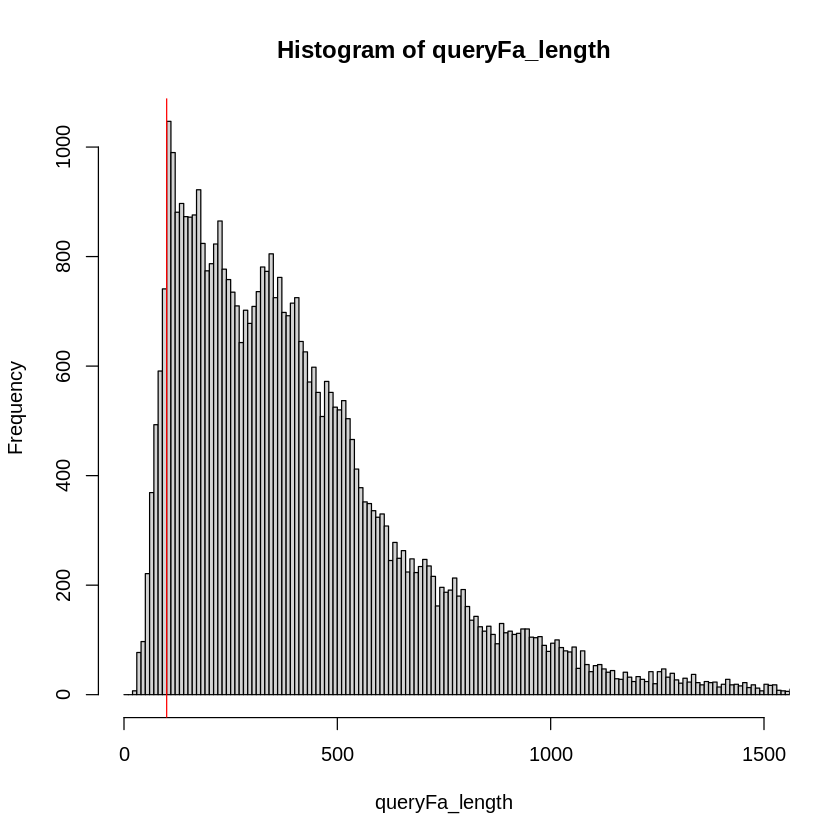

In [7]:
hist(queryFa_length,breaks = seq(0,5500,10),xlim = c(0,1500))
abline(v = 100,col = "red")

In [220]:
gff.mrna_old = gff_old[gff_old[,3]=="mRNA",]

queryStat_old = strsplit2(gff.mrna_old$Target," ")
queryStat_old = as.data.frame(queryStat_old)
colnames(queryStat_old) = c("query","start","end")
queryStat_old$range = as.numeric(queryStat_old[,3])-as.numeric(queryStat_old[,2])+1

# query coverage
qcov_old=c()
for (i in unique(queryStat_old[,1])){
  qcov_old=c(qcov_old,queryStat_old[queryStat_old[,1]==i,4]/queryFa_length[i])
}
queryStat_old$coverage = qcov_old


In [178]:
gff.mrna_new = gff_new[gff_new[,3]=="mRNA",]

queryStat_new = strsplit2(gff.mrna_new$Target," ")
queryStat_new = as.data.frame(queryStat_new)
colnames(queryStat_new) = c("query","start","end")
queryStat_new$range = as.numeric(queryStat_new[,3])-as.numeric(queryStat_new[,2])+1

# query coverage
qcov_new=c()
for (i in unique(queryStat_new[,1])){
  qcov_new=c(qcov_new,queryStat_new[queryStat_new[,1]==i,4]/queryFa_length[i])
}
queryStat_new$coverage = qcov_new


In [114]:
head(queryStat_old)
head(queryStat_new)

,query,start,end,range,coverage
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,Pavag01G000500.3,849,958,110,0.08695652
2,Pavag01G000500.1,1053,1162,110,0.07488087
3,Pavag01G000500.2,1048,1157,110,0.07513661
4,Pavag01G000600.1,112,163,52,0.21311475
5,Pavag01G000700.1,224,414,191,0.19061876
6,Pavag01G000700.2,224,414,191,0.19215292


,query,start,end,range,coverage
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,Pavag01G000500.3,849,958,110,0.08695652
2,Pavag01G000500.1,1053,1162,110,0.07488087
3,Pavag01G000500.2,1048,1157,110,0.07513661
4,Pavag01G000600.1,112,163,52,0.21311475
5,Pavag01G000700.1,224,1002,779,0.77744511
6,Pavag01G000700.2,224,994,771,0.77565392


In [115]:
queryStat_old_primary = queryStat_old[gff.mrna_old$Rank == 1,]
queryStat_new_primary = queryStat_new[gff.mrna_new$Rank == 1,]

rownames(queryStat_old_primary) = queryStat_old_primary[,1]
rownames(queryStat_new_primary) = queryStat_new_primary[,1]

In [117]:
dim(queryStat_old_primary)
dim(queryStat_new_primary)

[1] 25404     5

[1] 25247     5

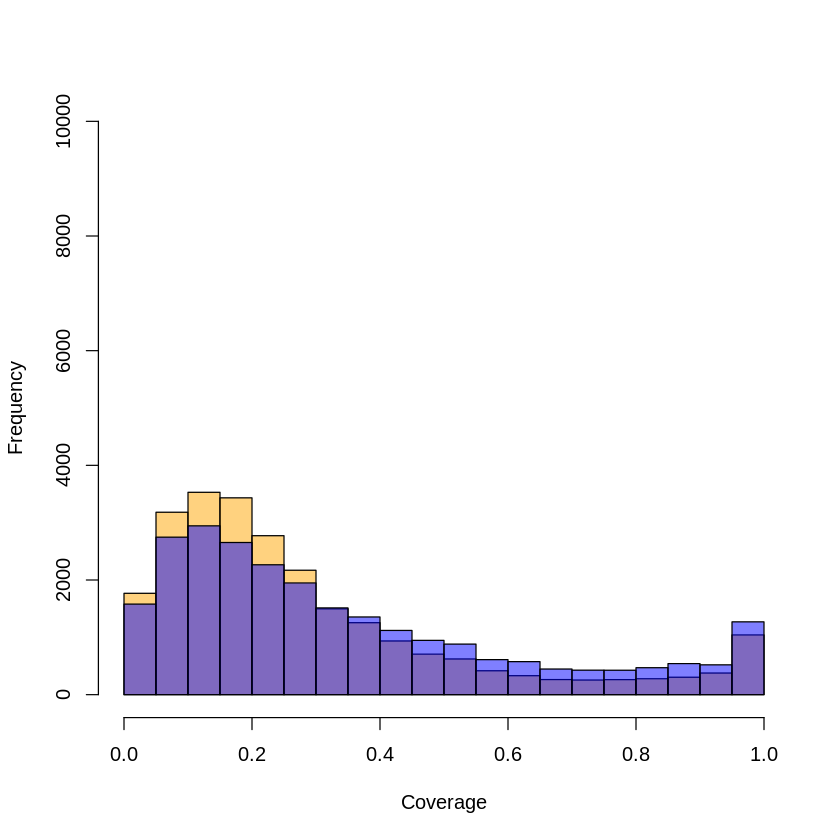

In [118]:
options(repr.plot.width=7, repr.plot.height=7)
hist(queryStat_old_primary$coverage,xlab = "Coverage",main = "", col = alpha("orange",.5),ylim = c(0,1e4))
hist(queryStat_new_primary$coverage,add = T, col = alpha("blue",.5))


In [119]:
common_anchor = intersect(rownames(queryStat_old_primary),rownames(queryStat_new_primary))

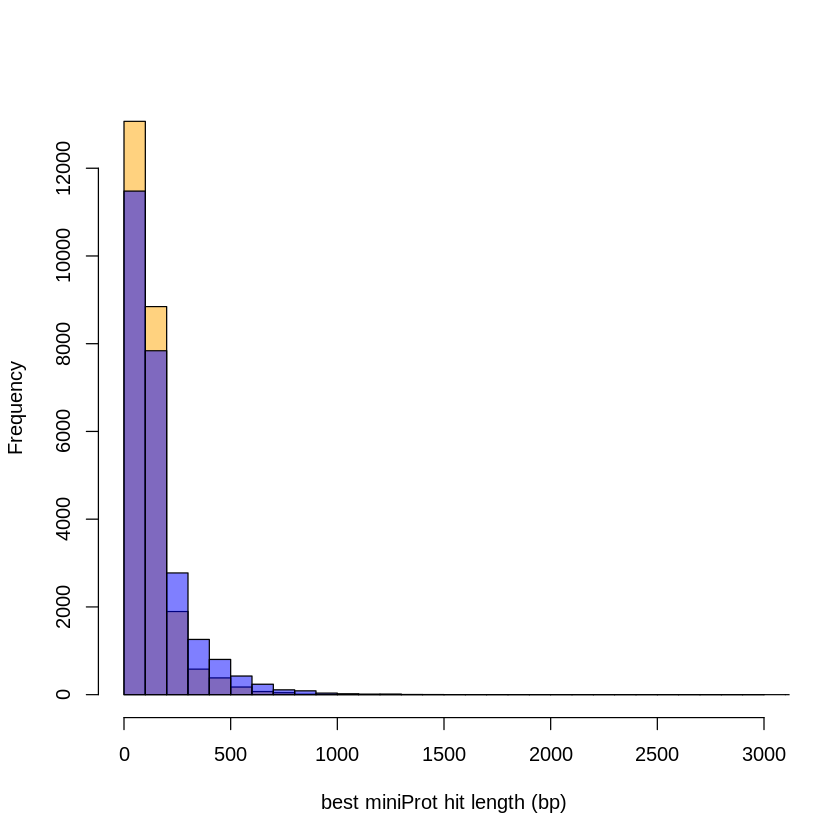

In [120]:
options(repr.plot.width=7, repr.plot.height=7)
hist(queryStat_old_primary[common_anchor,]$coverage*queryFa_length[common_anchor],
     xlab = "best miniProt hit length (bp)",main = "", col = alpha("orange",.5),breaks = seq(0,3000,100))
hist(queryStat_new_primary[common_anchor,]$coverage*queryFa_length[common_anchor],
     add = T, col = alpha("blue",.5),breaks = seq(0,6000,100))


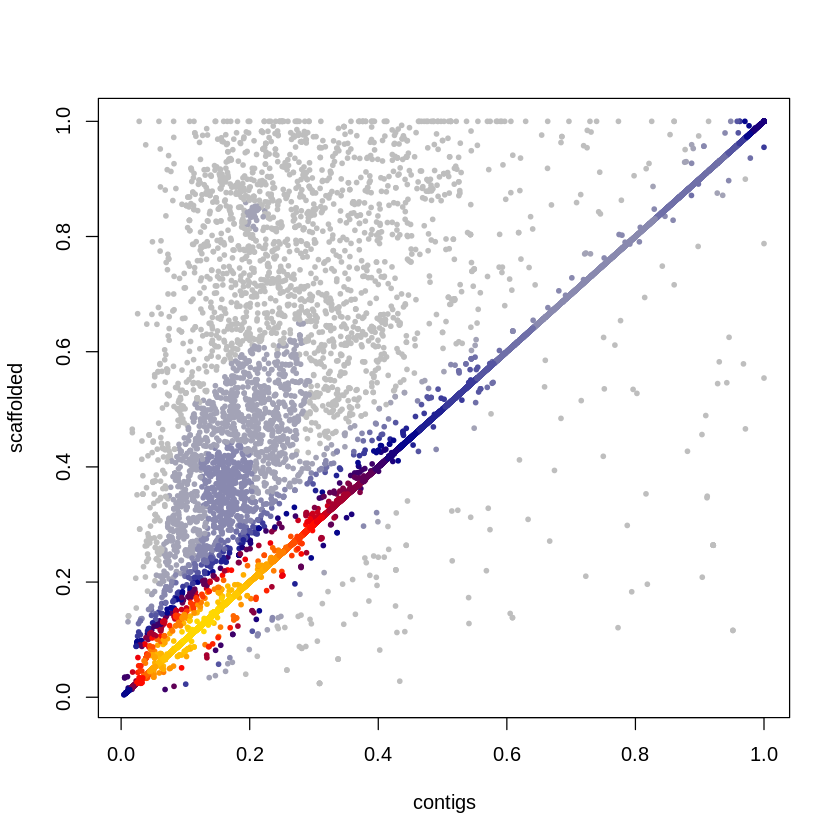

In [121]:
heatscatter(queryStat_old_primary[common_anchor,]$coverage,queryStat_new_primary[common_anchor,]$coverage,
     xlab = "contigs", ylab = "scaffolded", main = "")

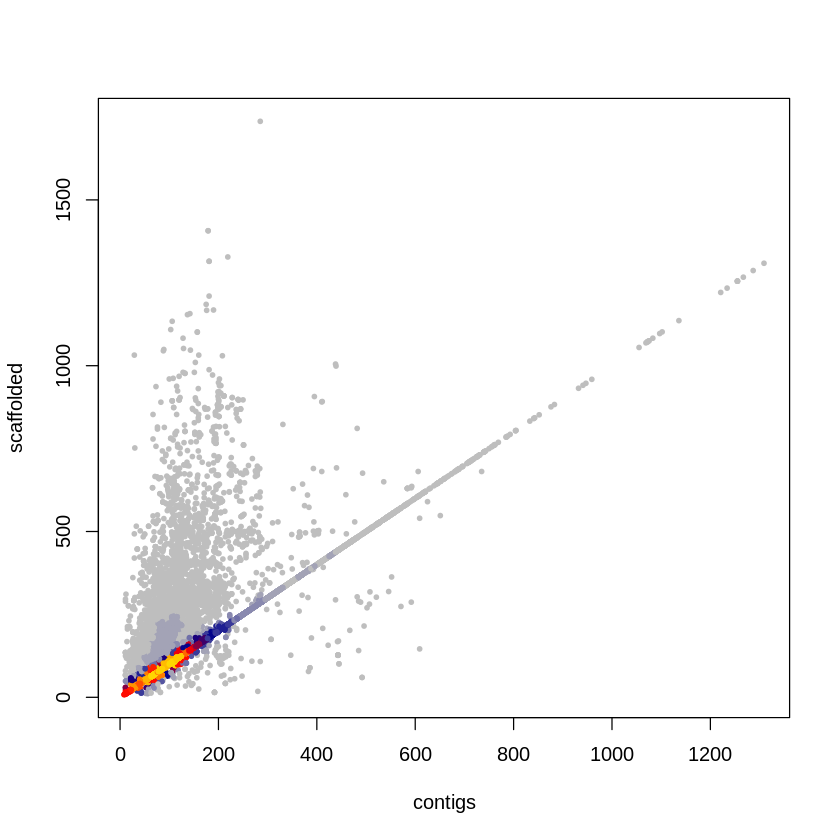

In [122]:
heatscatter(queryStat_old_primary[common_anchor,]$coverage*queryFa_length[common_anchor],
            queryStat_new_primary[common_anchor,]$coverage*queryFa_length[common_anchor],
     xlab = "contigs", ylab = "scaffolded", main = "")

[1] 318

[1] 20301

[1] 0

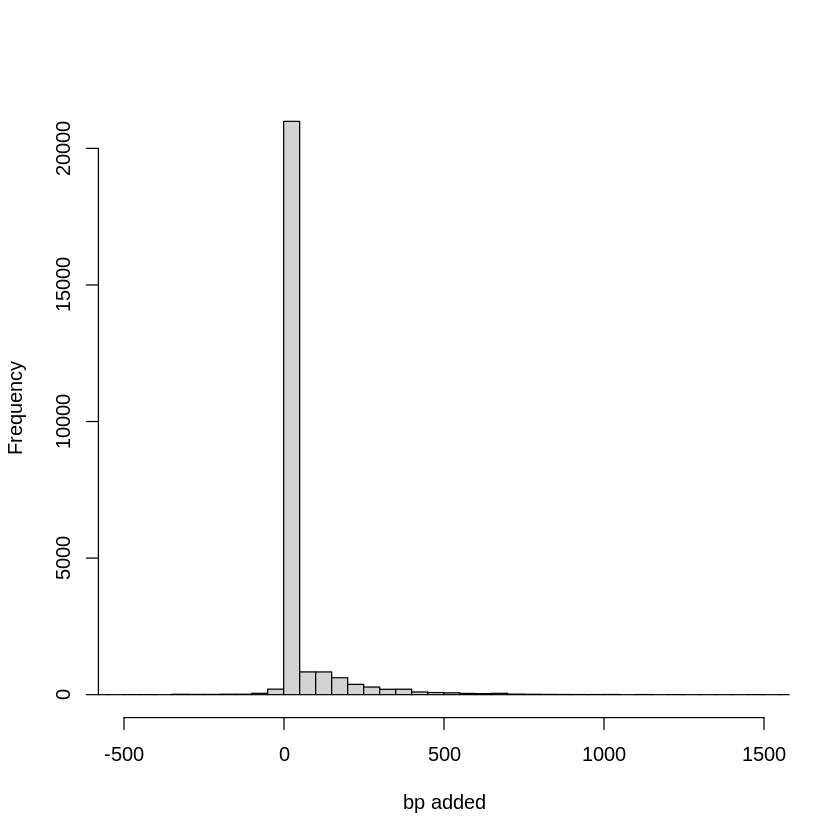

In [123]:
length_diff = queryStat_new_primary[common_anchor,]$coverage*queryFa_length[common_anchor]-queryStat_old_primary[common_anchor,]$coverage*queryFa_length[common_anchor]
hist(length_diff, breaks = seq(-1001,2999,50),main = "", xlab = "bp added",xlim = c(-500,1500))
sum(length_diff < 0)
sum(length_diff == 0)
median(length_diff)

In [221]:
# bp added by scaffolding including all hits
dupID = unique(queryStat_old[duplicated(queryStat_old[,1]),1])


In [222]:
# bp added by scaffolding including all hits
queryStat_old[,2] = as.numeric(queryStat_old[,2])
queryStat_old[,3] = as.numeric(queryStat_old[,3])
queryStat_new[,2] = as.numeric(queryStat_new[,2])
queryStat_new[,3] = as.numeric(queryStat_new[,3])


In [16]:
calculate_range <- function(start, end) {
  intervals <- data.frame(Start = start, End = end)
  intervals <- intervals[order(intervals$Start), ]
  
  # Merge overlapping intervals
  merged_intervals <- Reduce(function(acc, current) {
    if (is.null(acc)) {
      return(current)
    }
    last <- acc[nrow(acc), ]
    if (last$End >= current$Start) {
      acc[nrow(acc), 'End'] <- max(last$End, current$End)
    } else {
      acc <- rbind(acc, current)
    }
    acc
  }, split(intervals, 1:nrow(intervals)), init = NULL)
  
  # Calculate total range
  total_range <- sum(merged_intervals$End - merged_intervals$Start)
  return(total_range)
}


In [224]:
queryLengthCov_old <- queryStat_old %>% group_by(query) %>% 
summarise(TotalRange = calculate_range(start, end))
queryLengthCov_new <- queryStat_new %>% group_by(query) %>% 
summarise(TotalRange = calculate_range(start, end))

In [225]:
queryLengthCov_old = as.data.frame(queryLengthCov_old)
queryLengthCov_new = as.data.frame(queryLengthCov_new)
rownames(queryLengthCov_old)=queryLengthCov_old[,1]
rownames(queryLengthCov_new)=queryLengthCov_new[,1]

In [217]:
# plot(queryStat_old_primary[queryStat_old_primary[,1]%in%dupID,5]*queryFa_length[queryStat_old_primary[queryStat_old_primary[,1]%in%dupID,1]],queryLengthCov_old[intersect(queryStat_old_primary[,1],dupID),2])

[1] 1

[1] 23.58431

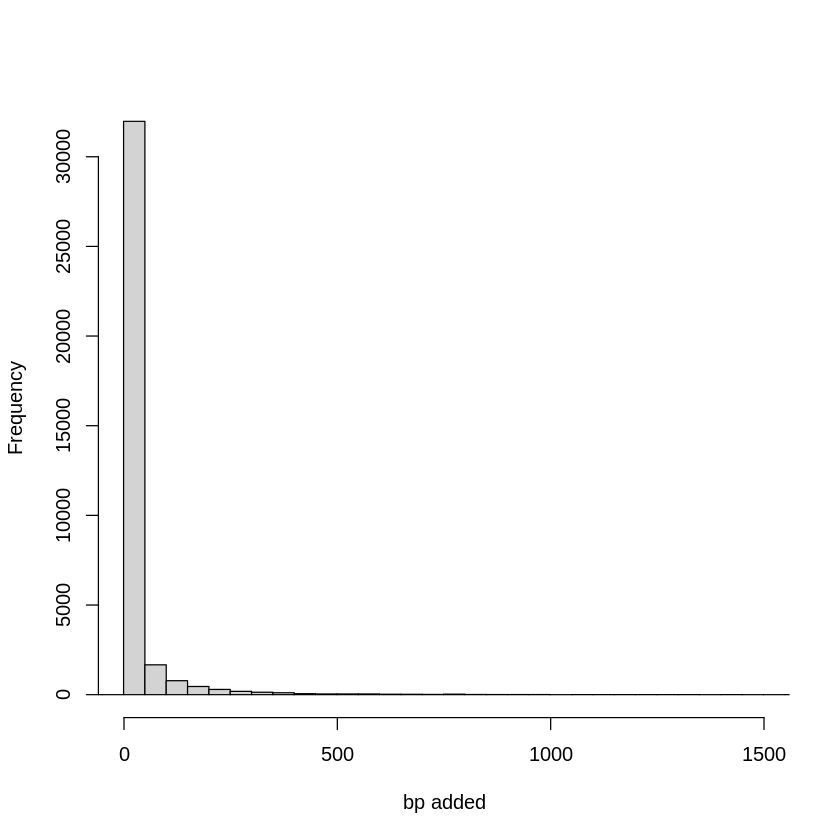

In [226]:
common_anchor2 = intersect(rownames(queryLengthCov_old),rownames(queryLengthCov_new))
hist(queryFa_length[common_anchor2]-queryLengthCov_old[common_anchor2,2],
    breaks = seq(-1001,9999,50),main = "", xlab = "bp added",xlim = c(0,1500))
median(queryFa_length[common_anchor2]-queryLengthCov_old[common_anchor2,2])
mean(queryFa_length[common_anchor2]-queryLengthCov_old[common_anchor2,2])
# sum(queryLengthCov_new[common_anchor2,2]-queryLengthCov_old[common_anchor2,2] < 0)
# sum(queryLengthCov_new[common_anchor2,2]-queryLengthCov_old[common_anchor2,2] == 0)

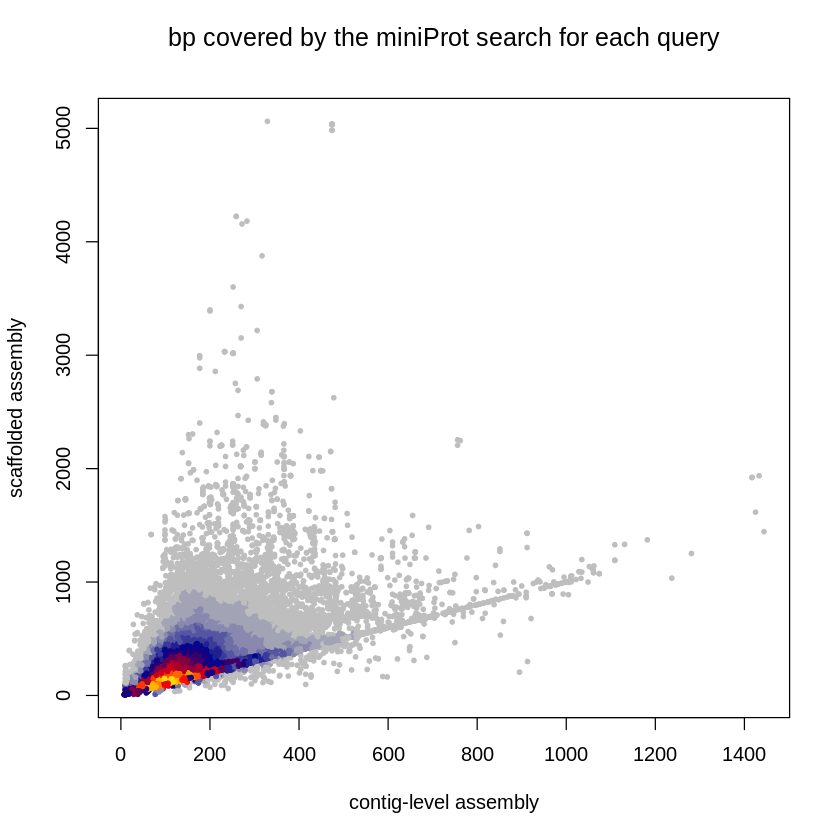

In [186]:
heatscatter(queryLengthCov_old[common_anchor2,2],queryLengthCov_new[common_anchor2,2],
     xlab = "contig-level assembly", ylab = "scaffolded assembly", main = "bp covered by the miniProt search for each query")

In [15]:
badID = queryStat_new_primary[common_anchor,][which(queryStat_new_primary[common_anchor,]$coverage-queryStat_old_primary[common_anchor,]$coverage< -0.5),1]
length(badID)
gff.mrna_old[strsplit2(gff.mrna_old$Target," ")[,1]%in%badID,]
gff.mrna_new[strsplit2(gff.mrna_new$Target," ")[,1]%in%badID&gff.mrna_new$Rank ==1,]


[1] 18

DataFrame with 18 rows and 18 columns
          seqid   source     type     start       end     score      strand
       <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1   k141_182507 miniprot     mRNA       155      1609       798           -
2   k141_471503 miniprot     mRNA         1       363        58           -
3   k141_328505 miniprot     mRNA       206      1012       462           -
4   k141_72599  miniprot     mRNA       389      1852       692           +
5   k141_723445 miniprot     mRNA        14      1714       740           -
...         ...      ...      ...       ...       ...       ...         ...
14  k141_276017 miniprot     mRNA      1566      2189       473           +
15  k141_449893 miniprot     mRNA       166       850       279           -
16  k141_416619 miniprot     mRNA        97      1356       548           -
17  k141_337988 miniprot     mRNA        45       994       372           -
18  k141_116157 miniprot     mRNA        10       

DataFrame with 18 rows and 18 columns
           seqid   source     type     start       end     score      strand
        <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1   Chr01_RagTag miniprot     mRNA   5890273   5891756       833           +
2   Chr03_RagTag miniprot     mRNA   4624130   4624234        55           +
3   Chr01_RagTag miniprot     mRNA   6844293   6845779       455           +
4   Chr01_RagTag miniprot     mRNA  12918366  12918761       567           -
5   Chr01_RagTag miniprot     mRNA  19596986  19597372       607           +
...          ...      ...      ...       ...       ...       ...         ...
14  Chr09_RagTag miniprot     mRNA   5052656   5054288       471           +
15  Chr10_RagTag miniprot     mRNA   3488924   3489022       164           -
16  Chr10_RagTag miniprot     mRNA   4528918   4529217       413           -
17  Chr05_RagTag miniprot     mRNA  15228987  15229262       329           -
18  Chr03_RagTag miniprot     mRNA   4

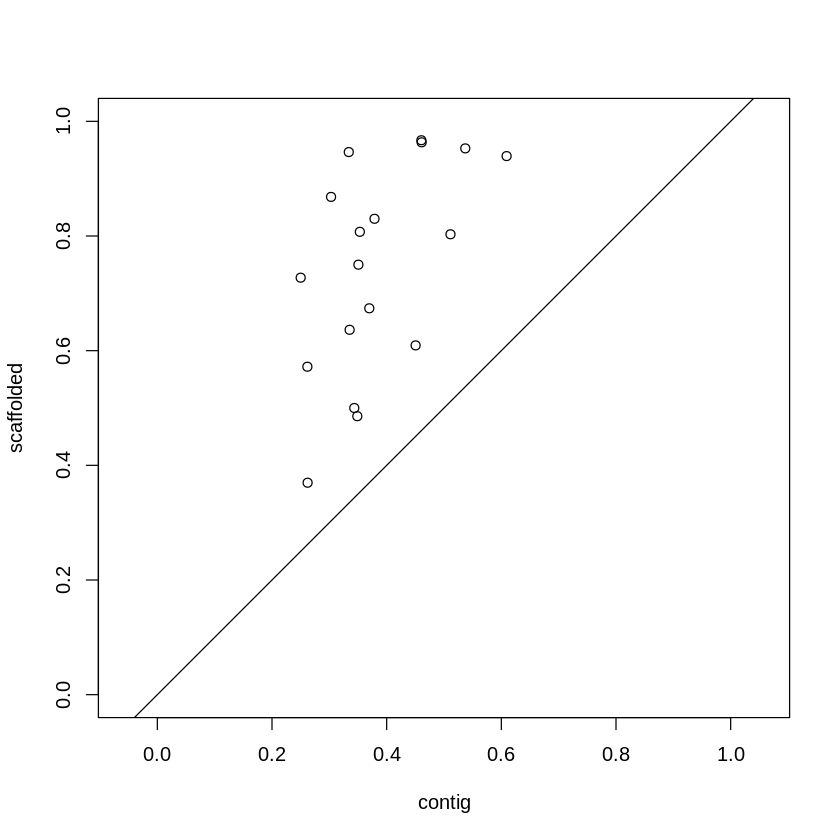

In [16]:
plot(as.numeric(gff.mrna_old[strsplit2(gff.mrna_old$Target," ")[,1]%in%badID,11]),
     as.numeric(gff.mrna_new[strsplit2(gff.mrna_new$Target," ")[,1]%in%badID&gff.mrna_new$Rank ==1,11]),
     asp =1,xlim = c(0,1),ylim = c(0,1),xlab = "contig",ylab = "scaffolded")
abline(a =0, b = 1)

In [17]:
head(intersect(queryStat_old[duplicated(queryStat_old[,1]),1],
               common_anchor[which(queryStat_new_primary[common_anchor,]$coverage>0.95&
                         queryStat_old_primary[common_anchor,]$coverage< 0.5)]))

[1] "Pavag01G022300.1" "Pavag01G022500.2" "Pavag01G026100.1" "Pavag01G030100.1"
[5] "Pavag01G058800.1" "Pavag01G068200.1"

In [18]:
gff_old[grep("Pavag01G022300.1",gff_old$Target),]
gff_new[grep("Pavag01G022300.1",gff_new$Target),]

DataFrame with 5 rows and 18 columns
        seqid   source     type     start       end     score      strand
     <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1 k141_183403 miniprot     mRNA       130       357       219           +
2 k141_183403 miniprot     CDS        130       198       110           +
3 k141_183403 miniprot     CDS        277       354       109           +
4 k141_50253  miniprot     mRNA       560       730       223           -
5 k141_50253  miniprot     CDS        560       730       223           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000245           1      0.9388      0.9388
2         0          NA           1      1.0000          NA
3         0          NA           1      0.8846          NA
4        NA    MP000246           2      0.8596      0.8596
5         0          NA           2      0.8596          NA
                  Target 

DataFrame with 5 rows and 18 columns
         seqid   source     type     start       end     score      strand
      <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1 Chr01_RagTag miniprot     mRNA    796349    799316       505           -
2 Chr01_RagTag miniprot     CDS     799146    799316       223           -
3 Chr01_RagTag miniprot     CDS     797121    797176        68           -
4 Chr01_RagTag miniprot     CDS     796508    796574       105           -
5 Chr01_RagTag miniprot     CDS     796352    796429       109           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000240           1      0.8871      0.8871
2         0          NA           1      0.8596          NA
3         0          NA           1      0.8421          NA
4         1          NA           1      1.0000          NA
5         0          NA           1      0.8846          NA
                  

In [19]:
# case study
agp = read.table("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/AN20T005/ragtag.scaffold.agp",skip = 2)

In [20]:
agp[agp$V6%in%c("k141_183403","k141_50253"),]

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
2199,Chr01_RagTag,795412,796705,2199,W,k141_183403,1,1294,-
2205,Chr01_RagTag,798587,799432,2205,W,k141_50253,1,846,+


In [21]:
agp[2199:2205,]

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
2199,Chr01_RagTag,795412,796705,2199,W,k141_183403,1,1294,-
2200,Chr01_RagTag,796706,796805,2200,U,100,scaffold,yes,align_genus
2201,Chr01_RagTag,796806,797453,2201,W,k141_59168,1,648,+
2202,Chr01_RagTag,797454,797553,2202,U,100,scaffold,yes,align_genus
2203,Chr01_RagTag,797554,798486,2203,W,k141_393521,1,933,-
2204,Chr01_RagTag,798487,798586,2204,U,100,scaffold,yes,align_genus
2205,Chr01_RagTag,798587,799432,2205,W,k141_50253,1,846,+


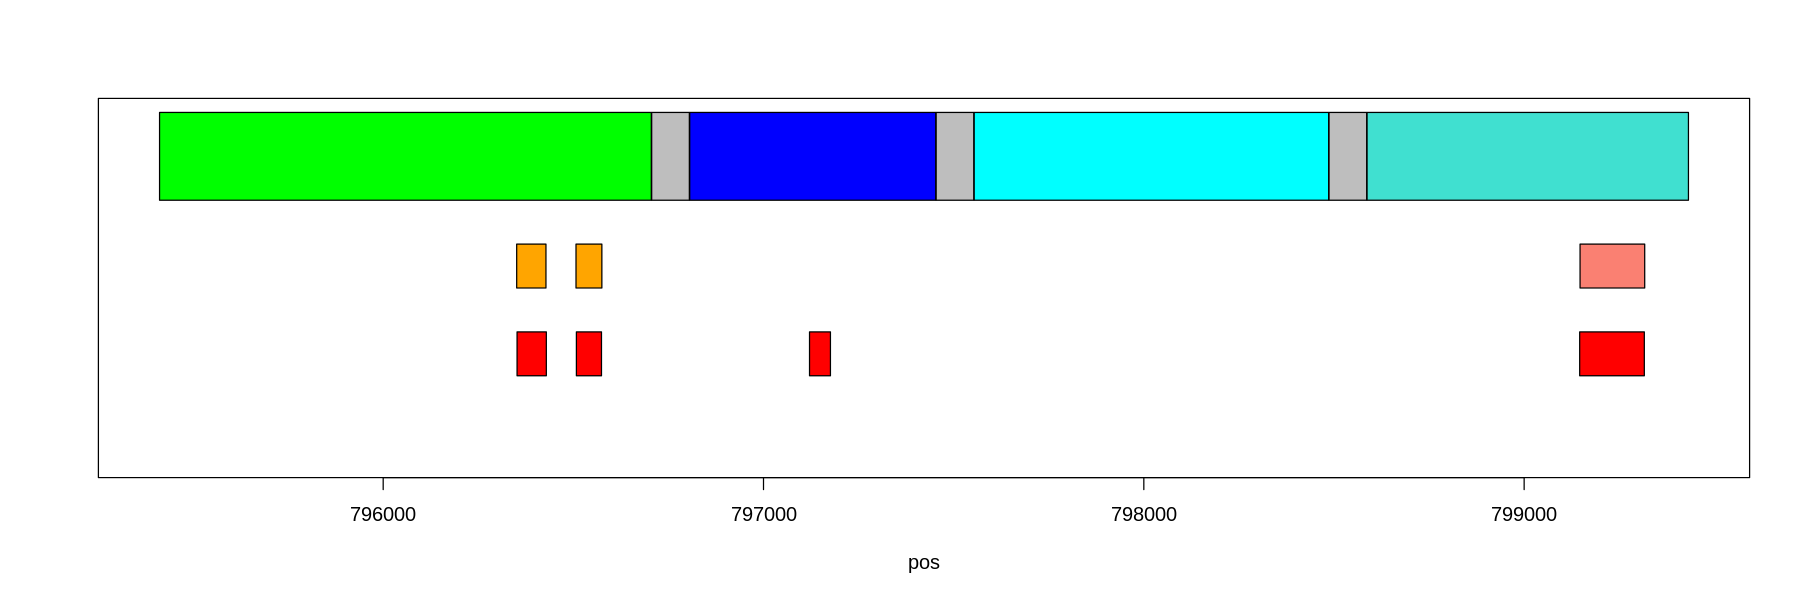

In [22]:
options(repr.plot.width=15, repr.plot.height=5)
plot(unlist(agp[2199:2205,2:3]),rep(1,14),ylim = c(0.6,1),type ='n',xlab = "pos",ylab = "",yaxt ='n')
rect(xleft = agp[2199:2205,2],xright = agp[2199:2205,3],ybottom = 0.9,ytop = 1,
     col = c("green","grey","blue","grey","cyan","grey","turquoise"))
rect(xleft = gff_new[grepl("Pavag01G022300.1",gff_new$Target)&gff_new$type=="CDS",4],
     xright = gff_new[grepl("Pavag01G022300.1",gff_new$Target)&gff_new$type=="CDS",5],
     ybottom = 0.7,ytop = .75,
     col = "red")
rect(xleft = -gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",4][1:2]+796705,
     xright = -gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",5][1:2]+796705,
     ybottom = 0.8,ytop = .85,
     col = "orange")
rect(xleft = gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",4][3]+798587,
     xright = gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",5][3]+798587,
     ybottom = 0.8,ytop = .85,
     col = "salmon")


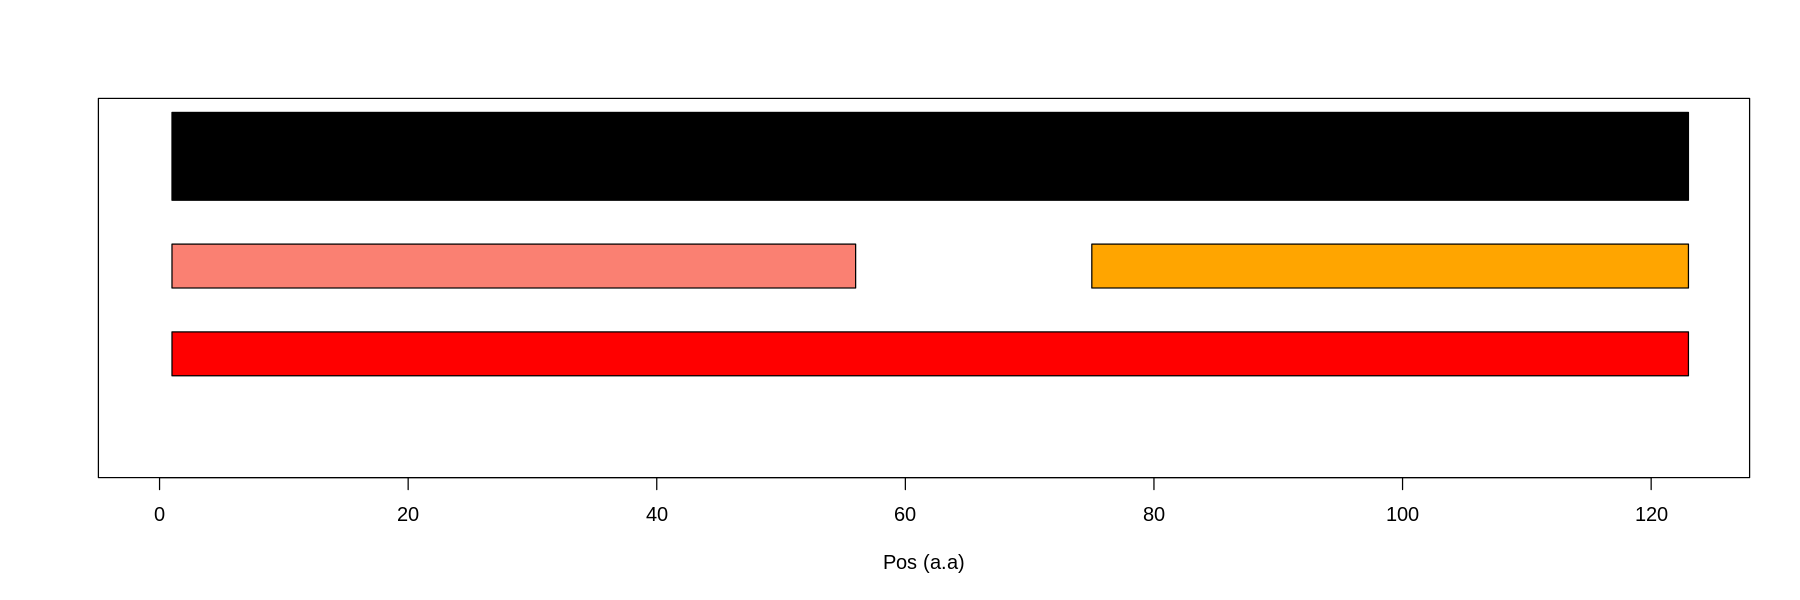

In [23]:
options(repr.plot.width=15, repr.plot.height=5)
plot(0,0,xlim= c(0,queryFa_length["Pavag01G022300.1"]),ylim= c(0.6,1),type = 'n',xlab = "Pos (a.a)",
     ylab = "", yaxt = 'n')
rect(xleft = 1,xright = queryFa_length["Pavag01G022300.1"],ybottom = 0.9,ytop = 1,col = c("black"))
rect(xleft = queryStat_new[queryStat_new[,1]=="Pavag01G022300.1",2],
     xright = queryStat_new[queryStat_new[,1]=="Pavag01G022300.1",3],
     ybottom = 0.7,ytop = .75,col = c("red"))

rect(xleft = queryStat_old[queryStat_old[,1]=="Pavag01G022300.1",2],
     xright = queryStat_old[queryStat_old[,1]=="Pavag01G022300.1",3],
     ybottom = 0.8,ytop = .85,col = c("orange","salmon"))


In [655]:
aln = read.delim("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/AN20T005/ragtag.scaffold.asm.paf",header = F)

In [656]:
ref_gff = readGFF("/workdir/sh2246/p_evolBNI/output/miniProtFilter_outGFF_v2/Sb-JGI-v3.gff")

In [657]:
head(aln)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,k141_395744,211,7,210,-,Chr04,68658214,41506723,41506926,149,203,0,tp:A:P,cm:i:14,s1:i:149,s2:i:147,dv:f:0.0235,rl:i:0
2,k141_395744,211,7,183,+,Chr09,59416394,4164048,4164224,147,176,0,tp:A:S,cm:i:12,s1:i:147,dv:f:0.0211,rl:i:0,
3,k141_395744,211,29,210,-,Chr02,77742459,5401457,5401638,147,181,0,tp:A:S,cm:i:15,s1:i:147,dv:f:0.0176,rl:i:0,
4,k141_395744,211,7,162,+,Chr08,62686529,23821582,23821737,147,155,0,tp:A:S,cm:i:12,s1:i:147,dv:f:0.0117,rl:i:0,
5,k141_395744,211,29,210,-,Chr08,62686529,12681648,12681829,147,181,0,tp:A:S,cm:i:15,s1:i:147,dv:f:0.0176,rl:i:0,
6,k141_395744,211,7,183,+,Chr05,71854669,17785560,17785736,147,176,0,tp:A:S,cm:i:12,s1:i:147,dv:f:0.0211,rl:i:0,


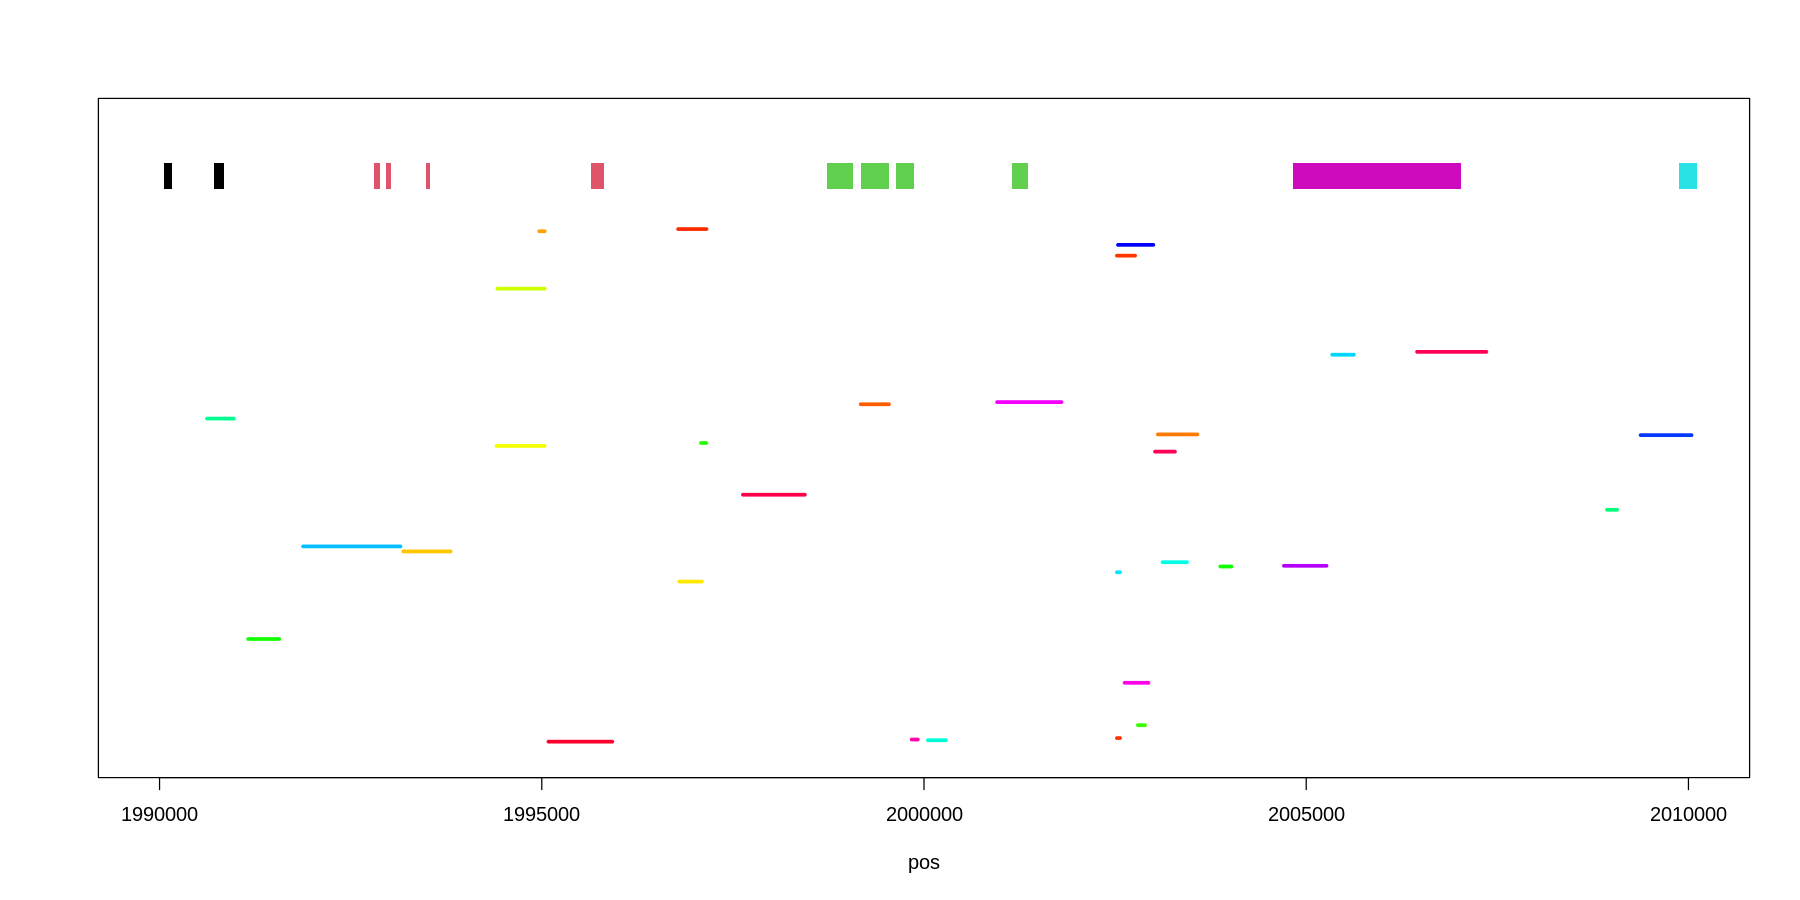

In [662]:
options(repr.plot.width=15, repr.plot.height=7.5)

set.seed(123)
bounds = c(1.99e6,2.01e6)
plot(0,0,xlim = bounds,ylim = c(0,1.2),type ='n',xlab = "pos",ylab = "",yaxt ='n')
aln_subset = aln[aln[,6]=="Chr01" & aln[,8]>bounds[1]*.9 & aln[,8] < bounds[2]*1.1,]
myContigCol = sample(rainbow(nrow(aln_subset)),nrow(aln_subset))
for ( i in 1:nrow(aln_subset)){
    segments(x0 = aln_subset[i,8],x1 = aln_subset[i,9],y0 = i/nrow(aln_subset),y1 = i/nrow(aln_subset),
             col = myContigCol[i],lwd = 3)
}
ref_gff_subset = ref_gff[ref_gff[,3]=="CDS" &ref_gff[,1]=="Chr01" & ref_gff[,4]> bounds[1] & ref_gff[,4] < bounds[2],]
for (i in 1:nrow(ref_gff_subset)){
    rect(xleft = ref_gff_subset[i,4],xright = ref_gff_subset[i,5],border = "NA",
             ybottom = 1.075, ytop = 1.125, col = as.factor(strsplit2(ref_gff_subset[,13]," ")[,1])[i])

}
# rect(xleft = TE[TE[,6]<10,4],xright = TE[TE[,6]<10,5],ybottom = 0.9,ytop = 1,col = "black")


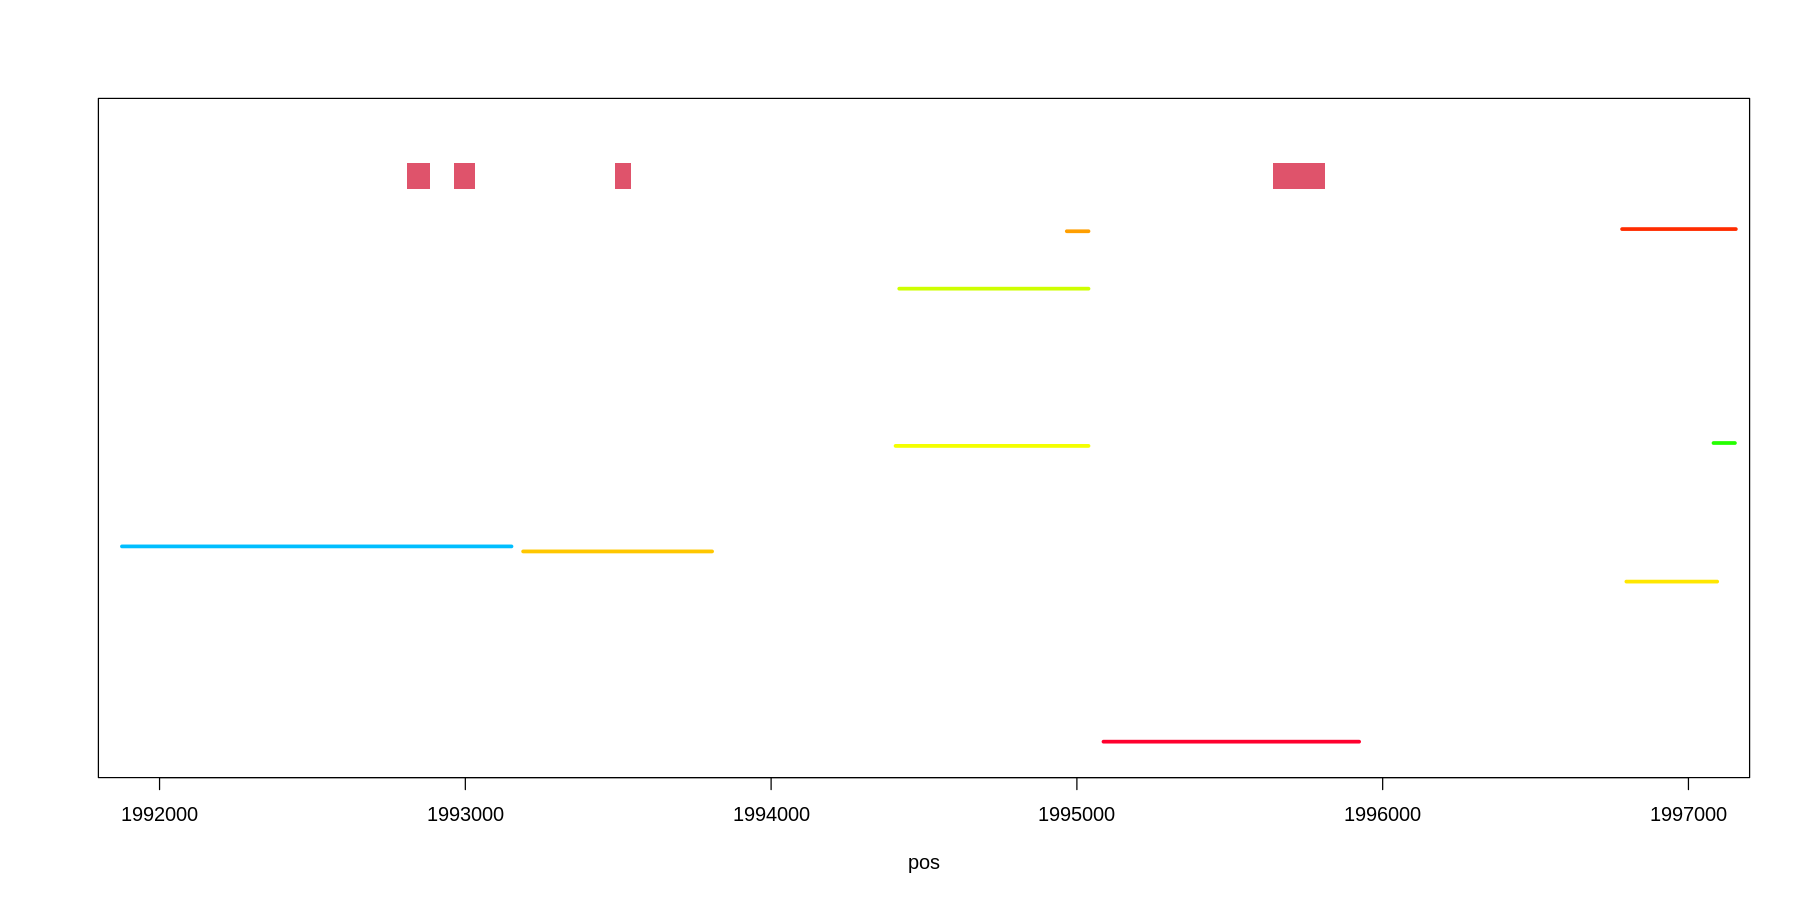

In [663]:
options(repr.plot.width=15, repr.plot.height=7.5)

# bounds = c(1.992e6,1.997e6)
plot(0,0,xlim = c(1.992e6,1.997e6),ylim = c(0,1.2),type ='n',xlab = "pos",ylab = "",yaxt ='n')
# aln_subset = aln[aln[,6]=="Chr01" & aln[,8]>bounds[1]*.9 & aln[,8] < bounds[2]*1.1,]
for ( i in 1:nrow(aln_subset)){
    segments(x0 = aln_subset[i,8],x1 = aln_subset[i,9],y0 = i/nrow(aln_subset),y1 = i/nrow(aln_subset),
             col = myContigCol[i],lwd = 3)
}
# ref_gff_subset = ref_gff[ref_gff[,3]=="CDS" &ref_gff[,1]=="Chr01" & ref_gff[,4]> bounds[1] & ref_gff[,4] < bounds[2],]
for (i in 1:nrow(ref_gff_subset)){
    rect(xleft = ref_gff_subset[i,4],xright = ref_gff_subset[i,5],border = "NA",
             ybottom = 1.075, ytop = 1.125, col = as.factor(strsplit2(ref_gff_subset[,13]," ")[,1])[i])

}
# rect(xleft = TE[TE[,6]<10,4],xright = TE[TE[,6]<10,5],ybottom = 0.9,ytop = 1,col = "black")


In [26]:
target_aln = aln[aln[,1]%in%c("k141_183403","k141_59168","k141_393521","k141_50253"),][1:4,]
target_aln

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
220260,k141_50253,846,14,843,+,Chr01,80884392,1995087,1995923,765,836,60,tp:A:P,cm:i:71,s1:i:763,s2:i:0,dv:f:0.0007,rl:i:0
2737254,k141_59168,648,17,635,+,Chr01,80884392,1993189,1993807,549,618,60,tp:A:P,cm:i:55,s1:i:549,s2:i:0,dv:f:0.0009,rl:i:0
2880604,k141_183403,1294,10,1284,-,Chr01,80884392,1991877,1993151,1219,1274,60,tp:A:P,cm:i:109,s1:i:1219,s2:i:0,dv:f:0.0010,rl:i:0
6397458,k141_393521,933,183,802,-,Chr01,80884392,1994419,1995038,411,619,60,tp:A:P,cm:i:36,s1:i:411,s2:i:306,dv:f:0.0182,rl:i:0


In [27]:
TE = read.table("/workdir/sh2246/p_phyloGWAS/data/Sbicolor_313_v3.1.repeatmasked_assembly_v3.0.gff3",header = F)

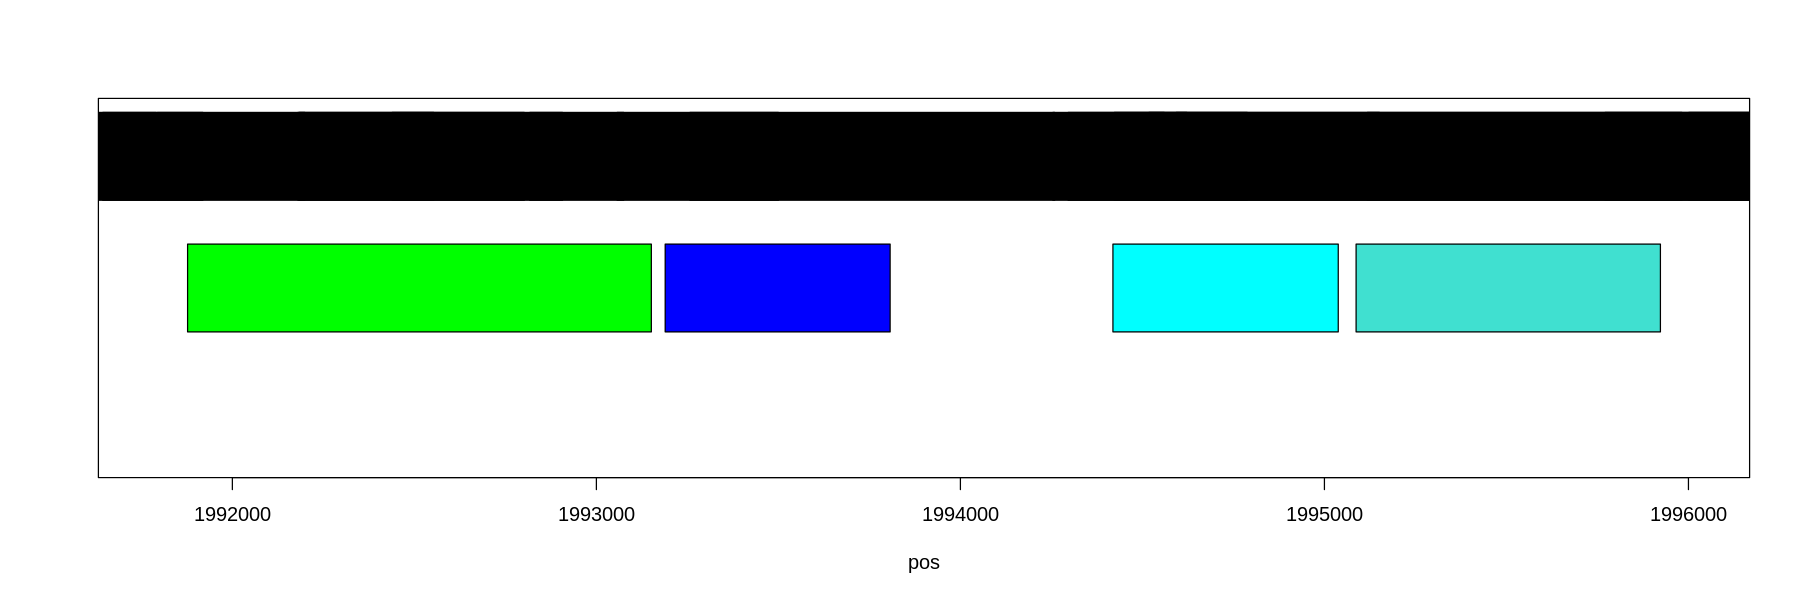

In [28]:
options(repr.plot.width=15, repr.plot.height=5)
plot(0,0,xlim = c(1991800,1996000),ylim = c(0.6,1),type ='n',xlab = "pos",ylab = "",yaxt ='n')
rect(xleft = target_aln[,8],xright = target_aln[,9],ybottom = 0.75,ytop = .85,
     col = c("green","blue","cyan","turquoise")[c(4,2,1,3)])
# rect(xleft = TE[TE[,6]<10,4],xright = TE[TE[,6]<10,5],ybottom = 0.9,ytop = 1,col = "black")


In [664]:
aln = read.delim("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/AN21TSTL0253/ragtag.scaffold.asm.paf",header = F)

ref_gff = readGFF("/workdir/sh2246/p_evolBNI/output/miniProtFilter_outGFF_v2/Cs-KelloggPI219580-DRAFT-PanAnd-1.0.gff")

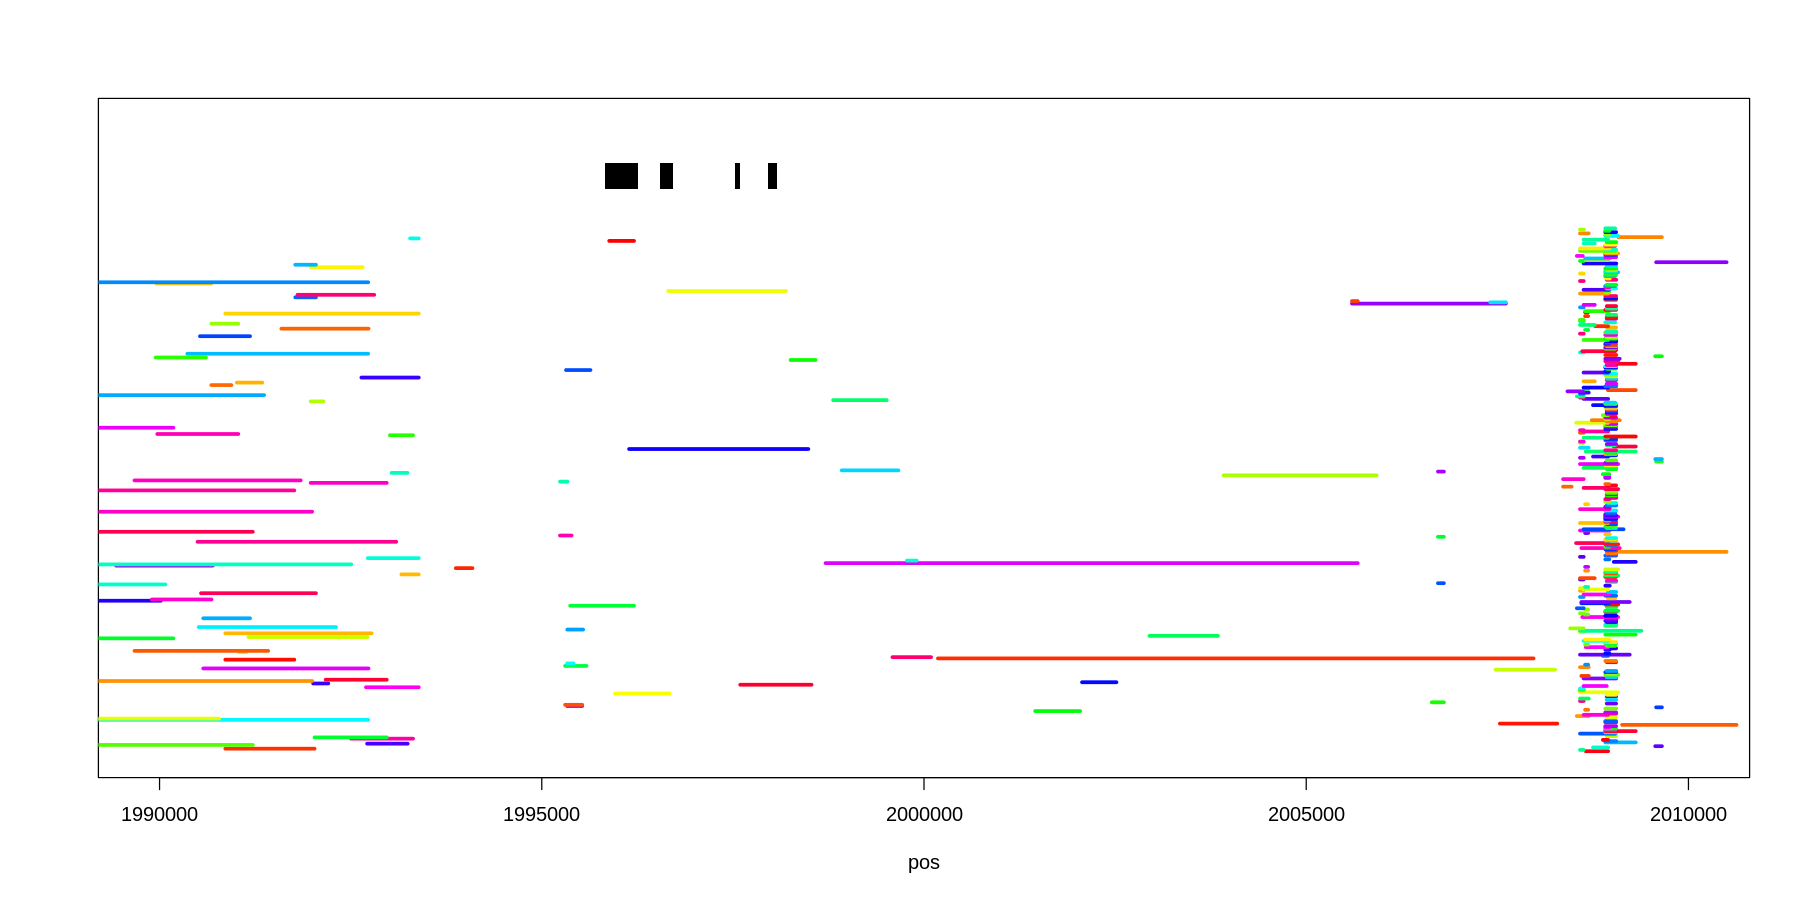

In [800]:
options(repr.plot.width=15, repr.plot.height=7.5)

set.seed(123)

bounds = c(1.99e6,2.01e6)
aln_subset = aln[aln[,6]=="scaf_1" & aln[,9]>bounds[1] & aln[,8] < bounds[2],]
myContigCol = sample(rainbow(nrow(aln_subset)),nrow(aln_subset))
plot(0,0,xlim = bounds,ylim = c(0,1.2),type ='n',xlab = "pos",ylab = "",yaxt ='n')

for ( i in 1:nrow(aln_subset)){
    segments(x0 = aln_subset[i,8],x1 = aln_subset[i,9],y0 = i/nrow(aln_subset),y1 = i/nrow(aln_subset),
             col = myContigCol[i],lwd = 3)
}
ref_gff_subset = ref_gff[ref_gff[,3]=="CDS" &ref_gff[,1]=="scaf_1" & ref_gff[,4]> bounds[1] & ref_gff[,4] < bounds[2],]
for (i in 1:nrow(ref_gff_subset)){
    rect(xleft = ref_gff_subset[i,4],xright = ref_gff_subset[i,5],border = "NA",
             ybottom = 1.075, ytop = 1.125, col = as.factor(strsplit2(ref_gff_subset[,13]," ")[,1])[i])

}
# rect(xleft = TE[TE[,6]<10,4],xright = TE[TE[,6]<10,5],ybottom = 0.9,ytop = 1,col = "black")


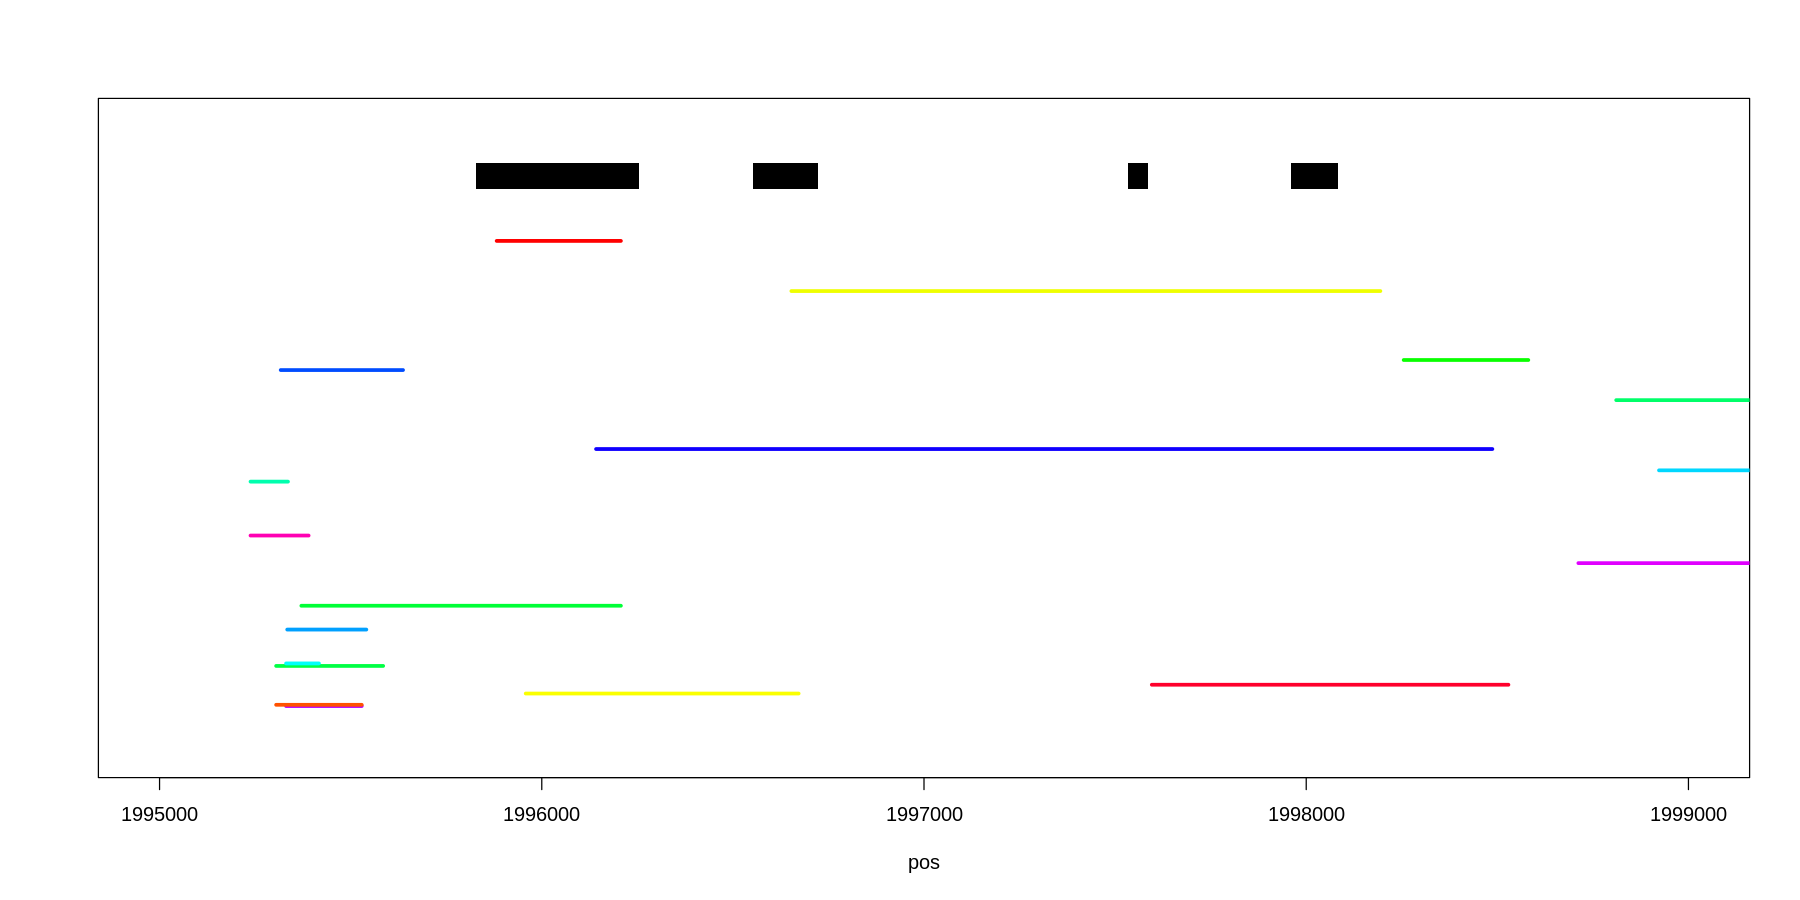

In [801]:
options(repr.plot.width=15, repr.plot.height=7.5)

# bounds = c(1.99e6,2.01e6)
plot(0,0,xlim = c(1.995e6,1.999e6),ylim = c(0,1.2),type ='n',xlab = "pos",ylab = "",yaxt ='n')
# aln_subset = aln[aln[,6]=="scaf_1" & aln[,8]>bounds[1]*.9 & aln[,8] < bounds[2]*1.1,]
for ( i in 1:nrow(aln_subset)){
    segments(x0 = aln_subset[i,8],x1 = aln_subset[i,9],y0 = i/nrow(aln_subset),y1 = i/nrow(aln_subset),
             col = myContigCol[i],lwd = 3)
}
# ref_gff_subset = ref_gff[ref_gff[,3]=="CDS" &ref_gff[,1]=="scaf_1" & ref_gff[,4]> bounds[1] & ref_gff[,4] < bounds[2],]
for (i in 1:nrow(ref_gff_subset)){
    rect(xleft = ref_gff_subset[i,4],xright = ref_gff_subset[i,5],border = "NA",
             ybottom = 1.075, ytop = 1.125, col = as.factor(strsplit2(ref_gff_subset[,13]," ")[,1])[i])

}
# rect(xleft = TE[TE[,6]<10,4],xright = TE[TE[,6]<10,5],ybottom = 0.9,ytop = 1,col = "black")


In [793]:
ref_gff_subset

DataFrame with 4 rows and 18 columns
     seqid   source     type     start       end     score      strand
  <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1   scaf_1 miniprot      CDS   1512125   1512382       242           -
2   scaf_1 miniprot      CDS   1511226   1511402       255           -
3   scaf_1 miniprot      CDS   1512125   1512325       222           -
4   scaf_1 miniprot      CDS   1511226   1511402       234           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1         0          NA           1      0.6047          NA
2         0          NA           1      0.7797          NA
3         0          NA           1      0.6866          NA
4         0          NA           1      0.7500          NA
                  Target          Parent  Frameshift       Donor    Acceptor
             <character> <CharacterList> <character> <character> <character>
1 Pavag05G010700.1 17 8

In [802]:
aln_subset[aln_subset[,9]>min(ref_gff_subset$start)&aln_subset[,8]<max(ref_gff_subset$end),]
which(aln_subset[,9]>min(ref_gff_subset$start)&aln_subset[,8]<max(ref_gff_subset$end))
aln_subset[aln_subset[,9]>min(ref_gff_subset$start)&aln_subset[,8]<max(ref_gff_subset$end),10]/aln_subset[aln_subset[,9]>min(ref_gff_subset$start)&aln_subset[,8]<max(ref_gff_subset$end),11]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1652797,k141_4133585,3577,2721,3466,+,scaf_1,77818675,1995958,1996672,305,790,60,tp:A:P,cm:i:20,s1:i:276,s2:i:0,dv:f:0.0095,rl:i:199
1989382,k141_3011770,2036,977,1964,-,scaf_1,77818675,1997596,1998529,194,1016,60,tp:A:P,cm:i:14,s1:i:170,s2:i:0,dv:f:0.0131,rl:i:0
5076934,k141_1725228,1402,61,1063,-,scaf_1,77818675,1995371,1996207,156,1008,60,tp:A:P,cm:i:12,s1:i:125,s2:i:0,dv:f:0.0337,rl:i:57
10631156,k141_4210144,3203,773,3188,-,scaf_1,77818675,1996142,1998487,967,2551,60,tp:A:P,cm:i:78,s1:i:896,s2:i:230,dv:f:0.0135,rl:i:0
18011474,k141_5589509,1542,55,1531,-,scaf_1,77818675,1996653,1998194,284,1570,60,tp:A:P,cm:i:22,s1:i:260,s2:i:0,dv:f:0.0107,rl:i:0
20834969,k141_2982242,1544,61,377,-,scaf_1,77818675,1995882,1996207,178,325,60,tp:A:P,cm:i:15,s1:i:175,s2:i:54,dv:f:0.0124,rl:i:57


[1]  47  54 117 242 368 408

[1] 0.3860759 0.1909449 0.1547619 0.3790670 0.1808917 0.5476923

In [795]:
focal_ctg = aln_subset[aln_subset[,9]>min(ref_gff_subset$start)&aln_subset[,8]<max(ref_gff_subset$end),1]

In [796]:
aln[aln[,1]%in%focal_ctg,]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
5019000,k141_1724755,723,297,705,-,scaf_1,77818675,1511360,1511769,388,409,60,tp:A:P,cm:i:39,s1:i:388,s2:i:0,dv:f:0.0026,rl:i:0
5019001,k141_1724755,723,5,265,+,scaf_9,50121718,35688989,35689251,187,262,12,tp:A:P,cm:i:14,s1:i:186,s2:i:175,dv:f:0.0258,rl:i:0
5019002,k141_1724755,723,5,265,-,scaf_9,50121718,7266063,7266324,175,261,0,tp:A:S,cm:i:13,s1:i:175,dv:f:0.0296,rl:i:0,
5019003,k141_1724755,723,5,265,+,scaf_7,51581111,44828849,44829111,175,262,0,tp:A:S,cm:i:13,s1:i:174,dv:f:0.0296,rl:i:0,
5019004,k141_1724755,723,5,265,-,scaf_6,53625606,14281043,14281305,171,262,0,tp:A:S,cm:i:11,s1:i:170,dv:f:0.0381,rl:i:0,
5019005,k141_1724755,723,5,265,+,scaf_15,34860913,28376408,28376670,158,262,0,tp:A:S,cm:i:12,s1:i:157,dv:f:0.0337,rl:i:0,
5019006,k141_1724755,723,5,265,-,scaf_11,47157659,1615777,1616039,158,263,0,tp:A:S,cm:i:12,s1:i:157,dv:f:0.0337,rl:i:0,
5019007,k141_1724755,723,5,234,-,scaf_10,47214623,31552215,31552445,154,231,0,tp:A:S,cm:i:11,s1:i:153,dv:f:0.0310,rl:i:0,
5019008,k141_1724755,723,9,234,+,scaf_1,77818675,29276273,29276500,149,227,0,tp:A:S,cm:i:10,s1:i:148,dv:f:0.0332,rl:i:0,


In [797]:
focal_ctg_col = myContigCol[which(aln_subset[,9]>min(ref_gff_subset$start)&aln_subset[,8]<max(ref_gff_subset$end))]
names(focal_ctg_col) = focal_ctg

In [798]:
focal_ctg_col

k141_1724755  k141_816078 k141_1775573   k141_98374 k141_4602419 k141_2401963 
   "#FF0060"    "#FFBF00"    "#009FFF"    "#FF6000"    "#80FF00"    "#0040FF"

In [682]:
sampleAGP = read.table("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/AN21TSTL0253/ragtag.scaffold.agp")

In [799]:
sampleAGP_subset = sampleAGP[sampleAGP[,6]%in%focal_ctg,]
sampleAGP_subset

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
497,scaf_1_RagTag,1260230,1267809,497,W,k141_816078,1,7580,-
511528,k141_1724755,1,723,1,W,k141_1724755,1,723,+
538906,k141_1775573,1,1728,1,W,k141_1775573,1,1728,+
872060,k141_2401963,1,690,1,W,k141_2401963,1,690,+
2049897,k141_4602419,1,1253,1,W,k141_4602419,1,1253,+
2814144,k141_98374,1,431,1,W,k141_98374,1,431,+


In [677]:
sampleGFF = readGFF("/workdir/sh2246/p_phyloGWAS/output/miniProt/AN21TSTL0253.scaffolded.gff")

In [789]:
sampleGFF_subset = sampleGFF[grep("Pavag05G010800.1",sampleGFF$Target),]
sampleGFF_subset[,c(1:5,13)]
sampleGFF_subset$Target

DataFrame with 5 rows and 6 columns
          seqid   source     type     start       end                 Target
       <factor> <factor> <factor> <integer> <integer>            <character>
1 scaf_1_RagTag miniprot     mRNA   1354312   1359363 Pavag05G010800.1 1 288
2 scaf_1_RagTag miniprot     CDS    1354312   1354805 Pavag05G010800.1 1 165
3 scaf_1_RagTag miniprot     CDS    1355131   1355323 Pavag05G010800.1 166..
4 scaf_1_RagTag miniprot     CDS    1358788   1358842 Pavag05G010800.1 227..
5 scaf_1_RagTag miniprot     CDS    1359238   1359363 Pavag05G010800.1 246..

[1] "Pavag05G010800.1 1 288"   "Pavag05G010800.1 1 165"  
[3] "Pavag05G010800.1 166 226" "Pavag05G010800.1 227 245"
[5] "Pavag05G010800.1 246 288"

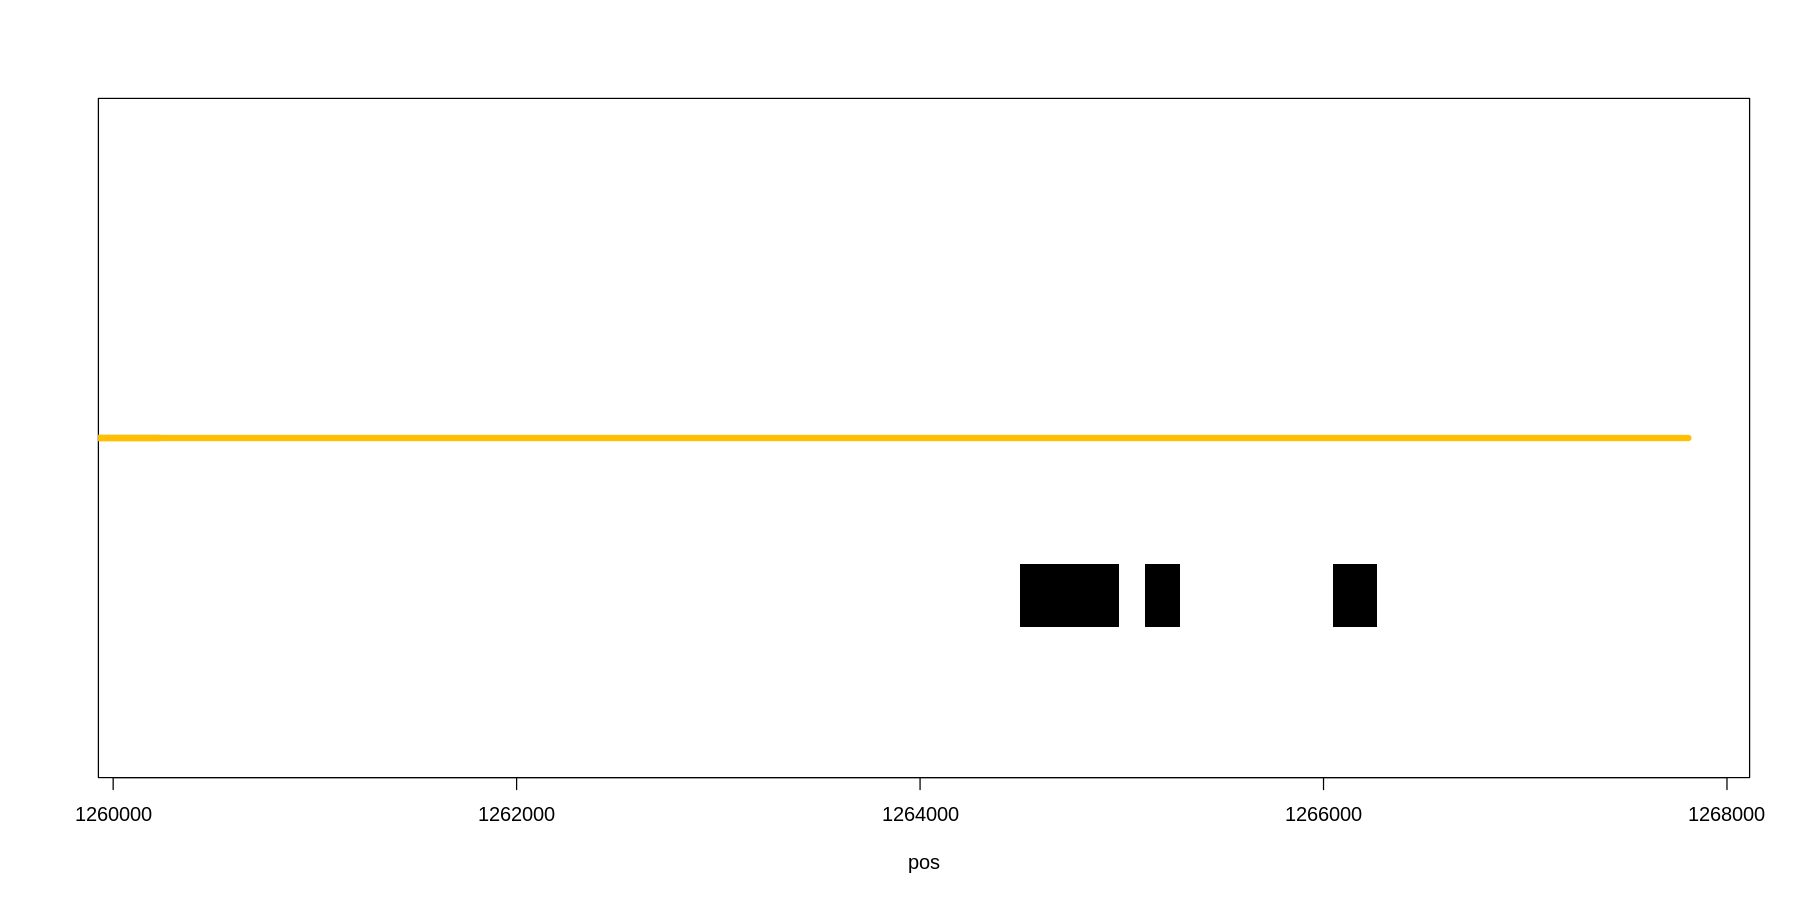

In [767]:
plot(0,0,xlim = range(unlist(sampleAGP_subset[1,2:3])),ylim = c(0,1),type ='n',xlab = "pos",ylab = "",yaxt ='n')
segments(x0 = min(sampleAGP_subset[1,2]),x1 = max(sampleAGP_subset[1,3]),y0 = 0.5, y1 = 0.5,col = "grey10")
segments(x0 = sampleAGP_subset[1,2],x1 = sampleAGP_subset[1:4,3],y0 = 0.5, y1 = 0.5,
         col = focal_ctg_col[sampleAGP_subset[1,6]],lwd = 5)
for(i in 2:5){
    rect(xleft = sampleGFF_subset[-1,4],xright = sampleGFF_subset[-1,5],border = "NA",
             ybottom = 0.2, ytop = 0.3, col = "black")
}


In [784]:
head(ref_gff_subset)

DataFrame with 4 rows and 18 columns
     seqid   source     type     start       end     score      strand
  <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1   scaf_1 miniprot      CDS   1995827   1996255       320           +
2   scaf_1 miniprot      CDS   1996553   1996723       105           +
3   scaf_1 miniprot      CDS   1997533   1997587        67           +
4   scaf_1 miniprot      CDS   1997960   1998082       144           +
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1         0          NA           1      0.5762          NA
2         1          NA           1      0.5000          NA
3         1          NA           1      0.7222          NA
4         0          NA           1      0.7209          NA
                  Target          Parent  Frameshift       Donor    Acceptor
             <character> <CharacterList> <character> <character> <character>
1 Pavag05G010800.1 34 .

In [618]:
head(ref_gff)

DataFrame with 6 rows and 18 columns
     seqid   source       type     start       end     score      strand
  <factor> <factor>   <factor> <integer> <integer> <numeric> <character>
1    Chr01 miniprot mRNA            1951      2616       983           +
2    Chr01 miniprot CDS             1951      2613       983           +
3    Chr01 miniprot stop_codon      2614      2616         0           +
4    Chr01 miniprot mRNA           11646     14601      2082           -
5    Chr01 miniprot CDS            14503     14601       152           -
6    Chr01 miniprot CDS            14321     14416       161           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000001           1      0.8610      0.9148
2         0          NA           1      0.8610          NA
3         0          NA           1          NA          NA
4        NA    MP000002           1      0.8946      0.9327
5         0        

In [642]:
mergedDF3[mergedDF3[,10]%in%"sbicol",]

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,missedBP,recoveredBP,reference_closest,distance,recoveryrate
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
197,AN21TSTL0224,4560,368,664,0,4928,664,61.10116,21.141420,sbicol,1.541980,0.3460069
246,MCRTL010,5470,24,98,0,5494,98,26.24425,8.053615,sbicol,0.827145,0.3068716


In [673]:
TABASCO_score[TABASCO_score[,1]=="AN21TSTL0253",]

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
145,AN21TSTL0253,1052,3980,558,2,5032,560


In [641]:
head(mergedDF3)

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,missedBP,recoveredBP,reference_closest,distance,recoveryrate
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,AN20T004,5128,188,269,7,5316,276,34.61104,11.50883,smicro,1.288258,0.3325190
2,AN20T007,3853,589,1149,1,4442,1150,84.93397,31.40734,hconto,0.140806,0.3697854
3,AN20T009,2646,1841,1105,0,4487,1105,83.61481,36.80554,hconto,0.000000,0.4401797
4,AN20T010,4254,445,890,3,4699,893,70.47962,23.68118,ttrian,2.337557,0.3360004
5,AN20T012,4563,397,629,3,4960,632,66.80269,25.00538,ttrian,1.852108,0.3743169
6,AN20T014,2889,1272,1430,1,4161,1431,92.13951,35.88481,blagur,1.877049,0.3894618


In [29]:
table(TE[,3])


similarity 
    519156 

# evaluation on contig miniProt results

In [17]:
eval_scaffold = function(j){
    gff_original = readGFF(paste0("/workdir/sh2246/p_phyloGWAS/output/relaxedMiniProt/",j,".gff"))

    if(nrow(gff_original)>0) {
        gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

        queryStat_original = strsplit2(gff.mrna_original$Target," ")
        queryStat_original = as.data.frame(queryStat_original)
        colnames(queryStat_original) = c("query","start","end")
        queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

        qcov_original=c()
        for (i in unique(queryStat_original[,1])){
          qcov_original=c(qcov_original,queryStat_original[queryStat_original[,1]==i,4]/queryFa_length[i])
        }
        queryStat_original$coverage = qcov_original

        queryStat_original[,2] = as.numeric(queryStat_original[,2])
        queryStat_original[,3] = as.numeric(queryStat_original[,3])

        queryLengthCov_original <- queryStat_original %>% group_by(query) %>% 
        summarise(TotalRange = calculate_range(start, end))
        queryLengthCov_original = as.data.frame(queryLengthCov_original)
        rownames(queryLengthCov_original)=queryLengthCov_original[,1]

        out = queryFa_length[queryLengthCov_original[,1]]-queryLengthCov_original[,2]
        names(out) = queryLengthCov_original[,1]
        return(out)
    }
    else return(NULL)
}


In [18]:
sampleID = gsub(".gff","",list.files("/workdir/sh2246/p_phyloGWAS/output/relaxedMiniProt/"))
missBP = simplify2array(mclapply(sampleID,eval_scaffold,mc.cores = 30))

In [20]:
names(missBP) = sampleID

In [21]:
missBP_noMissing = simplify2array(missBP[!sapply(missBP,length)==0])

In [22]:
missBP_noMissing = sapply(missBP_noMissing,function(x) x[names(queryFa_length)])

In [23]:
rownames(missBP_noMissing) = names(queryFa_length)

In [24]:
missBP_naFilled = apply(missBP_noMissing,2,function(x) {
    x[is.na(x)] = queryFa_length[is.na(x)]
    return(x)
})

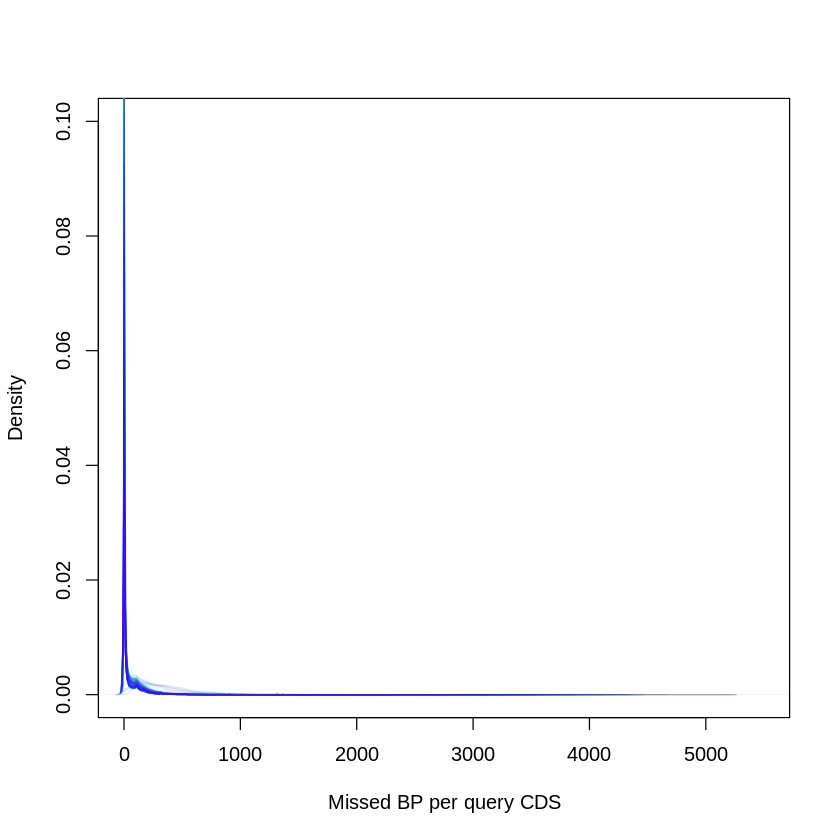

In [30]:
plot(density(missBP_naFilled[,1],na.rm = T),col = alpha(rainbow(500)[1],.1),xlim = c(0,5.5e3),ylim = c(0,0.1),
     xlab = "Missed BP per query CDS",main = "")
for (i in 2:ncol(missBP_naFilled)){
    if (sum(is.na(missBP_naFilled[,i]))!=ncol(missBP_naFilled)) points(density(missBP_naFilled[,i],na.rm = T),type = "l",col = alpha(rainbow(500)[i],.1))
}

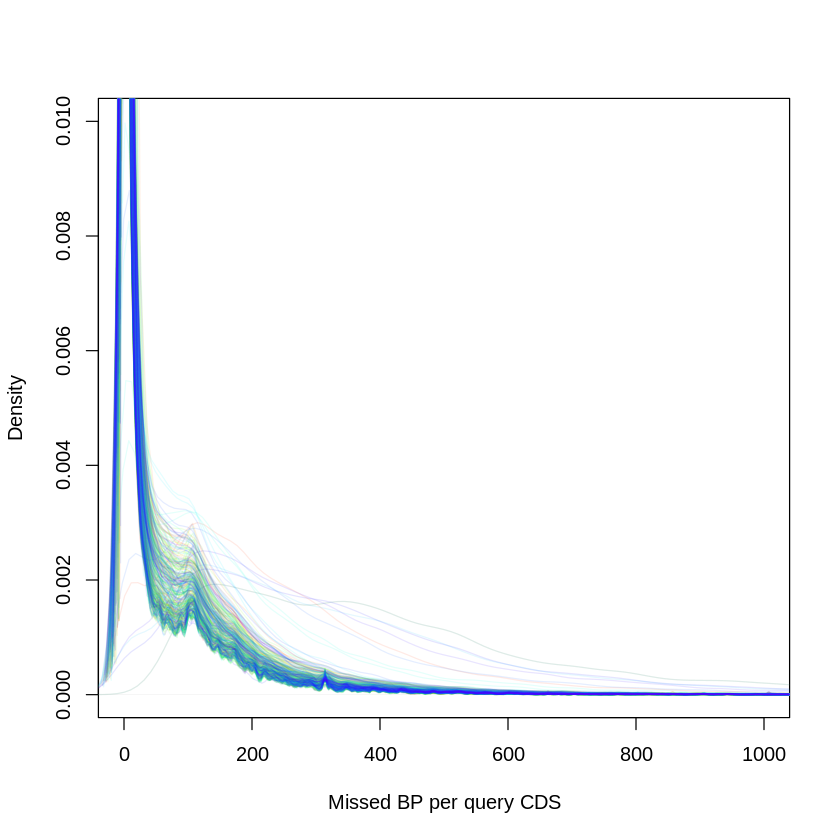

In [31]:
plot(density(missBP_naFilled[,1],na.rm = T),col = alpha(rainbow(500)[1],.1),xlim = c(0,1e3),ylim = c(0,0.01),
     xlab = "Missed BP per query CDS",main = "")
for (i in 2:ncol(missBP_naFilled)){
    if (sum(is.na(missBP_naFilled[,i]))!=ncol(missBP_naFilled)) points(density(missBP_naFilled[,i],na.rm = T),type = "l",col = alpha(rainbow(500)[i],.1))
}

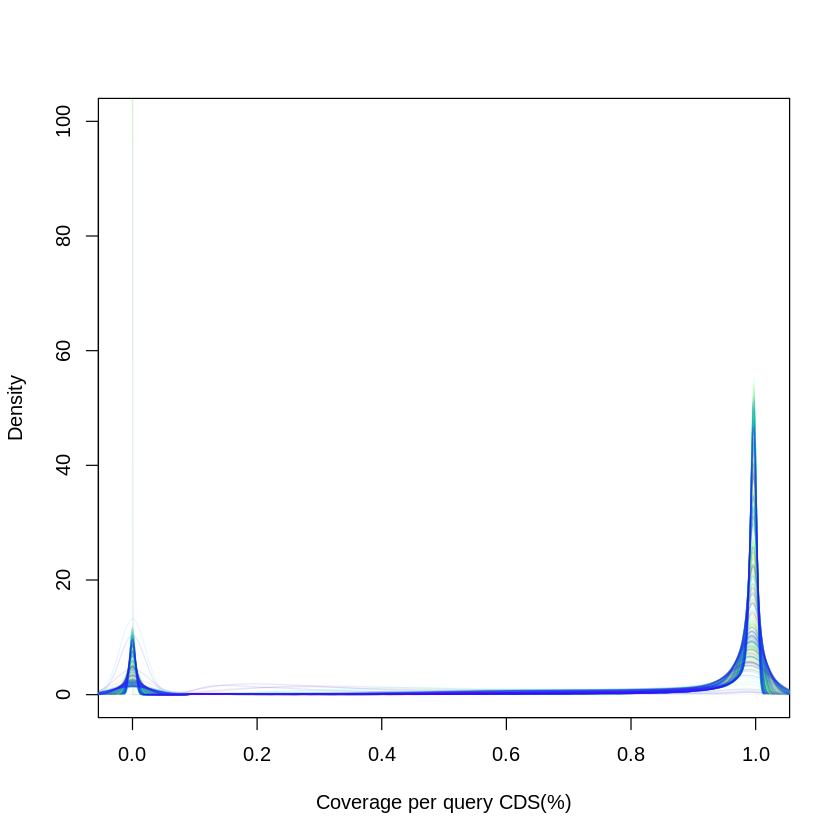

In [32]:
plot(density(1-missBP_naFilled[,1]/queryFa_length,na.rm = T),col = alpha(rainbow(500)[1],.1),ylim = c(0,100),
     xlab = "Coverage per query CDS(%)",main = "")
for (i in 2:ncol(missBP_naFilled)){
    if (sum(is.na(missBP_naFilled[,i]))!=ncol(missBP_naFilled)) points(density(1-missBP_naFilled[,i]/queryFa_length,na.rm = T),type = "l",col = alpha(rainbow(500)[i],.1))
}

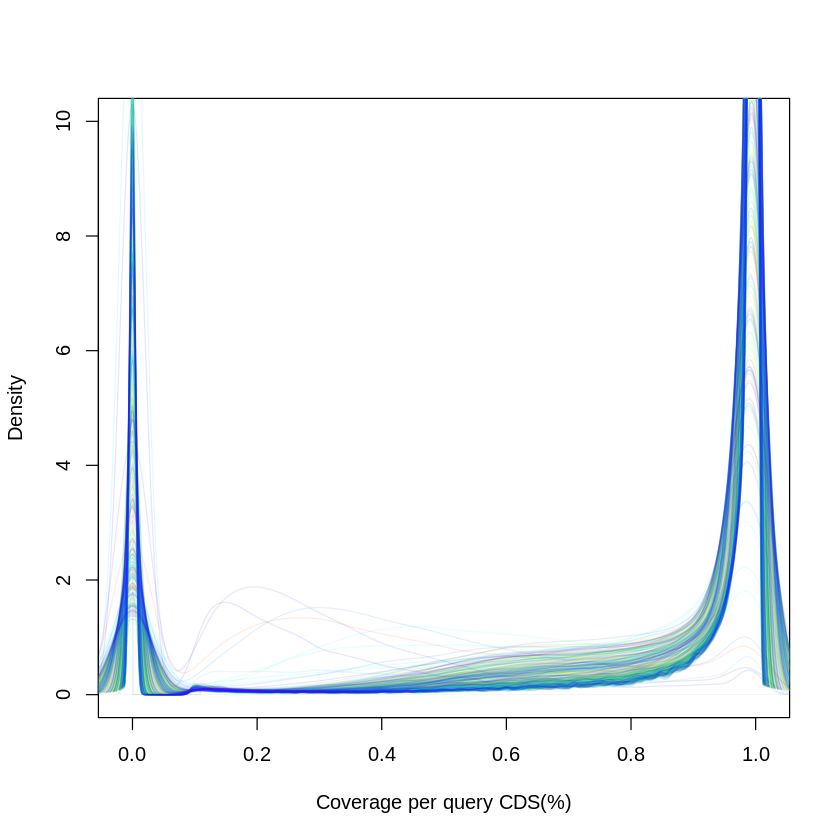

In [33]:
plot(density(1-missBP_naFilled[,1]/queryFa_length,na.rm = T),col = alpha(rainbow(500)[1],.1),ylim = c(0,10),
     xlab = "Coverage per query CDS(%)",main = "")
for (i in 2:ncol(missBP_naFilled)){
    if (sum(is.na(missBP_naFilled[,i]))!=ncol(missBP_naFilled)) points(density(1-missBP_naFilled[,i]/queryFa_length,na.rm = T),type = "l",col = alpha(rainbow(500)[i],.1))
}

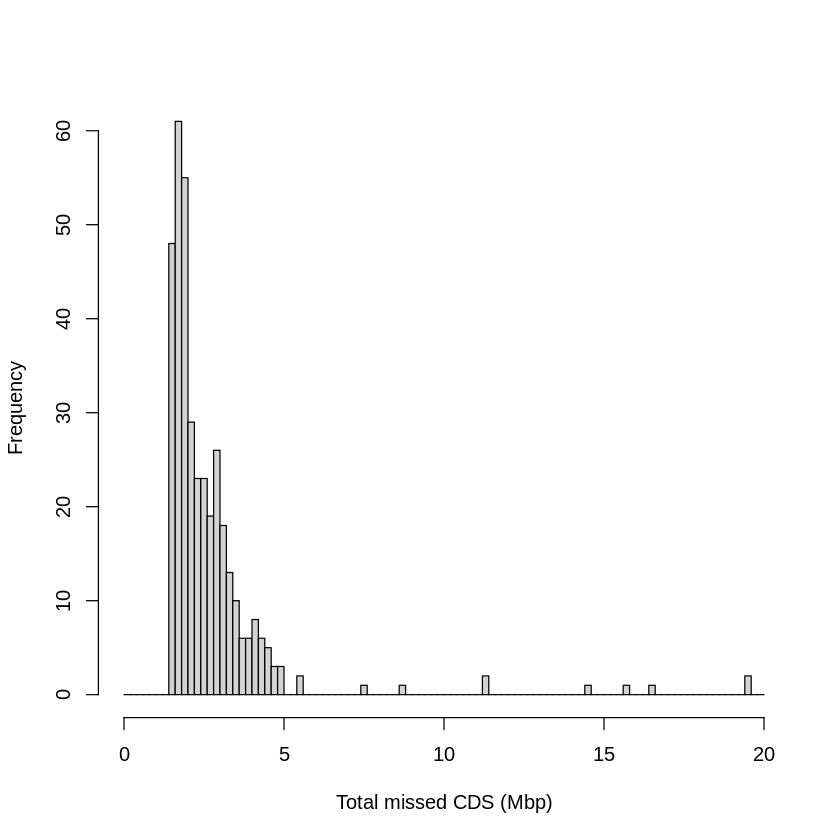

In [34]:
hist(colSums(missBP_naFilled)/1e6,main = "",xlab = "Total missed CDS (Mbp)",breaks = seq(0,2e7,2e5)/1e6)
# axis(1,at = 0:6,c(1,1e1,1e2,1e3,1e4,1e5,1e6))

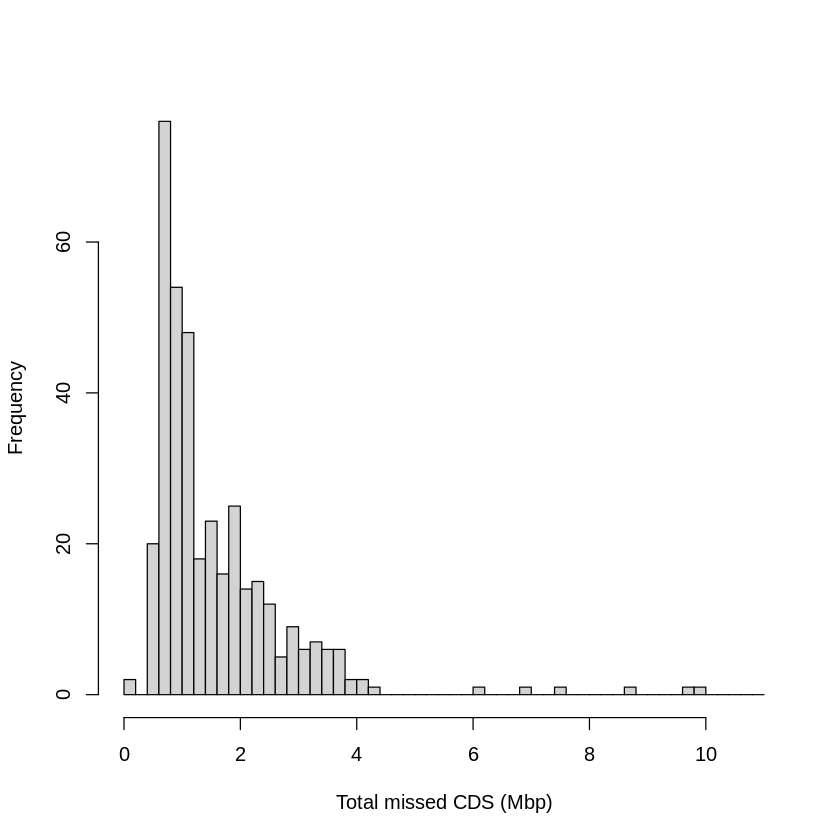

In [35]:
hist(colSums(missBP_noMissing,na.rm = T)/1e6,main = "",xlab = "Total missed CDS (Mbp)",breaks = seq(0,11e6,2e5)/1e6)
# axis(1,at = 0:6,c(1,1e1,1e2,1e3,1e4,1e5,1e6))

In [26]:
longestTranscript = read.table('/workdir/sh2246/p_evolBNI/data/Pv_v3.1_longestTranscript.txt',header = F)[,1]

In [27]:
length(longestTranscript)

[1] 35565

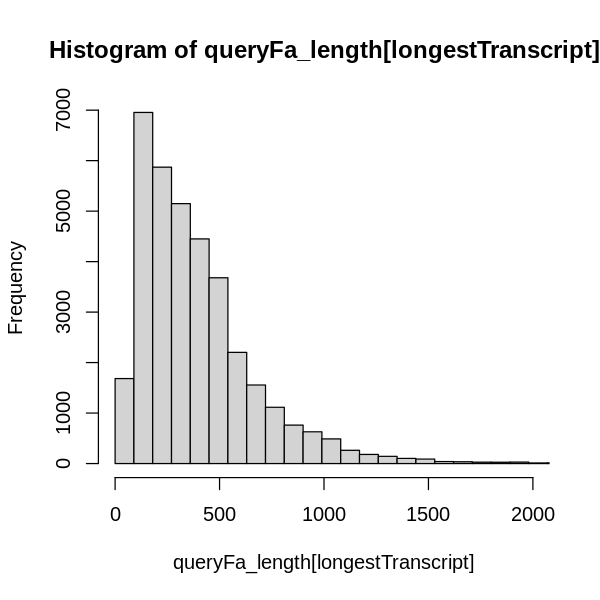

In [38]:
options(repr.plot.width = 5,repr.plot.height = 5)
hist(queryFa_length[longestTranscript],breaks = seq(0,6000,90),xlim = c(0,2000))

In [39]:
sum(queryFa_length<90)

[1] 1790

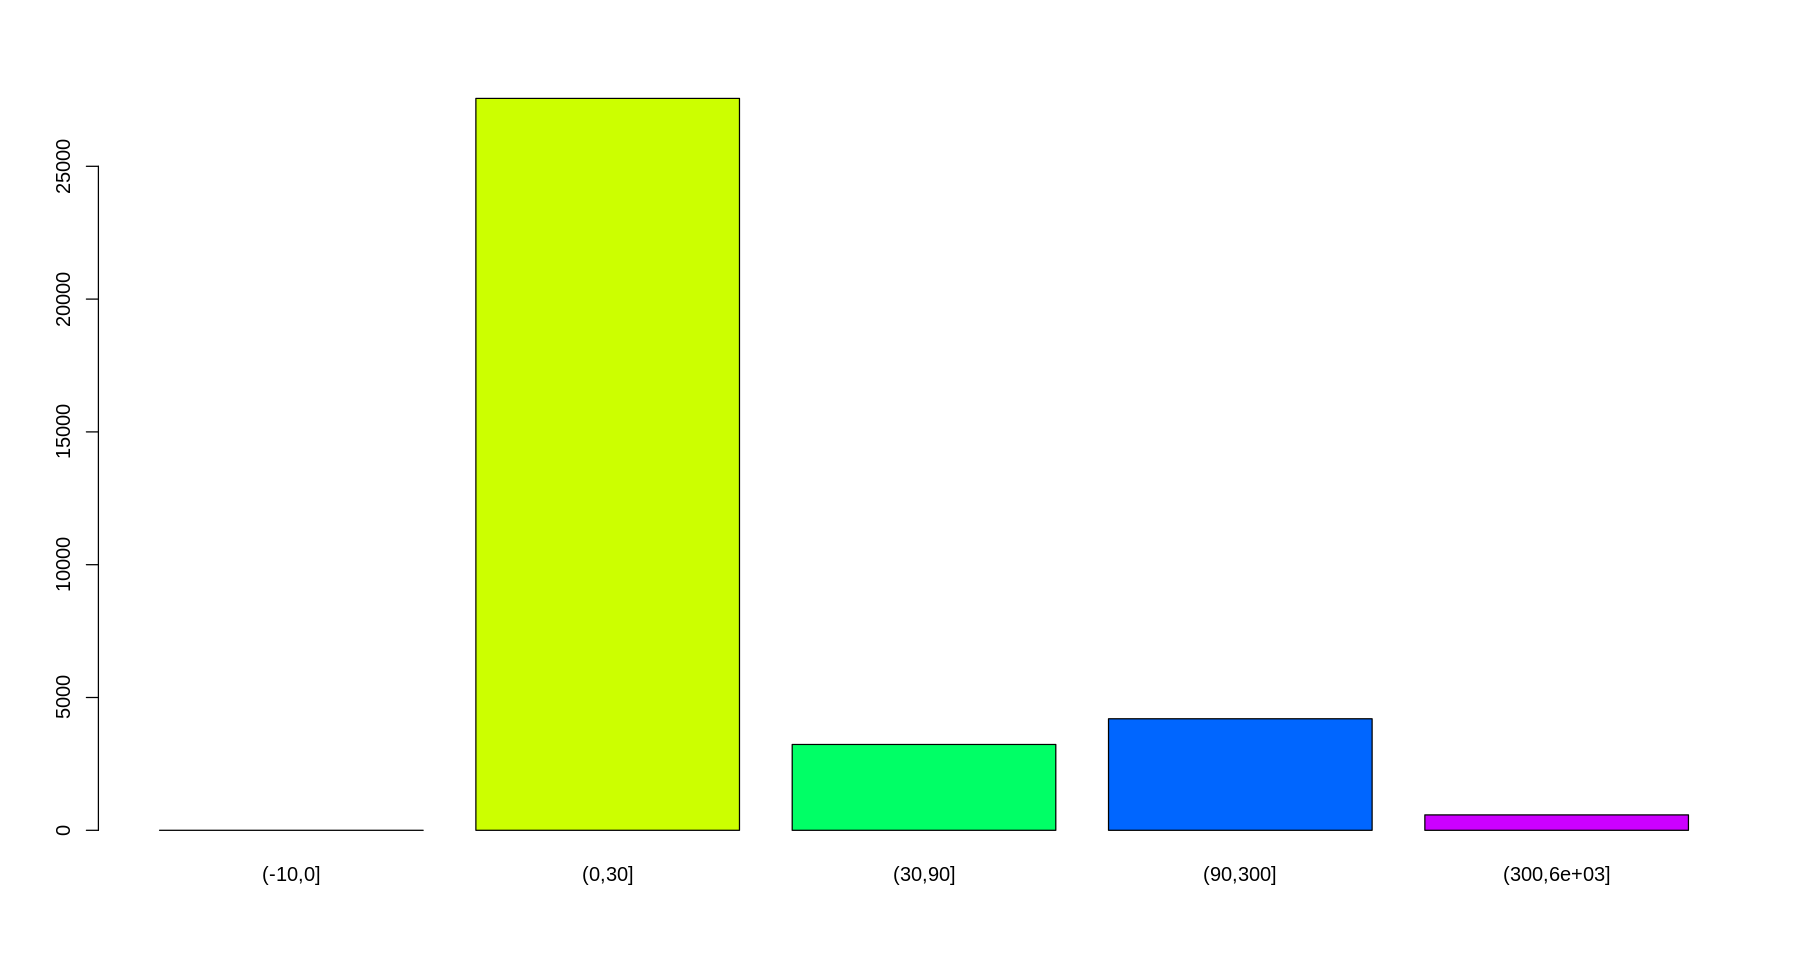

In [68]:
options(repr.plot.width = 15,repr.plot.height = 8)
barplot(table(cut(missBP_naFilled[longestTranscript,1],c(-10,0,30,90,300,6e3))),col =rainbow(5)[1:5] )

In [65]:
missBP_cat = apply(missBP_naFilled[longestTranscript,],2,function(x) table(as.numeric(cut(x,c(-10,0,30,90,300,6e3))))[as.character(1:5)])

In [66]:
missBP_cat[is.na(missBP_cat)]=0

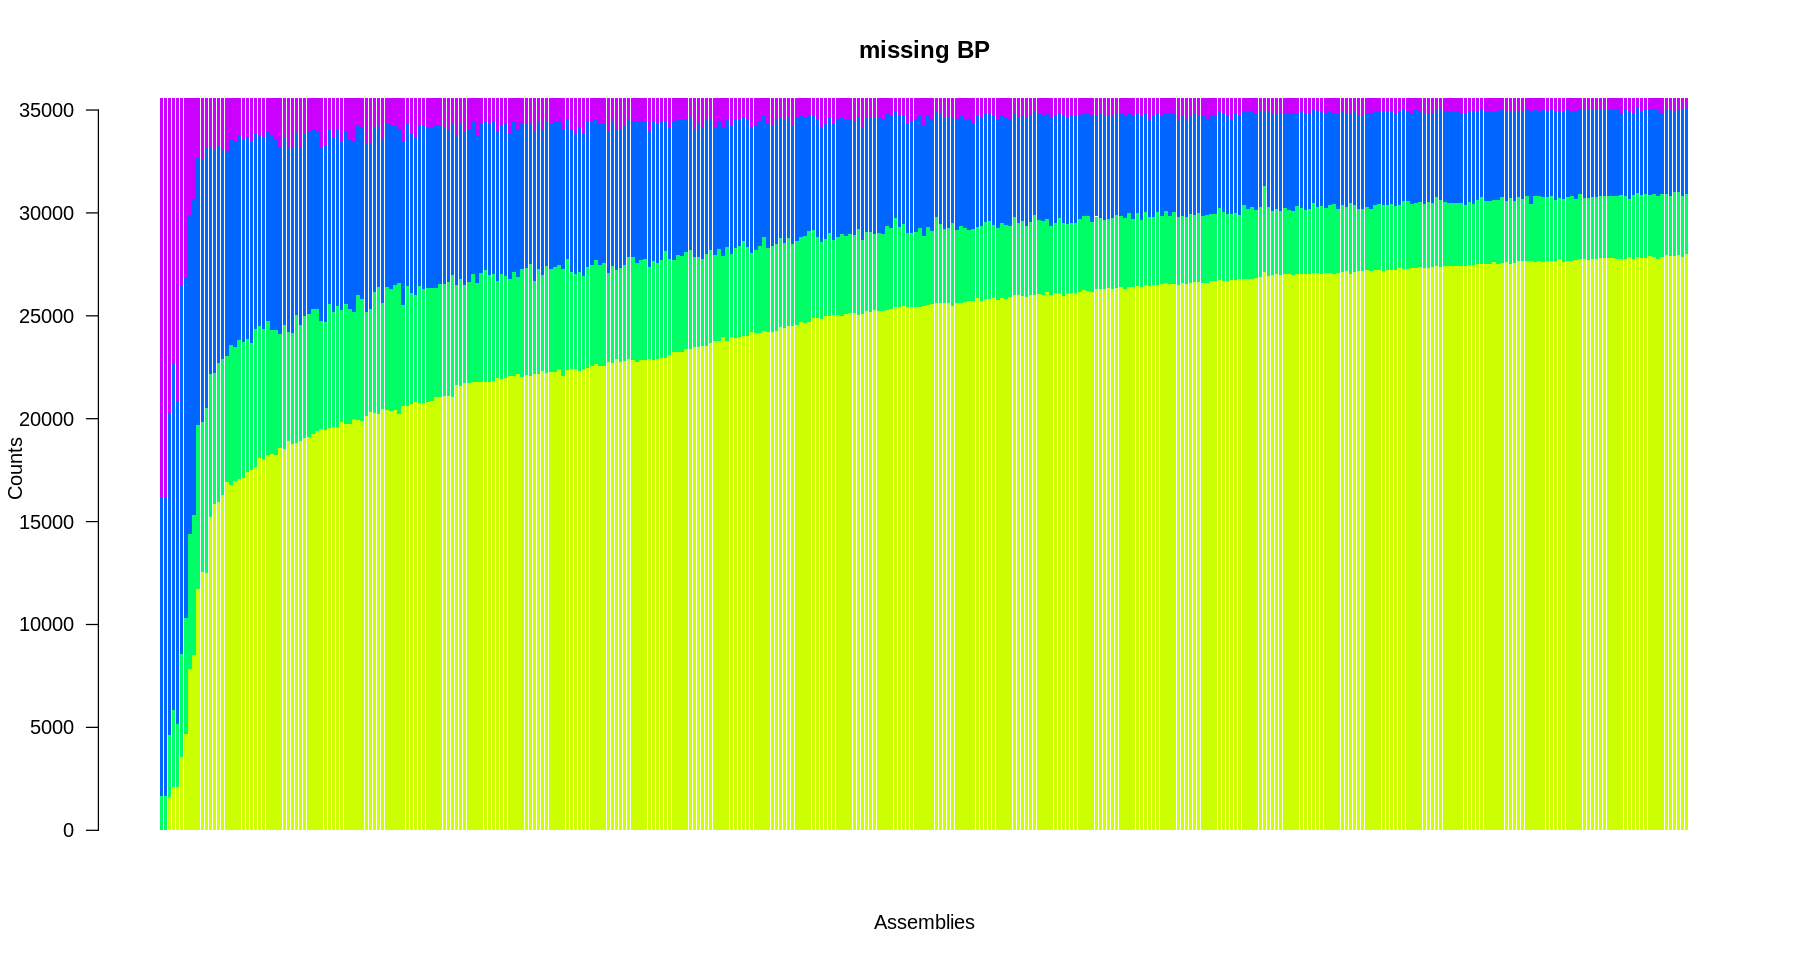

In [67]:
barplot(missBP_cat[,order(cov_cat[1,])],col =rainbow(5),border = NA,las = 2,xaxt='n',
        xlab = "Assemblies",ylab = "Counts",main = "missing BP")

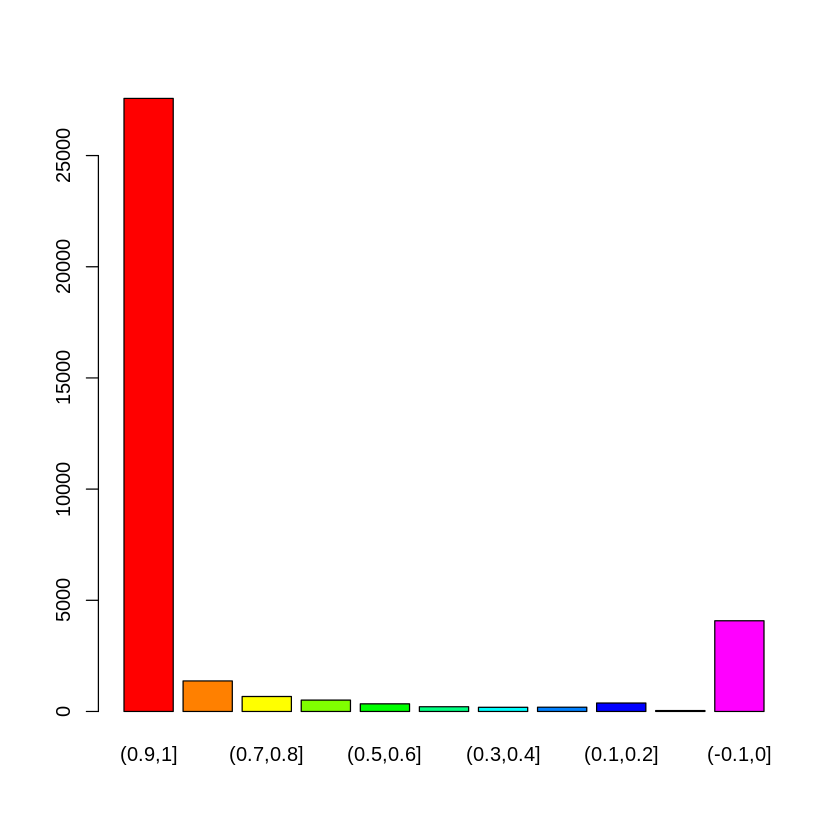

In [28]:
barplot(rev(table(cut(1-missBP_naFilled[longestTranscript,1]/queryFa_length[longestTranscript],seq(-0.1,1,0.1)))),col =rainbow(12)[1:11] )

In [29]:
cov_cat = apply(missBP_naFilled[longestTranscript,],2,function(x) table(12-as.numeric(cut(1-x/queryFa_length[longestTranscript],seq(-0.1,1,0.1))))[as.character(1:11)])

In [30]:
cov_cat[is.na(cov_cat)] = 0

In [37]:
cov_cat[colnames(missBP_naFilled)=="AN20T001.scaffolded"]

numeric(0)

In [36]:
colnames(missBP_naFilled)

[1] "AN20T004.scaffolded"        "AN20T007.scaffolded"       
  [3] "AN20T009.scaffolded"        "AN20T010.scaffolded"       
  [5] "AN20T011.scaffolded"        "AN20T012.scaffolded"       
  [7] "AN20T014.scaffolded"        "AN20T015.scaffolded"       
  [9] "AN20T018.scaffolded"        "AN20T019.scaffolded"       
 [11] "AN20T020.scaffolded"        "AN20T021.scaffolded"       
 [13] "AN20T022.scaffolded"        "AN20T023.scaffolded"       
 [15] "AN20T024.scaffolded"        "AN20T025.scaffolded"       
 [17] "AN20T026.scaffolded"        "AN20T027.scaffolded"       
 [19] "AN20T035.scaffolded"        "AN20T036.scaffolded"       
 [21] "AN20T039.scaffolded"        "AN20T041.scaffolded"       
 [23] "AN20T168.scaffolded"        "AN20T169.scaffolded"       
 [25] "AN20T170.scaffolded"        "AN20T172.scaffolded"       
 [27] "AN20T174.scaffolded"        "AN20T175.scaffolded"       
 [29] "AN20T176.scaffolded"        "AN20T177.scaffolded"       
 [31] "AN20T179.scaffolded"        "AN20T183.scaffolded"       
 [33] "AN20T184.scaffolded"        "AN20T185.scaffolded"       
 [35] "AN20T190.scaffolded"        "AN20T191.scaffolded"       
 [37] "AN20T192.scaffolded"        "AN20T193.scaffolded"       
 [39] "AN20T194.scaffolded"        "AN20T195.scaffolded"       
 [41] "AN20T196.scaffolded"        "AN20T197.scaffolded"       
 [43] "AN20TSCR000199.scaffolded"  "AN20TSCR000212.scaffolded" 
 [45] "AN20TSCR000218.scaffolded"  "AN21TNTL0075.scaffolded"   
 [47] "AN21TNTL0077.scaffolded"    "AN21TNTL0079.scaffolded"   
 [49] "AN21TNTL0081.scaffolded"    "AN21TNTL0085.scaffolded"   
 [51] "AN21TNTL0090.scaffolded"    "AN21TNTL0091.scaffolded"   
 [53] "AN21TNTL0092.scaffolded"    "AN21TNTL0094.scaffolded"   
 [55] "AN21TNTL0095.scaffolded"    "AN21TNTL0096.scaffolded"   
 [57] "AN21TNTL0097.scaffolded"    "AN21TNTL0098.scaffolded"   
 [59] "AN21TNTL0099.scaffolded"    "AN21TNTL0100.scaffolded"   
 [61] "AN21TNTL0101.scaffolded"    "AN21TNTL0102.scaffolded"   
 [63] "AN21TNTL0104.scaffolded"    "AN21TNTL0106.scaffolded"   
 [65] "AN21TNTL0107.scaffolded"    "AN21TNTL0108.scaffolded"   
 [67] "AN21TNTL0109.scaffolded"    "AN21TNTL0111.scaffolded"   
 [69] "AN21TNTL0112.scaffolded"    "AN21TNTL0114.scaffolded"   
 [71] "AN21TNTL0115.scaffolded"    "AN21TNTL0116.scaffolded"   
 [73] "AN21TNTL0117.scaffolded"    "AN21TNTL0118.scaffolded"   
 [75] "AN21TNTL0119.scaffolded"    "AN21TNTL0120.scaffolded"   
 [77] "AN21TNTL0121.scaffolded"    "AN21TNTL0125.scaffolded"   
 [79] "AN21TNTL0128.scaffolded"    "AN21TNTL0129.scaffolded"   
 [81] "AN21TNTL0131.scaffolded"    "AN21TNTL0135.scaffolded"   
 [83] "AN21TNTL0137.scaffolded"    "AN21TNTL0138.scaffolded"   
 [85] "AN21TNTL0139.scaffolded"    "AN21TNTL0144.scaffolded"   
 [87] "AN21TNTL0148.scaffolded"    "AN21TNTL0151.scaffolded"   
 [89] "AN21TNTL0153.scaffolded"    "AN21TNTL0156.scaffolded"   
 [91] "AN21TNTL0157.scaffolded"    "AN21TNTL0161.scaffolded"   
 [93] "AN21TNTL0163.scaffolded"    "AN21TNTL0167.scaffolded"   
 [95] "AN21TNTL0169.scaffolded"    "AN21TNTL0171.scaffolded"   
 [97] "AN21TNTL0172.scaffolded"    "AN21TNTL0174.scaffolded"   
 [99] "AN21TNTL0175.scaffolded"    "AN21TNTL0177.scaffolded"   
[101] "AN21TNTL0294.scaffolded"    "AN21TNTL0296.scaffolded"   
[103] "AN21TNTL0304.scaffolded"    "AN21TNTL0309.scaffolded"   
[105] "AN21TNTL0314.scaffolded"    "AN21TNTL0316.scaffolded"   
[107] "AN21TNTL0318.scaffolded"    "AN21TNTL0321.scaffolded"   
[109] "AN21TNTL0324.scaffolded"    "AN21TNTL0334.scaffolded"   
[111] "AN21TNTL0335.scaffolded"    "AN21TNTL0341.scaffolded"   
[113] "AN21TNTL0343.scaffolded"    "AN21TNTL0344.scaffolded"   
[115] "AN21TNTL0345.scaffolded"    "AN21TNTL0346.scaffolded"   
[117] "AN21TNTL0348.scaffolded"    "AN21TNTL0352.scaffolded"   
[119] "AN21TNTL0355.scaffolded"    "AN21TNTL0359.scaffolded"   
[121] "AN21TNTL0363.scaffolded"    "AN21TNTL0365.scaffolded"   
[123] "AN21TNTL0366.scaffolded"    "AN21TNTL0368.scaffolded"   
[125] "AN21TS02.scaffolded"       

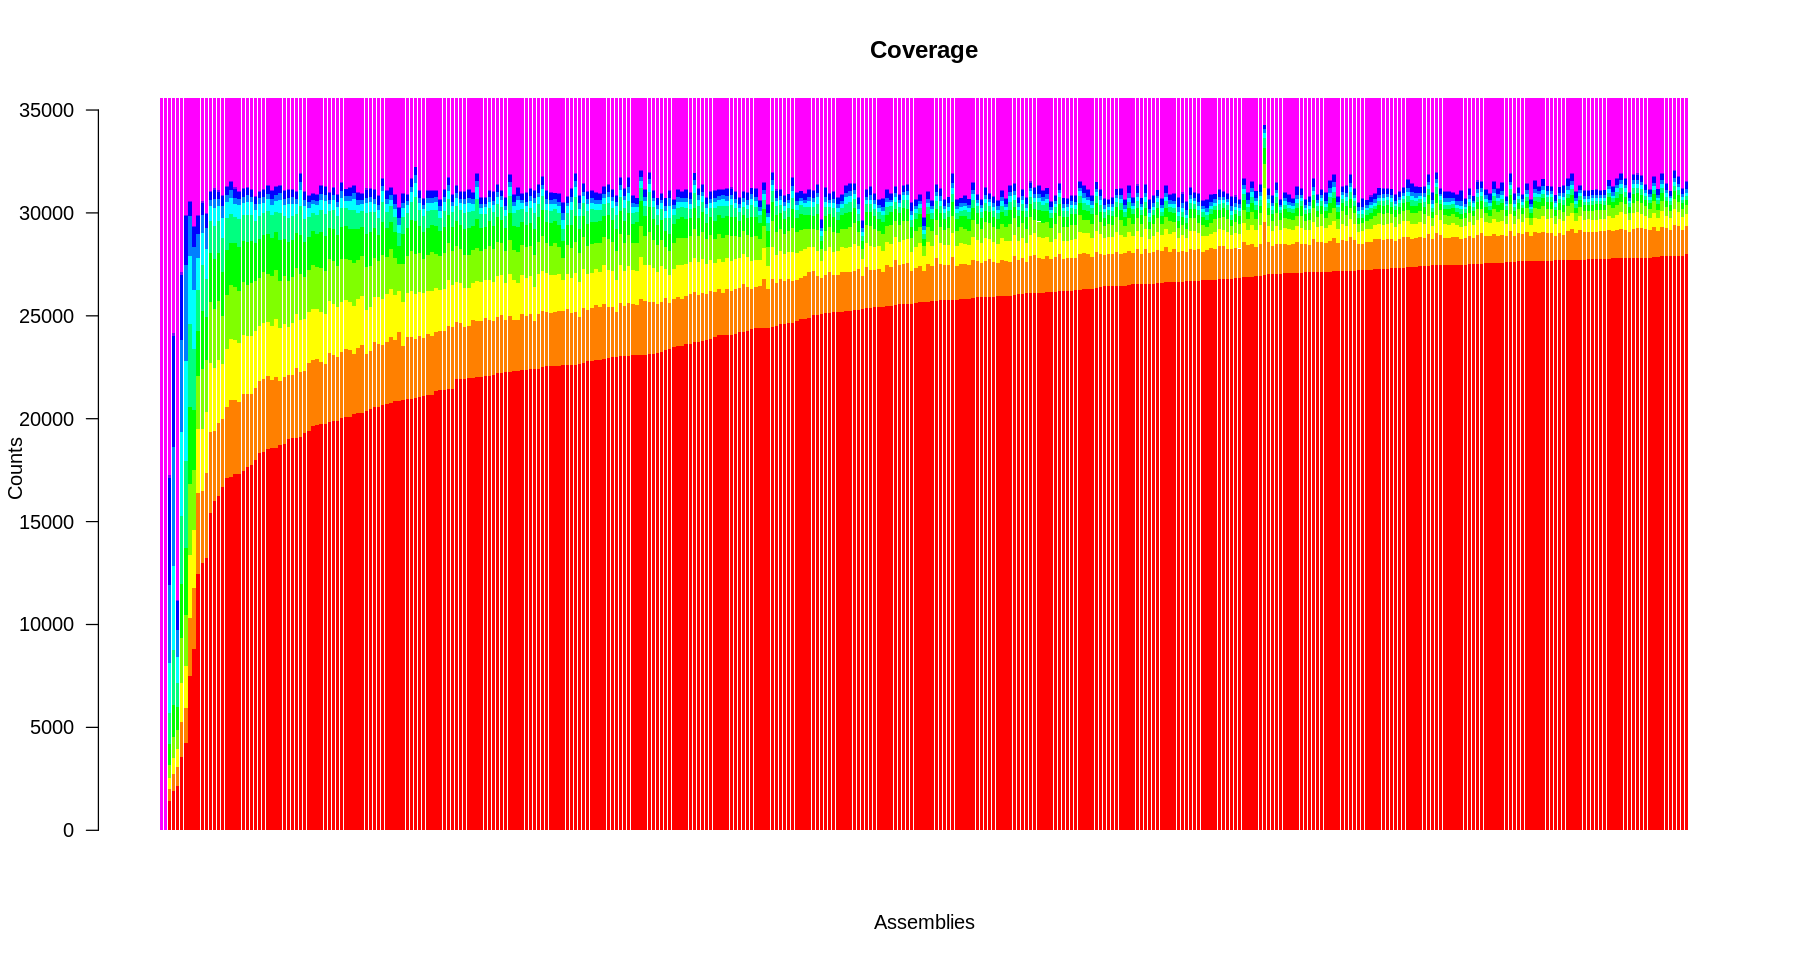

In [47]:
barplot(cov_cat[,order(cov_cat[1,])],col = rainbow(12)[1:11],border =NA,las = 2,xaxt='n',
        xlab = "Assemblies",ylab = "Counts",main = "Coverage")

In [5]:
eval_contig = function(j){
    gff_original = readGFF(paste0("/workdir/sh2246/p_phyloGWAS/output/relaxedMiniProt/",j,".gff"))

    if(nrow(gff_original)>0) {
        gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

        queryStat_original = strsplit2(gff.mrna_original$Target," ")
        queryStat_original = as.data.frame(queryStat_original)
        colnames(queryStat_original) = c("query","start","end")
        queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

        out = table(queryStat_original[,1])[names(queryFa_length)]
        names(out) = names(queryFa_length)
        return(out)
    }
    else return(NULL)
}


In [6]:
numContig = simplify2array(mclapply(sampleID,eval_contig,mc.cores = 30))

Warning message in mclapply(sampleID, eval_contig, mc.cores = 30):
“all scheduled cores encountered errors in user code”


In [51]:
numContig_noMissing = simplify2array(numContig[!sapply(numContig,length)==0])

In [61]:
numContig_freq = apply(numContig_noMissing[longestTranscript,],2,function(x) table(x)[as.character(1:31)])

In [62]:
numContig_freq[is.na(numContig_freq)] = 0

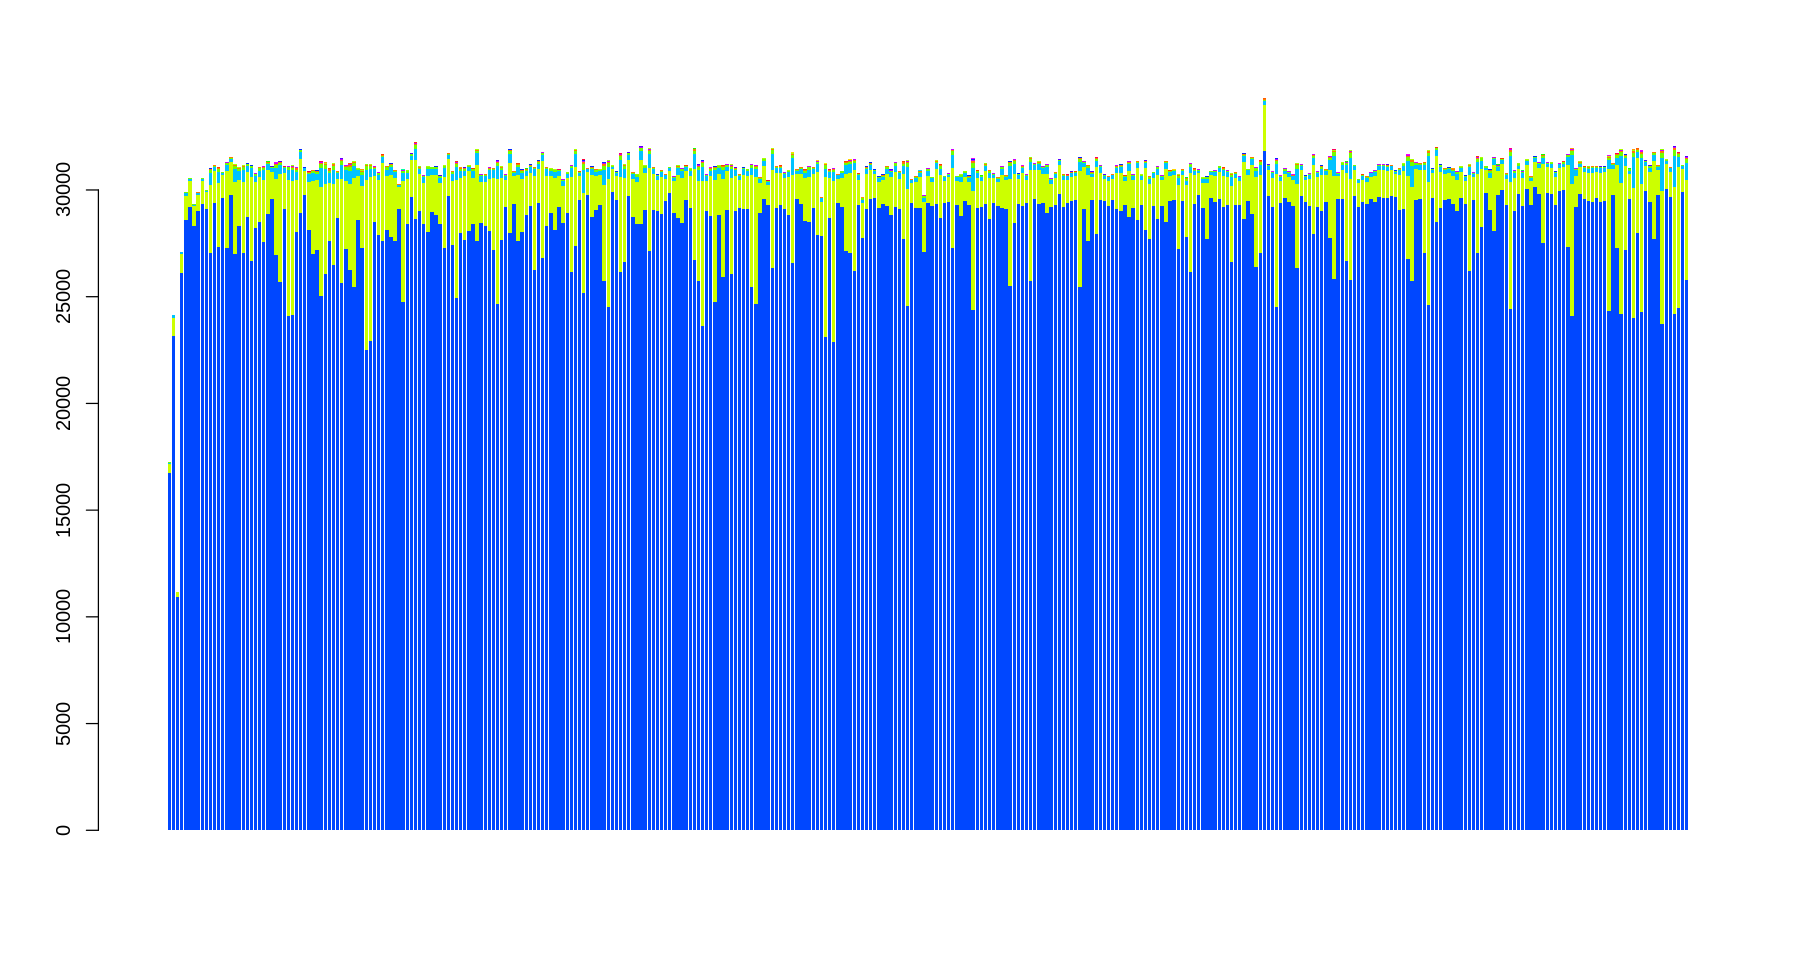

In [63]:
set.seed(666)
mybpcol = rainbow(50)[sample(1:50,31)]
barplot(numContig_freq[,order(cov_cat[1,])],col = mybpcol,border = NA)

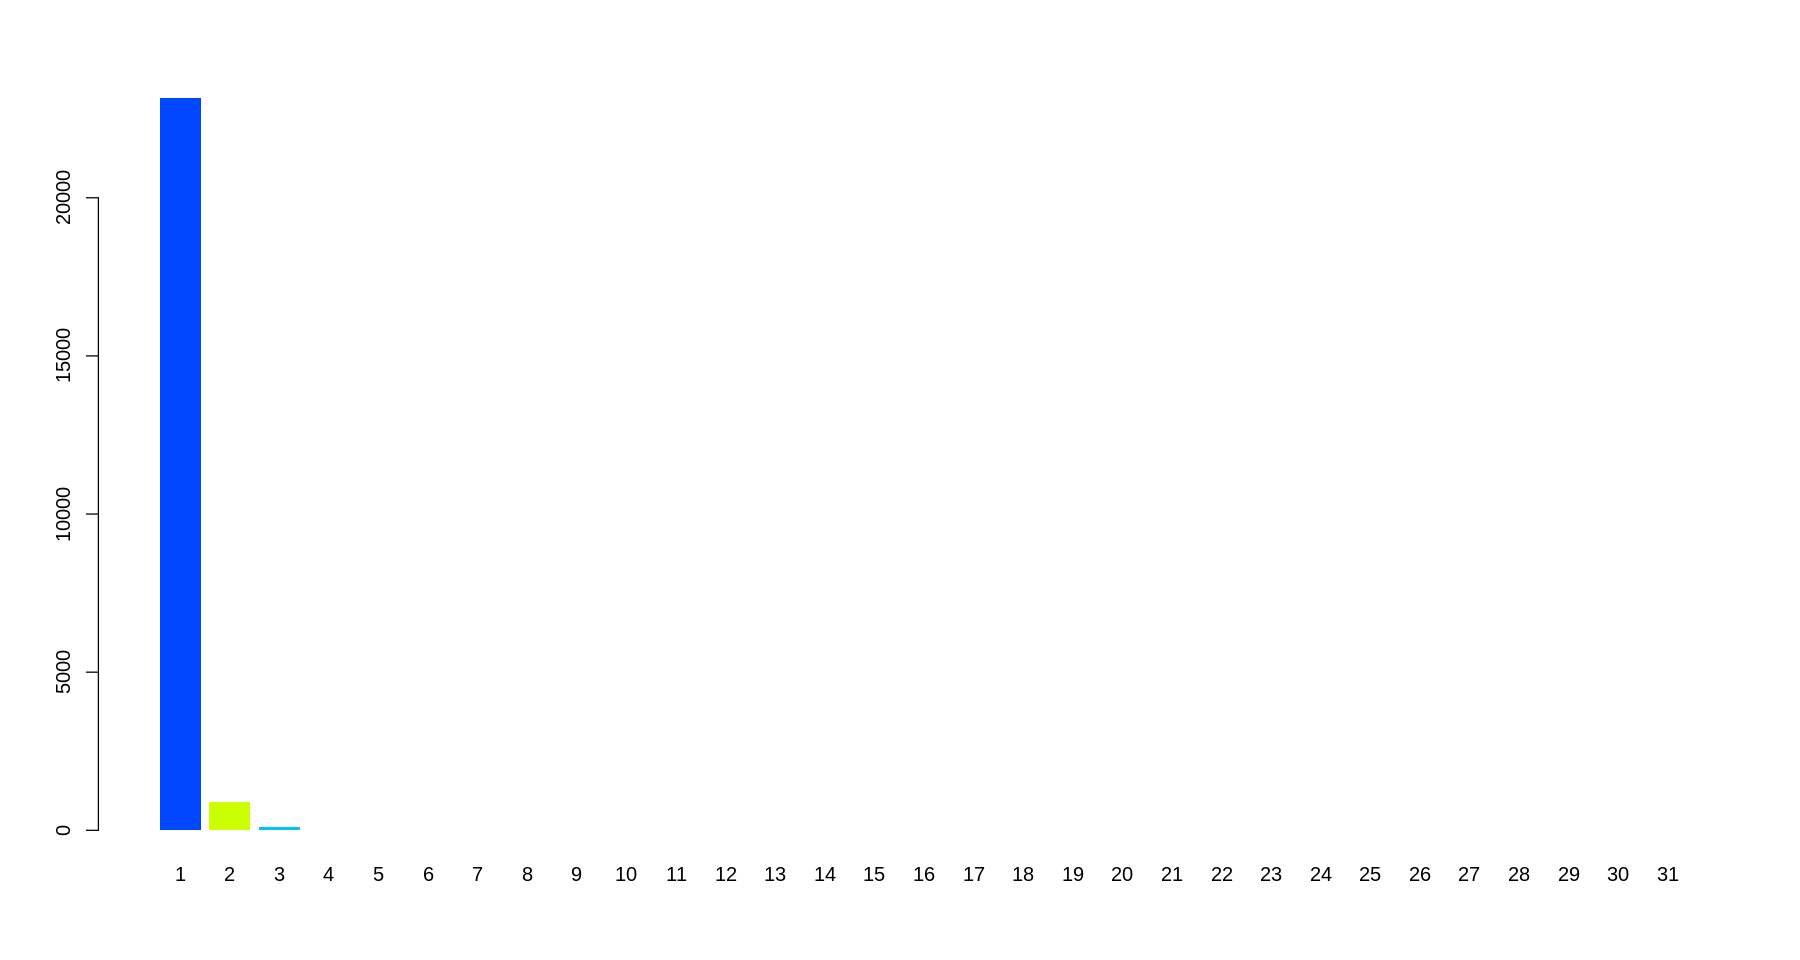

In [64]:
barplot(numContig_freq[,order(cov_cat[1,])[4]],col = mybpcol,border = NA,names.arg = 1:31)

In [1015]:
sum(colSums(numContig_freq[-1,],na.rm = T)>5e3)
sum(grepl("PanAnd",colnames(missBP_naFilled)[which(colSums(numContig_freq[-1,],na.rm = T)>8e3)]))

[1] 107

[1] 21

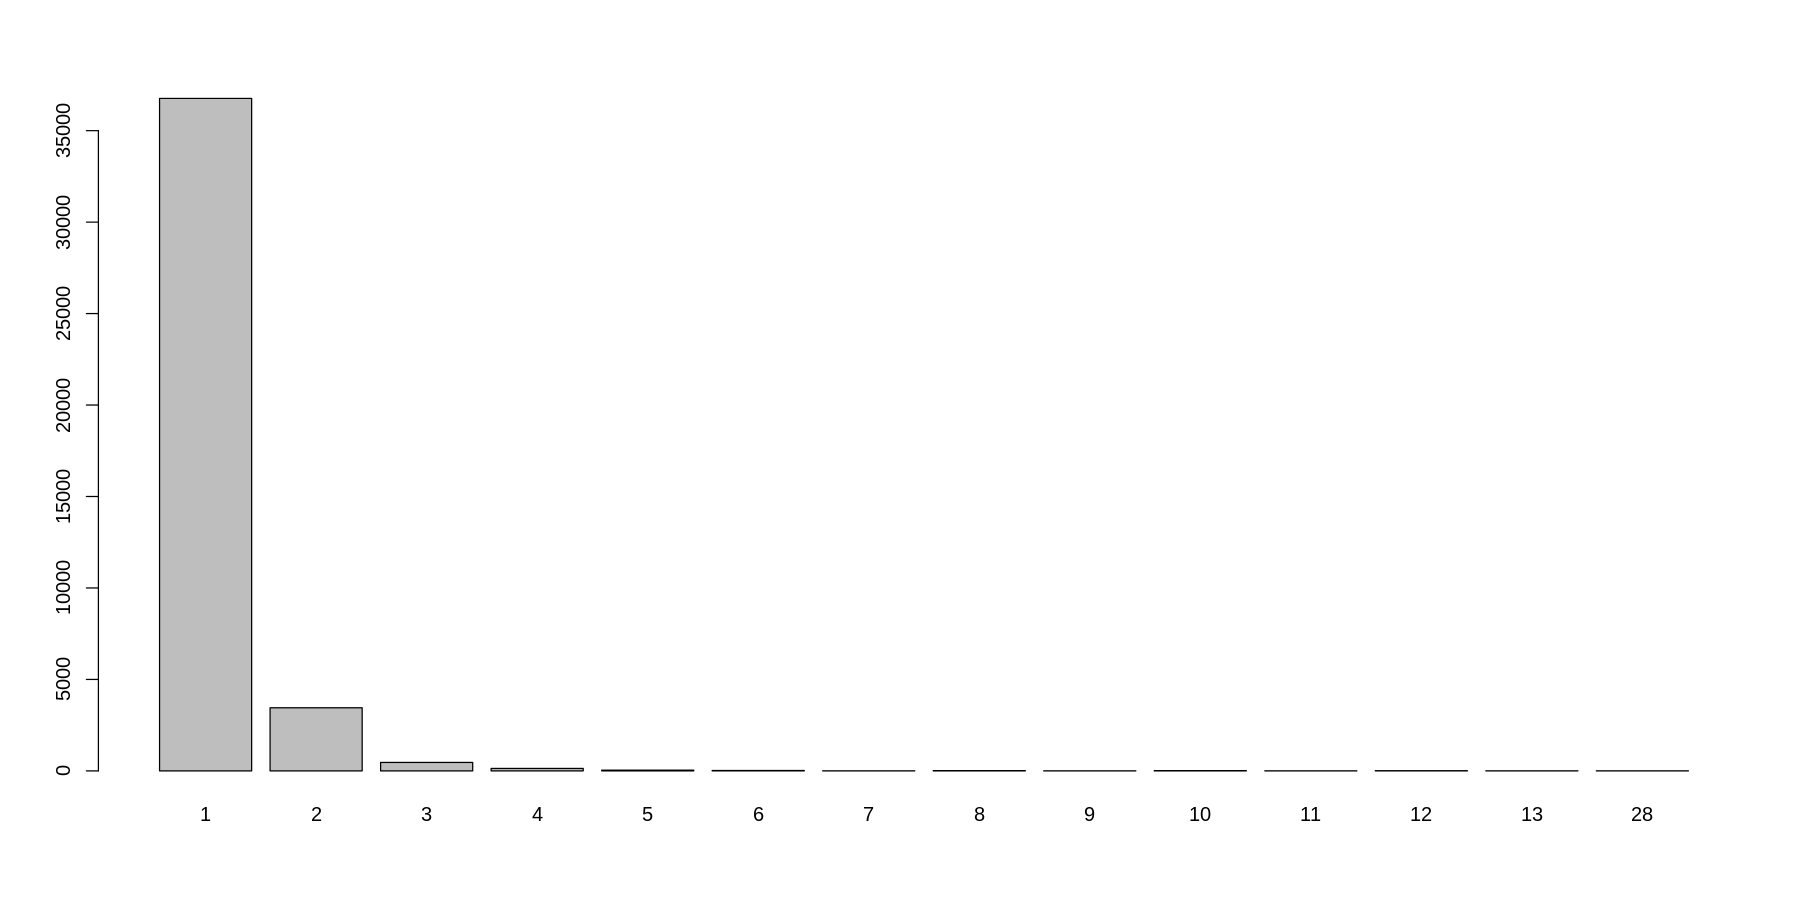

In [912]:
barplot(table(numContig_noMissing[,1]))

# distance to reference

In [229]:
d2ref = read.table("/workdir/sh2246/p_phyloGWAS/data/short2long.distances.tsv",header = T)

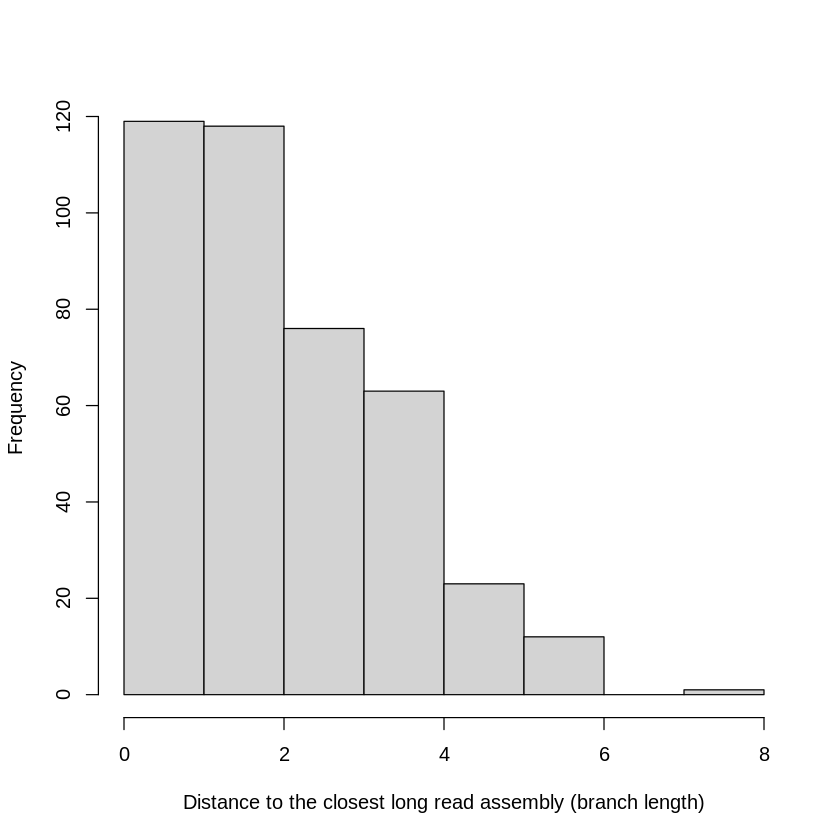

In [231]:
hist(d2ref[,3],main = "",xlab = "Distance to the closest long read assembly (branch length)")

In [486]:
table(d2ref[,2])
sum(table(d2ref[,2]))
length(table(d2ref[,2]))


achine agerar atenui avirgi blagur ccitra crefra cserru etrips hcompr hconto 
     6     95      3      7     42     19      4      7      9      5      2 
irugos ppanic pvagin rrottb rtuber sbicol smicro snutan sscopa tdacn1 telega 
    20     46      3      2      7      6     10     14     19     12     57 
ttrian udigit vcuspi zluxur zmhuet 
     9      1      3      1      3 

[1] 412

[1] 27

In [235]:
t(simplify2array(tapply(d2ref[,3],d2ref[,2],summary)))

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.
achine,1.061936,1.1339752,2.1365995,2.1491648,3.1674958,3.248959
agerar,0.000000,1.4169125,2.6352400,2.5849306,3.6144430,5.079033
atenui,0.000000,0.9970550,1.9941100,1.3294067,1.9941100,1.994110
avirgi,0.000000,0.5104105,0.5999530,0.5470689,0.7148940,0.778920
blagur,0.000000,0.3615153,1.1261965,1.5265519,1.7242960,5.455899
ccitra,0.000000,0.6559805,1.1217040,1.1406404,1.4469240,2.449727
crefra,0.192402,0.1924020,0.3787245,0.3787245,0.5650470,0.565047
cserru,0.000000,0.8399665,1.2726160,1.0272499,1.3653840,1.507432
etrips,0.000000,0.2113660,0.8177520,0.7604596,1.1002750,1.446208
hcompr,0.000000,0.2370020,2.0919080,1.5074064,2.6040610,2.604061


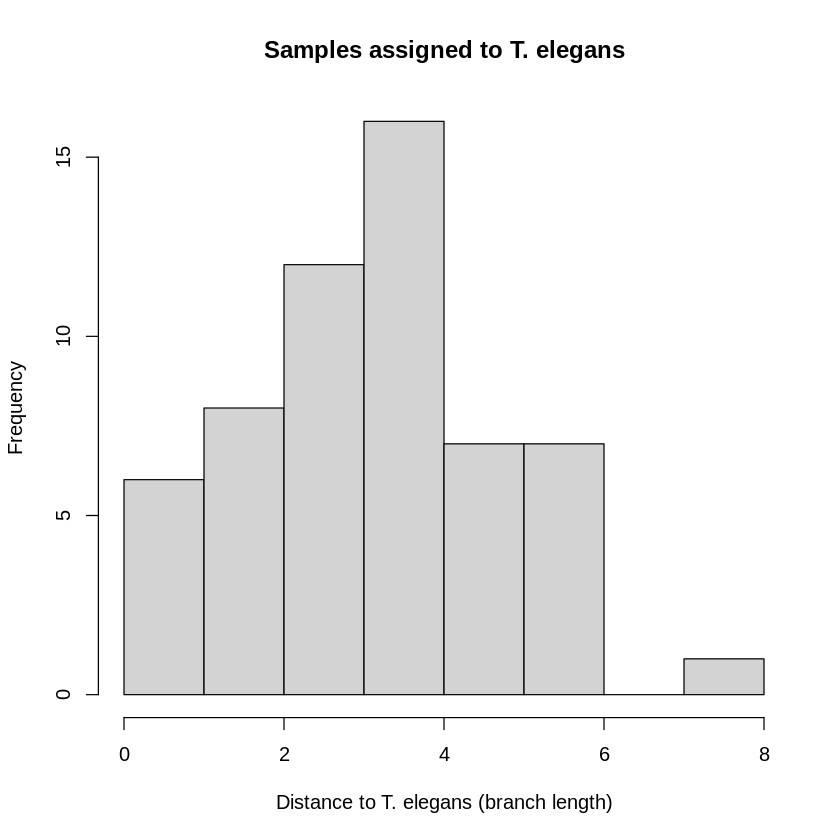

In [237]:
hist(d2ref[d2ref[,2]%in%"telega",3],main = "Samples assigned to T. elegans",xlab = "Distance to T. elegans (branch length)")

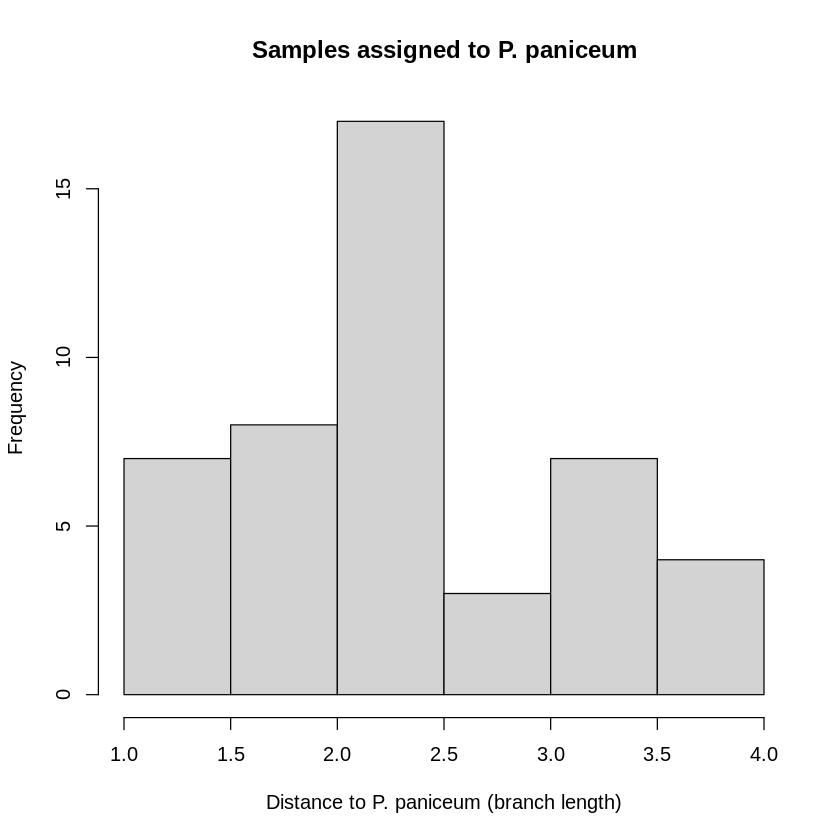

In [306]:
hist(d2ref[d2ref[,2]%in%"ppanic",3],main = "Samples assigned to P. paniceum",xlab = "Distance to P. paniceum (branch length)")

In [238]:
TABASCO_score = read.csv("/workdir/hackathon_202309/data/androTABASCO_2022.12.23.csv")

In [239]:
head(TABASCO_score)

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
1,MCRTL053,5440,94,54,4,5534,58
2,MCRTL007,5445,74,70,3,5519,73
3,MCRTL033,5471,42,74,5,5513,79
4,MCRTL063,5381,130,76,5,5511,81
5,MCRTL027,5355,154,77,6,5509,83
6,MCRTL003,5428,78,80,6,5506,86


In [307]:
TABASCO_score[TABASCO_score[,1]%in%d2ref[d2ref[,2]%in%"ppanic",1],]

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
3,MCRTL033,5471,42,74,5,5513,79
9,AN21TSTL0214,5408,97,85,2,5505,87
13,AN21TS63,5401,91,96,4,5492,100
25,AN20T041,5398,63,125,6,5461,131
27,AN20T197,5386,68,132,6,5454,138
28,AN21TS12,5312,142,136,2,5454,138
60,AN20T025,5273,97,221,1,5370,222
61,AN20T023,5237,130,223,2,5367,225
71,AN20T024,5232,115,244,1,5347,245


In [244]:
samplelist = TABASCO_score[TABASCO_score[,1]%in%d2ref[d2ref[,2]%in%"telega",1],1]
# write.table(samplelist,row.names = F,col.names = F,
#             "/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/dist2ref_testSamples.txt",quote = F)

In [258]:
# miss 41 & 43...
# bp_report = c()
for (j in samplelist[44:45]){
    gff_original = readGFF(paste0("/workdir/hackathon_202309/data//miniprotAlignmentVsPaspalum_unfiltered/",j,".gff"))
    gff_scaffolded = readGFF(paste0("/workdir/sh2246/p_phyloGWAS/output/miniProt/",j,".scaffolded.gff"))

    gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

    queryStat_original = strsplit2(gff.mrna_original$Target," ")
    queryStat_original = as.data.frame(queryStat_original)
    colnames(queryStat_original) = c("query","start","end")
    queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

    qcov_original=c()
    for (i in unique(queryStat_original[,1])){
      qcov_original=c(qcov_original,queryStat_original[queryStat_original[,1]==i,4]/queryFa_length[i])
    }
    queryStat_original$coverage = qcov_original

    gff.mrna_scaffolded = gff_scaffolded[gff_scaffolded[,3]=="mRNA",]

    queryStat_scaffolded = strsplit2(gff.mrna_scaffolded$Target," ")
    queryStat_scaffolded = as.data.frame(queryStat_scaffolded)
    colnames(queryStat_scaffolded) = c("query","start","end")
    queryStat_scaffolded$range = as.numeric(queryStat_scaffolded[,3])-as.numeric(queryStat_scaffolded[,2])+1

    qcov_scaffolded=c()
    for (i in unique(queryStat_scaffolded[,1])){
      qcov_scaffolded=c(qcov_scaffolded,queryStat_scaffolded[queryStat_scaffolded[,1]==i,4]/queryFa_length[i])
    }
    queryStat_scaffolded$coverage = qcov_scaffolded

    queryStat_original[,2] = as.numeric(queryStat_original[,2])
    queryStat_original[,3] = as.numeric(queryStat_original[,3])
    queryStat_scaffolded[,2] = as.numeric(queryStat_scaffolded[,2])
    queryStat_scaffolded[,3] = as.numeric(queryStat_scaffolded[,3])


    queryLengthCov_original <- queryStat_original %>% group_by(query) %>% 
    summarise(TotalRange = calculate_range(start, end))
    queryLengthCov_scaffolded <- queryStat_scaffolded %>% group_by(query) %>% 
    summarise(TotalRange = calculate_range(start, end))
    queryLengthCov_original = as.data.frame(queryLengthCov_original)
    queryLengthCov_scaffolded = as.data.frame(queryLengthCov_scaffolded)
    rownames(queryLengthCov_original)=queryLengthCov_original[,1]
    rownames(queryLengthCov_scaffolded)=queryLengthCov_scaffolded[,1]

    common_anchor2 = intersect(rownames(queryLengthCov_original),rownames(queryLengthCov_scaffolded))
    bp_report = rbind(bp_report,c(mean(queryFa_length[common_anchor2]-queryLengthCov_original[common_anchor2,2]),
                                  mean(queryLengthCov_scaffolded[common_anchor2,2]-queryLengthCov_original[common_anchor2,2])))
    
}


In [311]:
# samplelist = TABASCO_score[TABASCO_score[,1]%in%d2ref[d2ref[,2]%in%"ppanic",1],1]
# miss 36 & 43...
# bp_report2 = c()
for (j in samplelist[37:39]){
    gff_original = readGFF(paste0("/workdir/hackathon_202309/data//miniprotAlignmentVsPaspalum_unfiltered/",j,".gff"))
    gff_scaffolded = readGFF(paste0("/workdir/sh2246/p_phyloGWAS/output/miniProt/",j,".scaffolded.gff"))

    gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

    queryStat_original = strsplit2(gff.mrna_original$Target," ")
    queryStat_original = as.data.frame(queryStat_original)
    colnames(queryStat_original) = c("query","start","end")
    queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

    qcov_original=c()
    for (i in unique(queryStat_original[,1])){
      qcov_original=c(qcov_original,queryStat_original[queryStat_original[,1]==i,4]/queryFa_length[i])
    }
    queryStat_original$coverage = qcov_original

    gff.mrna_scaffolded = gff_scaffolded[gff_scaffolded[,3]=="mRNA",]

    queryStat_scaffolded = strsplit2(gff.mrna_scaffolded$Target," ")
    queryStat_scaffolded = as.data.frame(queryStat_scaffolded)
    colnames(queryStat_scaffolded) = c("query","start","end")
    queryStat_scaffolded$range = as.numeric(queryStat_scaffolded[,3])-as.numeric(queryStat_scaffolded[,2])+1

    qcov_scaffolded=c()
    for (i in unique(queryStat_scaffolded[,1])){
      qcov_scaffolded=c(qcov_scaffolded,queryStat_scaffolded[queryStat_scaffolded[,1]==i,4]/queryFa_length[i])
    }
    queryStat_scaffolded$coverage = qcov_scaffolded

    queryStat_original[,2] = as.numeric(queryStat_original[,2])
    queryStat_original[,3] = as.numeric(queryStat_original[,3])
    queryStat_scaffolded[,2] = as.numeric(queryStat_scaffolded[,2])
    queryStat_scaffolded[,3] = as.numeric(queryStat_scaffolded[,3])


    queryLengthCov_original <- queryStat_original %>% group_by(query) %>% 
    summarise(TotalRange = calculate_range(start, end))
    queryLengthCov_scaffolded <- queryStat_scaffolded %>% group_by(query) %>% 
    summarise(TotalRange = calculate_range(start, end))
    queryLengthCov_original = as.data.frame(queryLengthCov_original)
    queryLengthCov_scaffolded = as.data.frame(queryLengthCov_scaffolded)
    rownames(queryLengthCov_original)=queryLengthCov_original[,1]
    rownames(queryLengthCov_scaffolded)=queryLengthCov_scaffolded[,1]

    common_anchor2 = intersect(rownames(queryLengthCov_original),rownames(queryLengthCov_scaffolded))
    bp_report2 = rbind(bp_report2,c(mean(queryFa_length[common_anchor2]-queryLengthCov_original[common_anchor2,2]),
                                  mean(queryLengthCov_scaffolded[common_anchor2,2]-queryLengthCov_original[common_anchor2,2])))
    
}


In [312]:
dim(bp_report2)


[1] 38  2

In [284]:
mergedDF = cbind(TABASCO_score[TABASCO_score[,1]%in%d2ref[d2ref[,2]%in%"telega",1],][-c(41,43),],bp_report)

mergedDF = merge(mergedDF,d2ref,by.x = 'speciesID',by.y = 'nonreference')
mergedDF$recoveryrate = mergedDF[,9]/mergedDF[,8]

colnames(mergedDF)[8:9] = c("bpMissing","bpRecovered")

In [285]:
cor(mergedDF[,-c(1,10)])

,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,bpMissing,bpRecovered,distance,recoveryrate
tabascoComplete,1.0000000,-0.84937093,-0.60643473,-0.3404237,0.58540643,-0.58540643,-0.6525814,-0.7977056,0.1656799,-0.6870728
tabascoDuplicated,-0.8493709,1.00000000,0.09762022,-0.1245324,-0.06932159,0.06932159,0.1576323,0.4774476,-0.0285715,0.7473049
tabascoFraged,-0.6064347,0.09762022,1.00000000,0.7841497,-0.99627675,0.99627675,0.9925501,0.8166796,-0.2780911,0.2121661
tabascoMissing,-0.3404237,-0.12453243,0.78414966,1.0000000,-0.83473129,0.83473129,0.7960218,0.3576141,-0.1619893,-0.2702340
tabascoTotalCompleteDuplicated,0.5854064,-0.06932159,-0.99627675,-0.8347313,1.00000000,-1.00000000,-0.9913155,-0.7743531,0.2692654,-0.1507211
tabascoTotalFragMissing,-0.5854064,0.06932159,0.99627675,0.8347313,-1.00000000,1.00000000,0.9913155,0.7743531,-0.2692654,0.1507211
bpMissing,-0.6525814,0.15763231,0.99255008,0.7960218,-0.99131547,0.99131547,1.0000000,0.8351849,-0.3004776,0.2586219
bpRecovered,-0.7977056,0.47744757,0.81667959,0.3576141,-0.77435305,0.77435305,0.8351849,1.0000000,-0.3368022,0.7115655
distance,0.1656799,-0.02857150,-0.27809113,-0.1619893,0.26926541,-0.26926541,-0.3004776,-0.3368022,1.0000000,-0.2830018
recoveryrate,-0.6870728,0.74730489,0.21216613,-0.2702340,-0.15072109,0.15072109,0.2586219,0.7115655,-0.2830018,1.0000000


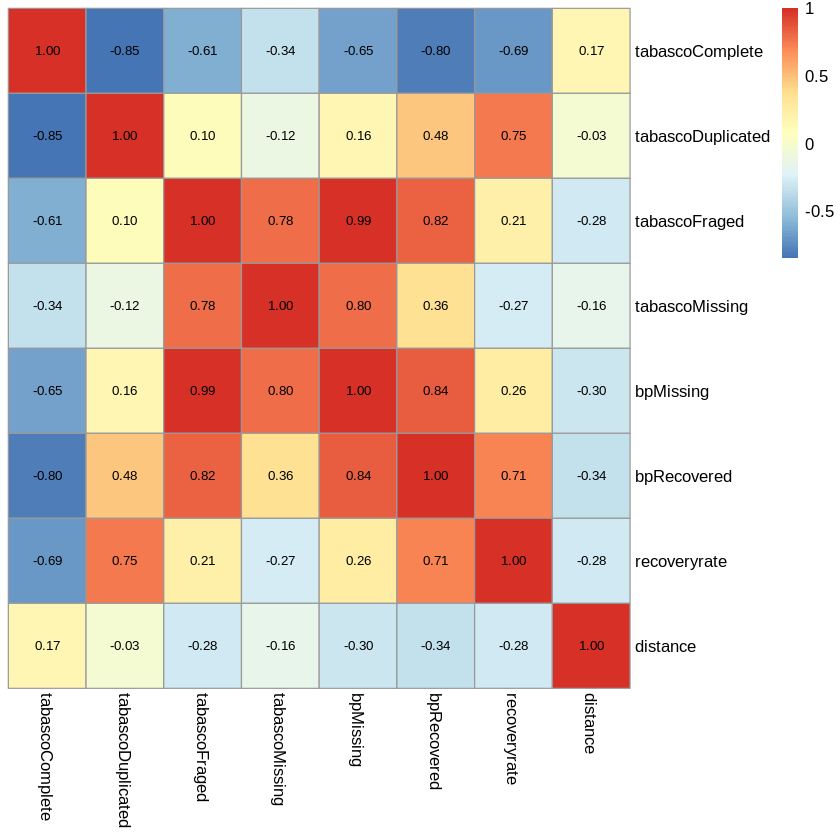

In [292]:
pheatmap::pheatmap(cor(mergedDF[,c(2:5,8,9,12,11)]),cluster_rows = F,cluster_cols = F,display_numbers = T,number_color = "black")

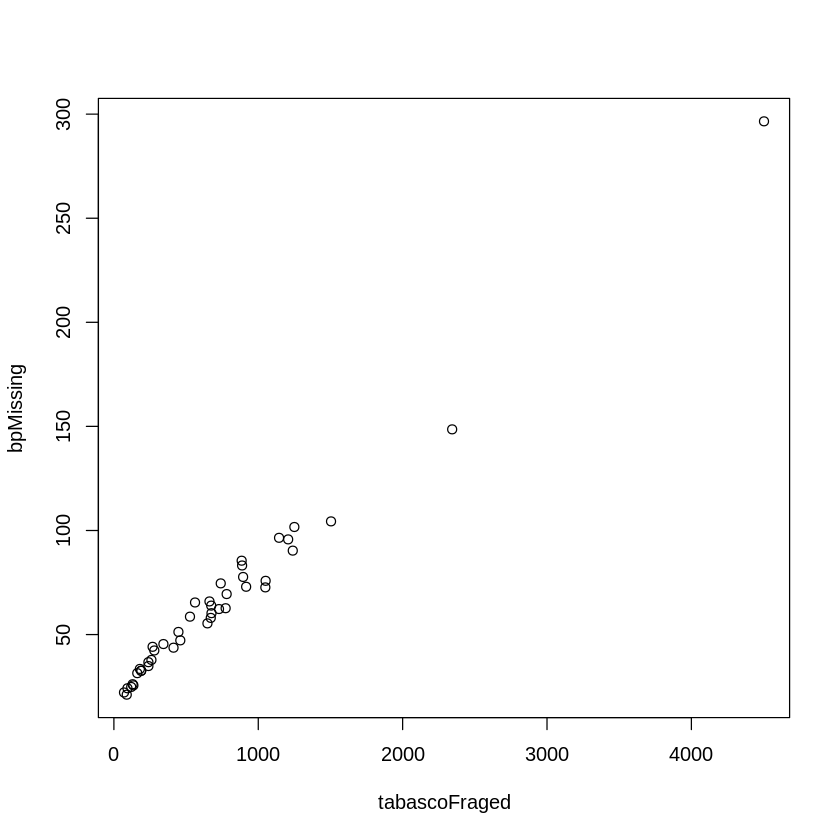

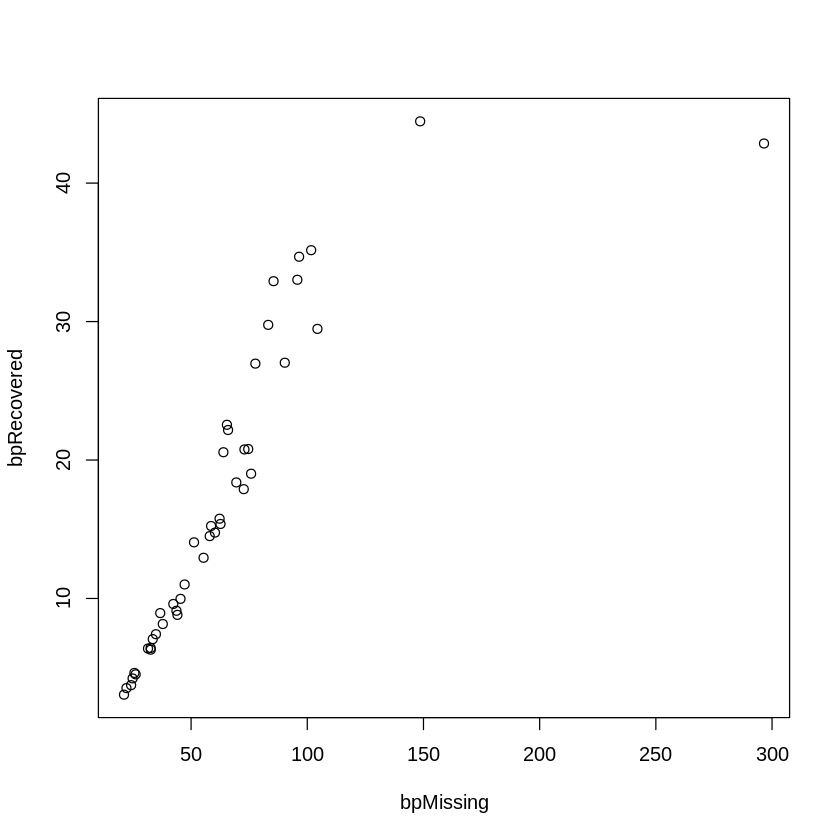

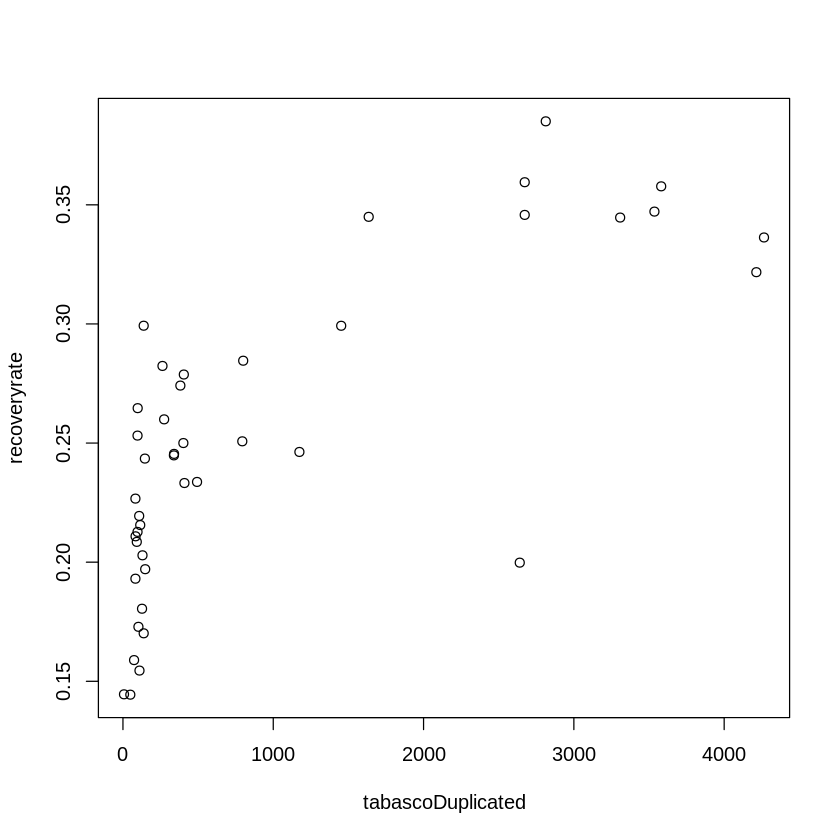

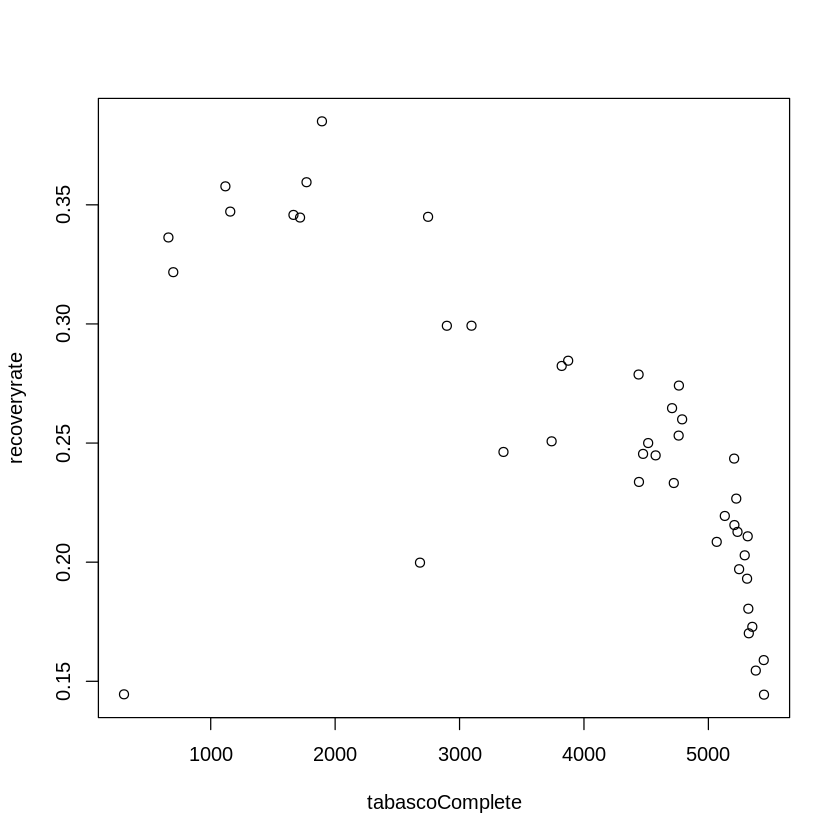

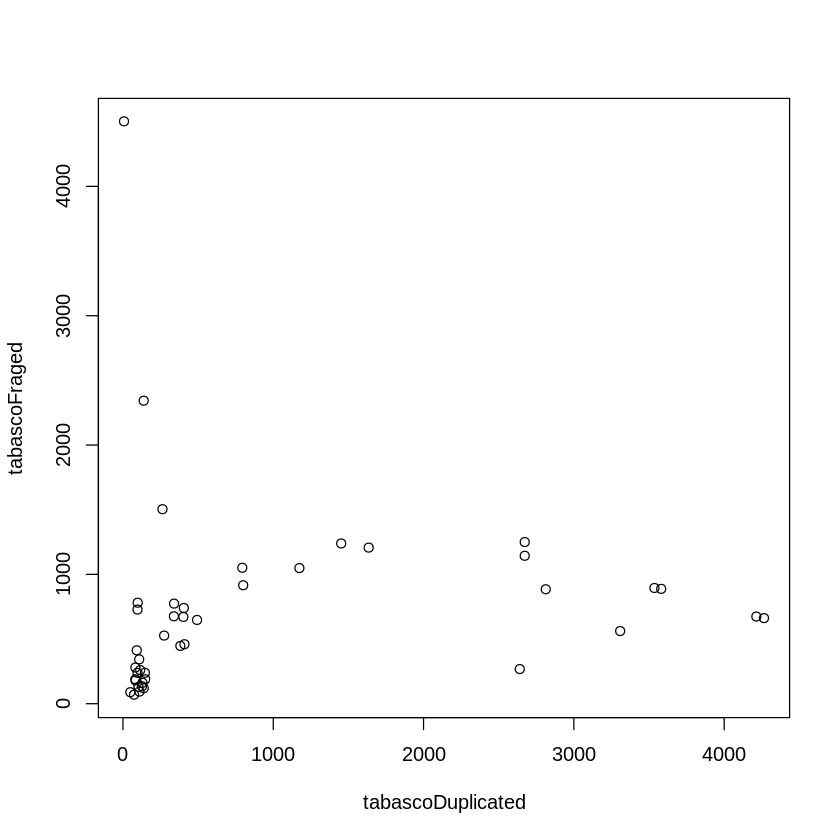

In [305]:
plot(mergedDF[,c(4,8)])
plot(mergedDF[,c(8,9)])
plot(mergedDF[,c(3,12)])
plot(mergedDF[,c(2,12)])
plot(mergedDF[,c(3,4)])

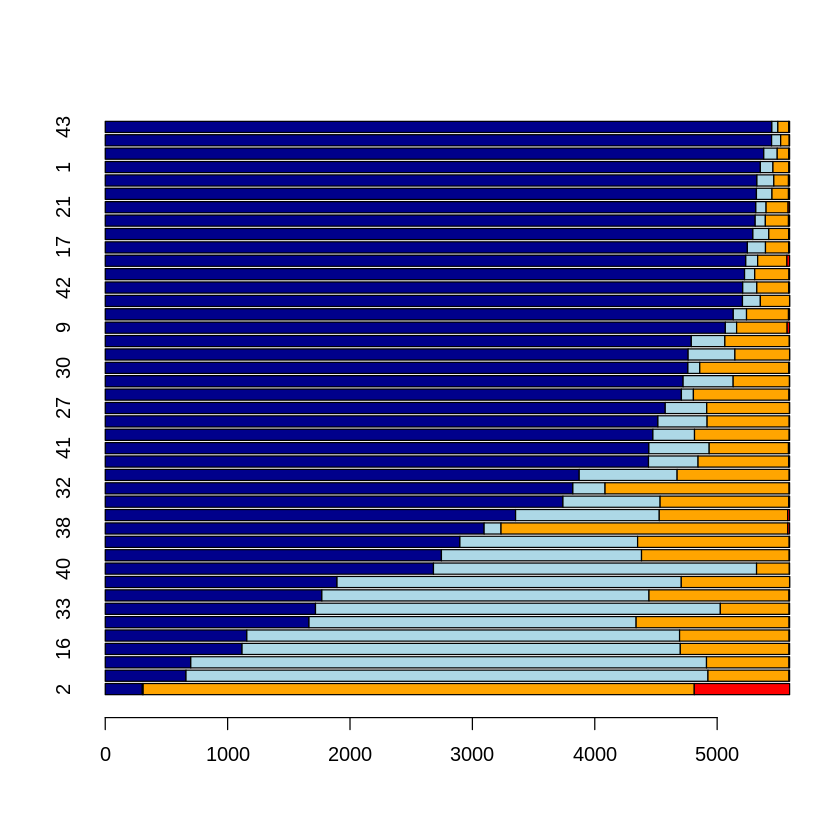

In [304]:
barplot(t(as.matrix(mergedDF[order(mergedDF[,2]),2:5])),horiz = T,col = c("darkblue","lightblue","orange","red"))

In [313]:
mergedDF2 = cbind(TABASCO_score[TABASCO_score[,1]%in%d2ref[d2ref[,2]%in%"ppanic",1],][-c(36),],bp_report2)

mergedDF2 = merge(mergedDF2,d2ref,by.x = 'speciesID',by.y = 'nonreference')
mergedDF2$recoveryrate = mergedDF2[,9]/mergedDF2[,8]

colnames(mergedDF2)[8:9] = c("bpMissing","bpRecovered")

In [315]:
cor(mergedDF2[,-c(1,10)])

,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,bpMissing,bpRecovered,distance,recoveryrate
tabascoComplete,1.0000000,-0.7049118891,-0.63877396,-0.35048977,0.7094662521,-0.7094662521,-0.78918506,-0.7476695,0.5244927,-0.43021549
tabascoDuplicated,-0.7049119,1.0000000000,0.12484676,-0.15114733,-0.0002431393,0.0002431393,0.13184217,0.4326802,-0.2401879,0.72882646
tabascoFraged,-0.6387740,0.1248467589,1.00000000,0.01847112,-0.7765310686,0.7765310686,0.82147106,0.9034243,-0.4632656,0.31043409
tabascoMissing,-0.3504898,-0.1511473259,0.01847112,1.00000000,-0.6443148631,0.6443148631,0.56063106,-0.1060318,-0.2324130,-0.56341113
tabascoTotalCompleteDuplicated,0.7094663,-0.0002431393,-0.77653107,-0.64431486,1.0000000000,-1.0000000000,-0.98163779,-0.6242011,0.5008112,0.11760589
tabascoTotalFragMissing,-0.7094663,0.0002431393,0.77653107,0.64431486,-1.0000000000,1.0000000000,0.98163779,0.6242011,-0.5008112,-0.11760589
bpMissing,-0.7891851,0.1318421748,0.82147106,0.56063106,-0.9816377883,0.9816377883,1.00000000,0.7416561,-0.5412764,0.05884593
bpRecovered,-0.7476695,0.4326801700,0.90342427,-0.10603178,-0.6242011375,0.6242011375,0.74165608,1.0000000,-0.4655652,0.64341270
distance,0.5244927,-0.2401878787,-0.46326560,-0.23241302,0.5008111512,-0.5008111512,-0.54127636,-0.4655652,1.0000000,-0.14181472
recoveryrate,-0.4302155,0.7288264633,0.31043409,-0.56341113,0.1176058898,-0.1176058898,0.05884593,0.6434127,-0.1418147,1.00000000


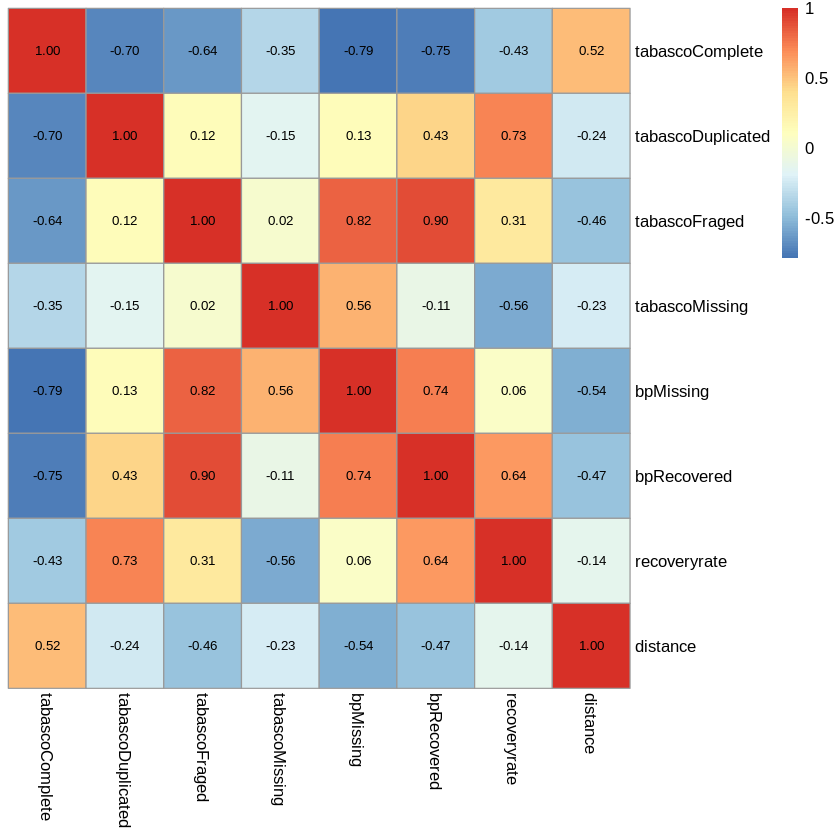

In [314]:
pheatmap::pheatmap(cor(mergedDF2[,c(2:5,8,9,12,11)]),cluster_rows = F,cluster_cols = F,display_numbers = T,number_color = "black")

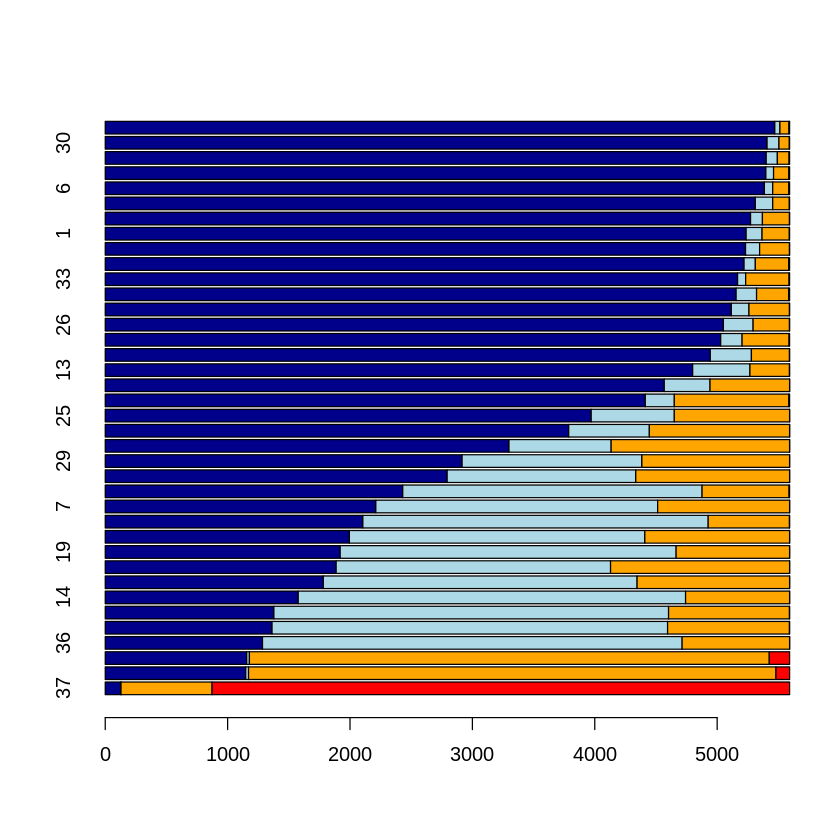

In [316]:
barplot(t(as.matrix(mergedDF2[order(mergedDF2[,2]),2:5])),horiz = T,col = c("darkblue","lightblue","orange","red"))

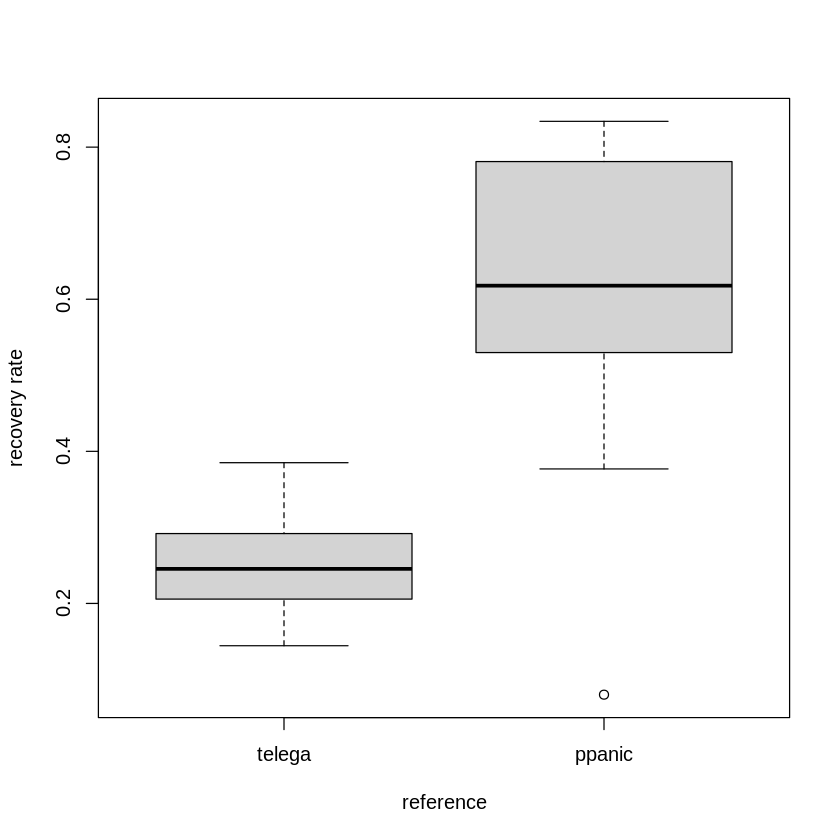

In [323]:
boxplot(mergedDF3[,12]~c(rep("a",43),rep("b",38)), xlab = "reference",ylab = "recovery rate", names = c("telega","ppanic"))

In [548]:
samplelist3 = intersect(gsub(".scaffolded.gff","",list.files("/workdir/sh2246/p_phyloGWAS/output/paspalum_miniProt/")),
                       gsub(".gff","",list.files("/workdir/hackathon_202309/data/miniprotAlignmentVsPaspalum_unfiltered/")))

In [549]:
length(samplelist3)

[1] 405

In [550]:
eval_scaffold = function(j){
    gff_original = readGFF(paste0("/workdir/hackathon_202309/data/miniprotAlignmentVsPaspalum_unfiltered/",j,".gff"))
    gff_scaffolded = readGFF(paste0("/workdir/sh2246/p_phyloGWAS/output/paspalum_miniProt/",j,".scaffolded.gff"))
    if(nrow(gff_scaffolded)>0) {
        gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

        queryStat_original = strsplit2(gff.mrna_original$Target," ")
        queryStat_original = as.data.frame(queryStat_original)
        colnames(queryStat_original) = c("query","start","end")
        queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

        qcov_original=c()
        for (i in unique(queryStat_original[,1])){
          qcov_original=c(qcov_original,queryStat_original[queryStat_original[,1]==i,4]/queryFa_length[i])
        }
        queryStat_original$coverage = qcov_original

        gff.mrna_scaffolded = gff_scaffolded[gff_scaffolded[,3]=="mRNA",]

        queryStat_scaffolded = strsplit2(gff.mrna_scaffolded$Target," ")
        queryStat_scaffolded = as.data.frame(queryStat_scaffolded)
        colnames(queryStat_scaffolded) = c("query","start","end")
        queryStat_scaffolded$range = as.numeric(queryStat_scaffolded[,3])-as.numeric(queryStat_scaffolded[,2])+1

        qcov_scaffolded=c()
        for (i in unique(queryStat_scaffolded[,1])){
          qcov_scaffolded=c(qcov_scaffolded,queryStat_scaffolded[queryStat_scaffolded[,1]==i,4]/queryFa_length[i])
        }
        queryStat_scaffolded$coverage = qcov_scaffolded

        queryStat_original[,2] = as.numeric(queryStat_original[,2])
        queryStat_original[,3] = as.numeric(queryStat_original[,3])
        queryStat_scaffolded[,2] = as.numeric(queryStat_scaffolded[,2])
        queryStat_scaffolded[,3] = as.numeric(queryStat_scaffolded[,3])


        queryLengthCov_original <- queryStat_original %>% group_by(query) %>% 
        summarise(TotalRange = calculate_range(start, end))
        queryLengthCov_scaffolded <- queryStat_scaffolded %>% group_by(query) %>% 
        summarise(TotalRange = calculate_range(start, end))
        queryLengthCov_original = as.data.frame(queryLengthCov_original)
        queryLengthCov_scaffolded = as.data.frame(queryLengthCov_scaffolded)
        rownames(queryLengthCov_original)=queryLengthCov_original[,1]
        rownames(queryLengthCov_scaffolded)=queryLengthCov_scaffolded[,1]

        common_anchor2 = intersect(rownames(queryLengthCov_original),rownames(queryLengthCov_scaffolded))
        out = c(j,mean(queryFa_length[common_anchor2]-queryLengthCov_original[common_anchor2,2]),
                mean(queryLengthCov_scaffolded[common_anchor2,2]-queryLengthCov_original[common_anchor2,2]))
        return(out)
    }
    else return(NULL)
}


In [551]:
library(parallel)

In [554]:
bp_report3 = simplify2array(mclapply(samplelist3,eval_scaffold,mc.cores = 30))

In [555]:
bp_report4 = as.data.frame(t(simplify2array(bp_report3[!sapply(bp_report3,is.null)])))

In [556]:
colnames(bp_report4) = c("speciesID","missedBP","recoveredBP")

In [557]:
bp_report4[,2] = as.numeric(bp_report4[,2])
bp_report4[,3] = as.numeric(bp_report4[,3])

head(TABASCO_score)
head(bp_report4)

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
1,MCRTL053,5440,94,54,4,5534,58
2,MCRTL007,5445,74,70,3,5519,73
3,MCRTL033,5471,42,74,5,5513,79
4,MCRTL063,5381,130,76,5,5511,81
5,MCRTL027,5355,154,77,6,5509,83
6,MCRTL003,5428,78,80,6,5506,86


,speciesID,missedBP,recoveredBP
,<chr>,<dbl>,<dbl>
1,A1010002,127.86750,53.82196
2,A1014002,42.06616,15.54063
3,A1015002,65.72885,24.40818
4,A1020001,97.27034,32.75871
5,A1021002,92.92248,31.67176
6,A1025002,80.27292,29.56089


In [558]:
mergedDF3 = merge(TABASCO_score,bp_report4,by = "speciesID")

mergedDF3 = merge(mergedDF3,d2ref,by.x = 'speciesID',by.y = 'nonreference')

In [559]:
mergedDF3$recoveryrate = mergedDF3[,9]/mergedDF3[,8]

# colnames(mergedDF3)[8:9] = c("bpMissing","bpRecovered")

In [560]:
mergedDF3 = mergedDF3[mergedDF3[,12]>0,]

In [561]:
head(mergedDF3)

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,missedBP,recoveredBP,reference_closest,distance,recoveryrate
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,AN20T004,5128,188,269,7,5316,276,34.61104,11.50883,smicro,1.288258,0.3325190
2,AN20T007,3853,589,1149,1,4442,1150,84.93397,31.40734,hconto,0.140806,0.3697854
3,AN20T009,2646,1841,1105,0,4487,1105,83.61481,36.80554,hconto,0.000000,0.4401797
4,AN20T010,4254,445,890,3,4699,893,70.47962,23.68118,ttrian,2.337557,0.3360004
5,AN20T012,4563,397,629,3,4960,632,66.80269,25.00538,ttrian,1.852108,0.3743169
6,AN20T014,2889,1272,1430,1,4161,1431,92.13951,35.88481,blagur,1.877049,0.3894618


In [562]:
ploidy = read.delim("/workdir/sh2246/p_panAndOGASR/data/panand_assembly_sizes.txt",row.names = 1)

In [563]:
head(ploidy)

,haploid,species,speciesLabel,ploidy,flow,rawAssemblySize,haploidAssemblySize,rawRepeatSize,haploidRepeatSize
,<lgl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
achine,TRUE,Andropogon chinensis,Andropogon chinensis*,Tetraploid,1449.0,1335640055,1335640055,789601102,789601102
agerar,FALSE,Andropogon gerardi,Andropogon gerardi,Hexaploid,3063.5,4598175493,2299087746,3217316866,1608658433
atenui,FALSE,Andropogon tenuifolius,Andropogon tenuifolius,Tetraploid,1849.0,1946409527,973204764,1102056601,551028300
avirgi,TRUE,Andropogon virginicus,Andropogon virginicus*,Diploid,1068.0,905672792,905672792,580187431,580187431
blagur,FALSE,Bothriochloa laguroides,Bothriochloa laguroides,Hexaploid,4265.0,3514573948,1757286974,2085892766,1042946383
cserru,FALSE,Chrysopogon serrulatus,Chrysopogon serrulatus,Diploid,679.0,1325370691,662685346,632332628,316166314


In [581]:
ploidy_col = c("gold","purple","red","lightblue")[factor(ploidy[sort(unique(mergedDF3[,10])),4],
                                                         levels = c("Diploid","Tetraploid","Hexaploid","Paleotetraploid"))]

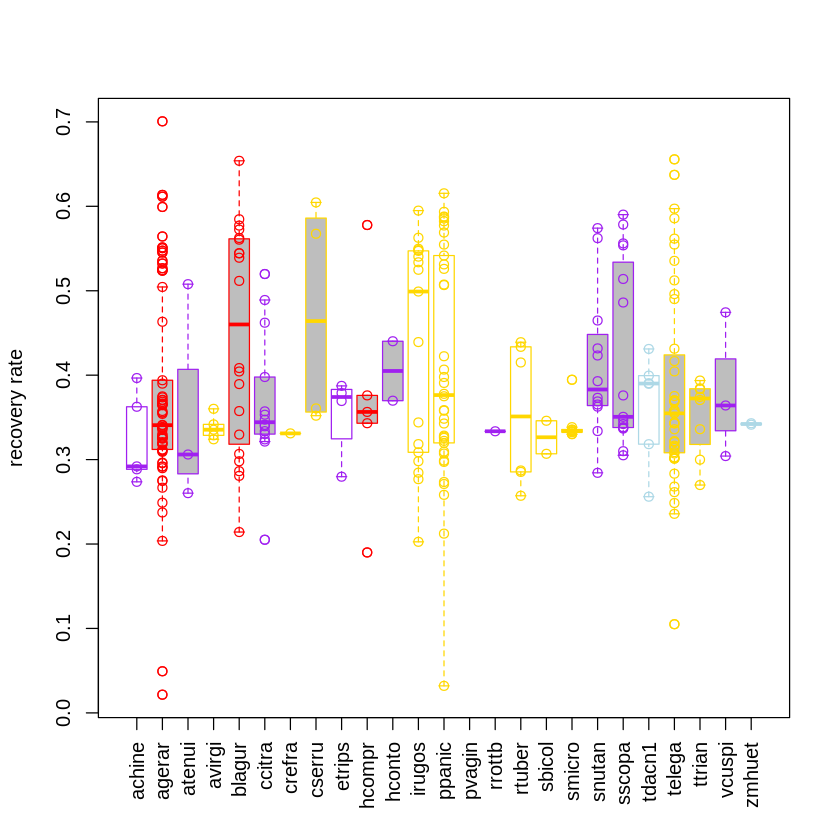

In [582]:
boxplot(mergedDF3[,12]~mergedDF3[,10],las =3, xlab = "", ylab = "recovery rate",
        border = ploidy_col,
        col = ifelse(ploidy[sort(unique(mergedDF3[,10])),1],"white","grey"))
points(x = as.numeric(as.factor(mergedDF3[,10])),y = mergedDF3[,12],type = 'p',
       col = c("gold","purple","red","lightblue")[factor(ploidy[mergedDF3[,10],4],
                                                         levels = c("Diploid","Tetraploid","Hexaploid","Paleotetraploid"))])

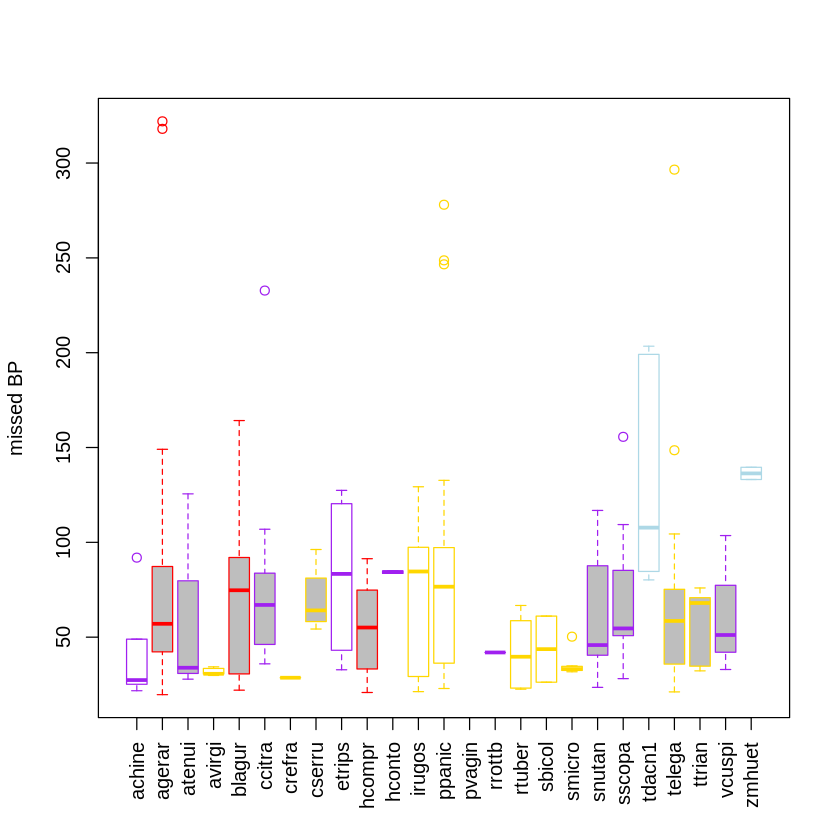

In [583]:
boxplot(mergedDF3[,8]~mergedDF3[,10],las =3, xlab = "", ylab = "missed BP",
        border = c("gold","purple","red","lightblue")[factor(ploidy[sort(unique(mergedDF3[,10])),4],
                                                          levels = c("Diploid","Tetraploid","Hexaploid","Paleotetraploid"))],
        col = ifelse(ploidy[sort(unique(mergedDF3[,10])),1],"white","grey"))

In [566]:
table(mergedDF3[,10])


achine agerar atenui avirgi blagur ccitra crefra cserru etrips hcompr hconto 
     5     66      3      5     20     14      1      4      4      5      2 
irugos ppanic pvagin rrottb rtuber sbicol smicro snutan sscopa tdacn1 telega 
    17     38      3      1      6      2      9     12     15      6     43 
ttrian vcuspi zmhuet 
     8      3      2 

In [567]:
mergedDF3[which(mergedDF3[,12]<0),]

speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,missedBP,recoveredBP,reference_closest,distance,recoveryrate
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>


In [644]:
mergedDF3[order(mergedDF3[,3],decreasing = T),]

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing,missedBP,recoveredBP,reference_closest,distance,recoveryrate
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
172,AN21TSTL0188,660,4265,662,5,4925,667,65.92764,36.57213,telega,3.575688,0.5547314
26,AN20T174,699,4214,674,5,4913,679,63.93636,35.91526,telega,3.575688,0.5617346
217,AN21TSTL0253,1052,3980,558,2,5032,560,62.12831,37.56243,cserru,1.507432,0.6045944
99,AN21TNTL0343,875,3697,1014,6,4572,1020,84.97883,46.84994,agerar,2.542402,0.5513131
215,AN21TSTL0250,1210,3681,699,2,4891,701,71.99712,40.03506,sscopa,0.814653,0.5560647
263,MCRTL030,945,3614,1029,4,4559,1033,84.24868,46.37512,agerar,2.434930,0.5504552
122,AN21TS21,1118,3581,888,5,4699,893,83.18058,44.53718,telega,5.241643,0.5354276
67,AN21TNTL0115,1157,3536,895,4,4693,899,77.62357,45.47557,telega,1.171988,0.5858474
170,AN21TSTL0186,1129,3522,939,2,4651,941,83.76825,49.43743,sscopa,1.127368,0.5901690


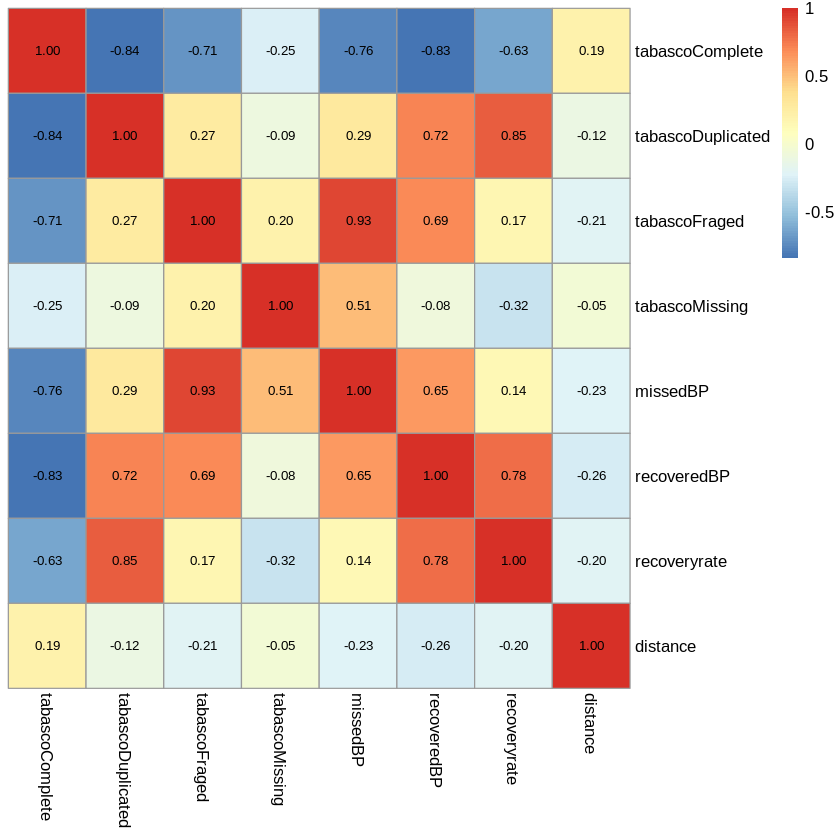

In [568]:
pheatmap::pheatmap(cor(mergedDF3[,c(2:5,8,9,12,11)]),cluster_rows = F,cluster_cols = F,display_numbers = T,number_color = "black")

In [569]:
eval_scaffold_complete = function(j){
    gff_original = readGFF(paste0("/workdir/hackathon_202309/data/miniprotAlignmentVsPaspalum_unfiltered/",j,".gff"))
    gff_scaffolded = readGFF(paste0("/workdir/sh2246/p_phyloGWAS/output/paspalum_miniProt/",j,".scaffolded.gff"))
    if(nrow(gff_scaffolded)>0) {
        gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

        queryStat_original = strsplit2(gff.mrna_original$Target," ")
        queryStat_original = as.data.frame(queryStat_original)
        colnames(queryStat_original) = c("query","start","end")
        queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

        qcov_original=c()
        for (i in unique(queryStat_original[,1])){
          qcov_original=c(qcov_original,queryStat_original[queryStat_original[,1]==i,4]/queryFa_length[i])
        }
        queryStat_original$coverage = qcov_original

        gff.mrna_scaffolded = gff_scaffolded[gff_scaffolded[,3]=="mRNA",]

        queryStat_scaffolded = strsplit2(gff.mrna_scaffolded$Target," ")
        queryStat_scaffolded = as.data.frame(queryStat_scaffolded)
        colnames(queryStat_scaffolded) = c("query","start","end")
        queryStat_scaffolded$range = as.numeric(queryStat_scaffolded[,3])-as.numeric(queryStat_scaffolded[,2])+1

        qcov_scaffolded=c()
        for (i in unique(queryStat_scaffolded[,1])){
          qcov_scaffolded=c(qcov_scaffolded,queryStat_scaffolded[queryStat_scaffolded[,1]==i,4]/queryFa_length[i])
        }
        queryStat_scaffolded$coverage = qcov_scaffolded

        queryStat_original[,2] = as.numeric(queryStat_original[,2])
        queryStat_original[,3] = as.numeric(queryStat_original[,3])
        queryStat_scaffolded[,2] = as.numeric(queryStat_scaffolded[,2])
        queryStat_scaffolded[,3] = as.numeric(queryStat_scaffolded[,3])


        queryStat_original_primary = queryStat_original[gff.mrna_original$Rank == 1,]
        queryStat_scaffolded_primary = queryStat_scaffolded[gff.mrna_scaffolded$Rank == 1,]

#         rownames(queryStat_original_primary) = queryStat_original_primary[,1]
#         rownames(queryStat_scaffolded_primary) = queryStat_scaffolded_primary[,1]

        common_anchor = intersect(rownames(queryStat_original_primary),rownames(queryStat_scaffolded_primary))
        out = c(j,sum(queryStat_original_primary$coverage>.8),sum(queryStat_scaffolded_primary$coverage>.8))
        return(out)
    }
    else return(NULL)
}


In [570]:
complete_report = simplify2array(mclapply(samplelist3,eval_scaffold_complete,mc.cores = 30))

In [571]:
complete_report[[3]]

[1] "A1015002" "29471"    "32649"

In [572]:
complete_report2 = as.data.frame(t(simplify2array(complete_report[!sapply(complete_report,is.null)])))

In [573]:
colnames(complete_report2) = c("speciesID","contig","scaffold")
complete_report2[,2] = as.numeric(complete_report2[,2])
complete_report2[,3] = as.numeric(complete_report2[,3])


In [574]:
mergedDF4 = merge(TABASCO_score,complete_report2,by = "speciesID")

mergedDF4 = merge(mergedDF4,d2ref,by.x = 'speciesID',by.y = 'nonreference')

In [575]:
mergedDF4$recoveryGenes = mergedDF4[,9]-mergedDF4[,8]


In [576]:
mergedDF4 = mergedDF4[mergedDF4[,12]>0,]

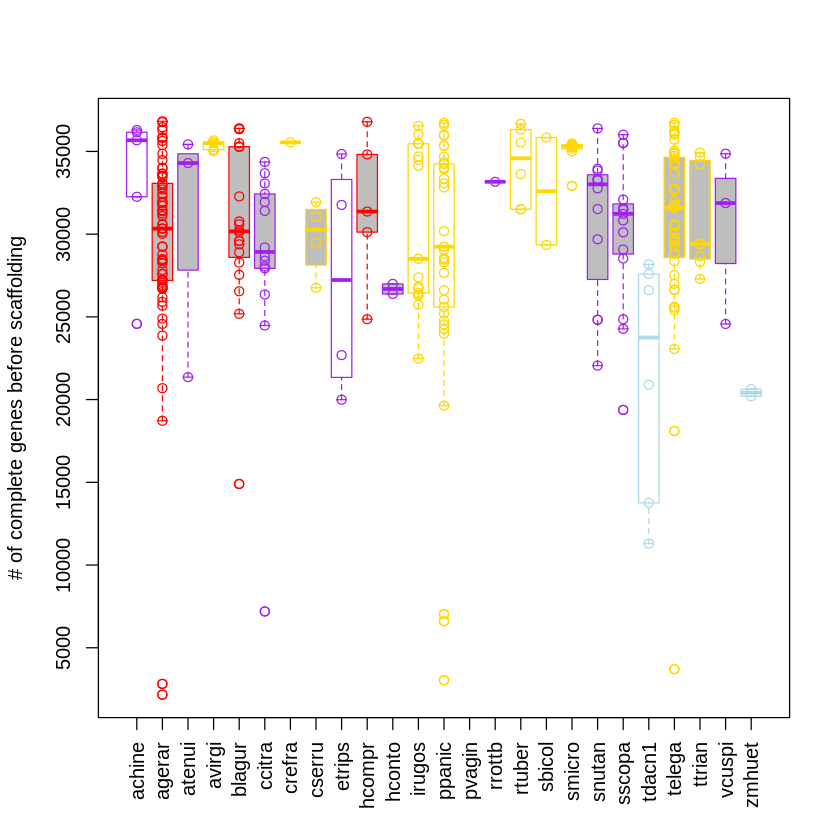

In [578]:
boxplot(mergedDF4[,8]~mergedDF4[,10],las =3, xlab = "", ylab = "# of complete genes before scaffolding",
        border = ploidy_col,
        col = ifelse(ploidy[sort(unique(mergedDF3[,10])),1],"white","grey"))

points(x = as.numeric(as.factor(mergedDF4[,10])),y = mergedDF4[,8],type = 'p',
       col = c("gold","purple","red","lightblue")[factor(ploidy[mergedDF4[,10],4],
                                                         levels = c("Diploid","Tetraploid","Hexaploid","Paleotetraploid"))])

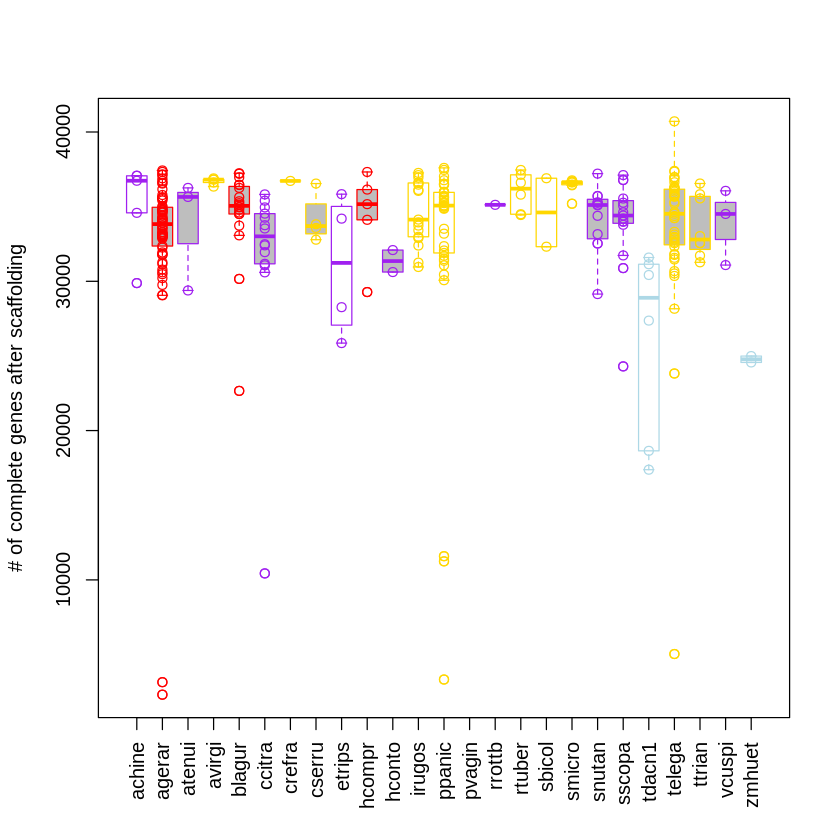

In [579]:
boxplot(mergedDF4[,9]~mergedDF4[,10],las =3, xlab = "", ylab = "# of complete genes after scaffolding",
        border = ploidy_col,
        col = ifelse(ploidy[sort(unique(mergedDF3[,10])),1],"white","grey"))
points(x = as.numeric(as.factor(mergedDF4[,10])),y = mergedDF4[,9],type = 'p',
       col = c("gold","purple","red","lightblue")[factor(ploidy[mergedDF4[,10],4],
                                                         levels = c("Diploid","Tetraploid","Hexaploid","Paleotetraploid"))])

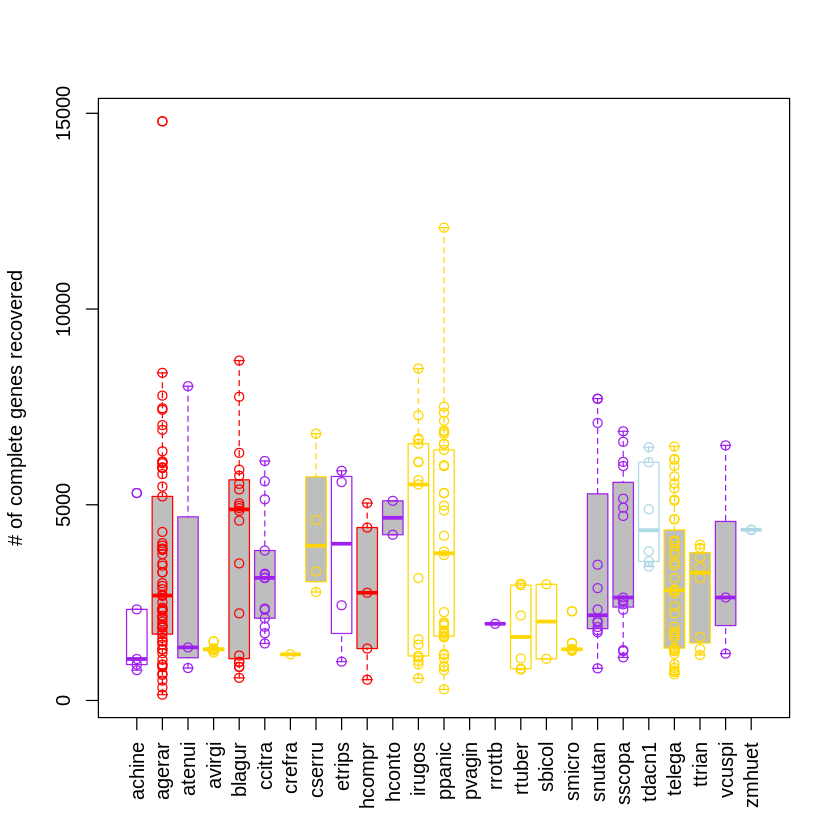

In [580]:
boxplot(mergedDF4[,12]~mergedDF4[,10],las =3, xlab = "", ylab = "# of complete genes recovered",
        border = ploidy_col,
        col = ifelse(ploidy[sort(unique(mergedDF3[,10])),1],"white","grey"))
points(x = as.numeric(as.factor(mergedDF4[,10])),y = mergedDF4[,12],type = 'p',
       col = c("gold","purple","red","lightblue")[factor(ploidy[mergedDF4[,10],4],
                                                         levels = c("Diploid","Tetraploid","Hexaploid","Paleotetraploid"))])

In [450]:
mergedDF4[,10]
ploidy[mergedDF4[,10],4]

[1] "smicro" "hconto" "hconto" "ttrian" "ttrian" "blagur" "irugos" "telega"
  [9] "hcompr" "ttrian" "sscopa" "sscopa" "ppanic" "ppanic" "ppanic" "snutan"
 [17] "telega" "agerar" "agerar" "sscopa" "ppanic" "agerar" "sscopa" "sscopa"
 [25] "sscopa" "telega" "ccitra" "cserru" "blagur" "ccitra" "agerar" "agerar"
 [33] "etrips" "hcompr" "ttrian" "agerar" "ppanic" "irugos" "irugos" "irugos"
 [41] "ppanic" "agerar" "agerar" "blagur" "vcuspi" "snutan" "snutan" "ccitra"
 [49] "rtuber" "ppanic" "telega" "telega" "agerar" "irugos" "irugos" "ccitra"
 [57] "ccitra" "telega" "telega" "telega" "telega" "sscopa" "agerar" "telega"
 [65] "telega" "agerar" "ppanic" "ppanic" "tdacn1" "telega" "agerar" "irugos"
 [73] "irugos" "agerar" "ppanic" "telega" "ppanic" "ppanic" "irugos" "irugos"
 [81] "blagur" "achine" "irugos" "agerar" "irugos" "blagur" "agerar" "agerar"
 [89] "agerar" "agerar" "agerar" "agerar" "agerar" "agerar" "ppanic" "agerar"
 [97] "agerar" "agerar" "rrottb" "vcuspi" "ppanic" "telega" "achine" "avirgi"
[105] "telega" "achine" "agerar" "agerar" "ppanic" "ccitra" "ppanic" "agerar"
[113] "sscopa" "ttrian" "snutan" "telega" "telega" "agerar" "avirgi" "ppanic"
[121] "snutan" "ccitra" "snutan" "telega" "telega" "blagur" "blagur" "avirgi"
[129] "snutan" "agerar" "agerar" "snutan" "rtuber" "telega" "tdacn1" "zmhuet"
[137] "agerar" "irugos" "agerar" "sscopa" "sscopa" "smicro" "sscopa" "blagur"
[145] "etrips" "telega" "telega" "telega" "ppanic" "ppanic" "ppanic" "smicro"
[153] "smicro" "smicro" "smicro" "smicro" "agerar" "cserru" "telega" "telega"
[161] "avirgi" "agerar" "sscopa" "ppanic" "telega" "ccitra" "ccitra" "blagur"
[169] "ccitra" "blagur" "etrips" "telega" "agerar" "telega" "ppanic" "ppanic"
[177] "ppanic" "ppanic" "tdacn1" "snutan" "ppanic" "ppanic" "ppanic" "ppanic"
[185] "rtuber" "ppanic" "blagur" "blagur" "agerar" "sbicol" "telega" "cserru"
[193] "vcuspi" "telega" "hcompr" "blagur" "telega" "hcompr" "blagur" "crefra"
[201] "blagur" "telega" "agerar" "ccitra" "telega" "avirgi" "agerar" "sscopa"
[209] "telega" "cserru" "tdacn1" "ppanic" "ppanic" "ttrian" "ttrian" "ppanic"
[217] "ppanic" "ppanic" "irugos" "irugos" "agerar" "agerar" "ppanic" "ccitra"
[225] "snutan" "blagur" "blagur" "blagur" "blagur" "ppanic" "rtuber" "tdacn1"
[233] "blagur" "telega" "ttrian" "telega" "telega" "tdacn1" "sbicol" "telega"
[241] "agerar" "rtuber" "telega" "rtuber" "snutan" "telega" "zmhuet" "irugos"
[249] "telega" "snutan" "agerar" "agerar" "agerar" "achine" "telega" "ppanic"
[257] "agerar" "agerar" "agerar" "agerar" "irugos" "agerar" "telega" "agerar"
[265] "achine" "sscopa" "ccitra" "agerar" "etrips" "agerar" "agerar" "hcompr"
[273] "agerar" "agerar" "agerar" "ccitra" "agerar" "smicro" "agerar" "agerar"
[281] "agerar" "agerar" "agerar" "agerar" "agerar" "sscopa" "smicro"

[1] "Diploid"         "Tetraploid"      "Tetraploid"      "Diploid"        
  [5] "Diploid"         "Hexaploid"       "Diploid"         "Diploid"        
  [9] "Hexaploid"       "Diploid"         "Tetraploid"      "Tetraploid"     
 [13] "Diploid"         "Diploid"         "Diploid"         "Tetraploid"     
 [17] "Diploid"         "Hexaploid"       "Hexaploid"       "Tetraploid"     
 [21] "Diploid"         "Hexaploid"       "Tetraploid"      "Tetraploid"     
 [25] "Tetraploid"      "Diploid"         "Tetraploid"      "Diploid"        
 [29] "Hexaploid"       "Tetraploid"      "Hexaploid"       "Hexaploid"      
 [33] "Tetraploid"      "Hexaploid"       "Diploid"         "Hexaploid"      
 [37] "Diploid"         "Diploid"         "Diploid"         "Diploid"        
 [41] "Diploid"         "Hexaploid"       "Hexaploid"       "Hexaploid"      
 [45] "Tetraploid"      "Tetraploid"      "Tetraploid"      "Tetraploid"     
 [49] "Diploid"         "Diploid"         "Diploid"         "Diploid"        
 [53] "Hexaploid"       "Diploid"         "Diploid"         "Tetraploid"     
 [57] "Tetraploid"      "Diploid"         "Diploid"         "Diploid"        
 [61] "Diploid"         "Tetraploid"      "Hexaploid"       "Diploid"        
 [65] "Diploid"         "Hexaploid"       "Diploid"         "Diploid"        
 [69] "Paleotetraploid" "Diploid"         "Hexaploid"       "Diploid"        
 [73] "Diploid"         "Hexaploid"       "Diploid"         "Diploid"        
 [77] "Diploid"         "Diploid"         "Diploid"         "Diploid"        
 [81] "Hexaploid"       "Tetraploid"      "Diploid"         "Hexaploid"      
 [85] "Diploid"         "Hexaploid"       "Hexaploid"       "Hexaploid"      
 [89] "Hexaploid"       "Hexaploid"       "Hexaploid"       "Hexaploid"      
 [93] "Hexaploid"       "Hexaploid"       "Diploid"         "Hexaploid"      
 [97] "Hexaploid"       "Hexaploid"       "Tetraploid"      "Tetraploid"     
[101] "Diploid"         "Diploid"         "Tetraploid"      "Diploid"        
[105] "Diploid"         "Tetraploid"      "Hexaploid"       "Hexaploid"      
[109] "Diploid"         "Tetraploid"      "Diploid"         "Hexaploid"      
[113] "Tetraploid"      "Diploid"         "Tetraploid"      "Diploid"        
[117] "Diploid"         "Hexaploid"       "Diploid"         "Diploid"        
[121] "Tetraploid"      "Tetraploid"      "Tetraploid"      "Diploid"        
[125] "Diploid"         "Hexaploid"       "Hexaploid"       "Diploid"        
[129] "Tetraploid"      "Hexaploid"       "Hexaploid"       "Tetraploid"     
[133] "Diploid"         "Diploid"         "Paleotetraploid" "Paleotetraploid"
[137] "Hexaploid"       "Diploid"         "Hexaploid"       "Tetraploid"     
[141] "Tetraploid"      "Diploid"         "Tetraploid"      "Hexaploid"      
[145] "Tetraploid"      "Diploid"         "Diploid"         "Diploid"        
[149] "Diploid"         "Diploid"         "Diploid"         "Diploid"        
[153] "Diploid"         "Diploid"         "Diploid"         "Diploid"        
[157] "Hexaploid"       "Diploid"         "Diploid"         "Diploid"        
[161] "Diploid"         "Hexaploid"       "Tetraploid"      "Diploid"        
[165] "Diploid"         "Tetraploid"      "Tetraploid"      "Hexaploid"      
[169] "Tetraploid"      "Hexaploid"       "Tetraploid"      "Diploid"        
[173] "Hexaploid"       "Diploid"         "Diploid"         "Diploid"        
[177] "Diploid"         "Diploid"         "Paleotetraploid" "Tetraploid"     
[181] "Diploid"         "Diploid"         "Diploid"         "Diploid"        
[185] "Diploid"         "Diploid"         "Hexaploid"       "Hexaploid"      
[189] "Hexaploid"       "Diploid"         "Diploid"         "Diploid"        
[193] "Tetraploid"      "Diploid"         "Hexaploid"       "Hexaploid"      
[197] "Diploid"         "Hexaploid"       "Hexaploid"       "Diploid"        
[201] "Hexaploid"       "Diploid"         "Hexaploid"       "Tetraploid"     
[205] "Diploid"         

# ploidy test

In [30]:
panandPloidy = read.delim("/workdir/sh2246/p_panAndOGASR/data/panand_assembly_sizes.txt")
panandPloidy[grep("tdac",panandPloidy[,1]),1] = c("tdacn","tdacs")

In [31]:
panandPloidy[panandPloidy[,2]==T&panandPloidy[,5]=="Diploid",1]
panandPloidy[panandPloidy[,2]==F&panandPloidy[,5]=="Diploid",1]
panandPloidy[panandPloidy[,2]==T&panandPloidy[,5]=="Tetraploid",1]
panandPloidy[panandPloidy[,2]==F&panandPloidy[,5]=="Tetraploid",1]
panandPloidy[panandPloidy[,2]==T&panandPloidy[,5]=="Hexaploid",1]
panandPloidy[panandPloidy[,2]==F&panandPloidy[,5]=="Hexaploid",1]

[1] "avirgi" "crefra" "irugos" "ppanic" "rtuber" "smicro" "sbicol"

[1] "cserru" "telega" "ttrian"

[1] "achine" "etrips" "rrottb"

[1] "atenui" "ccitra" "hconto" "sscopa" "snutan" "vcuspi"

[1] "udigit"

[1] "agerar" "blagur" "hcompr"

In [32]:
agp_ploidy = read.table("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/ploidy/Ac-Pasquet1232-DRAFT-PanAnd-1.0/ragtag.scaffold.agp",skip = 2)

In [49]:
head(agp_ploidy)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ctg_1_RagTag,1,710,1,W,ctg_1:15282-15992,1,710,+
2,ctg_1_RagTag,711,810,2,U,100,scaffold,yes,align_genus
3,ctg_1_RagTag,811,1520,3,W,ctg_1:16213-16923,1,710,+
4,ctg_1_RagTag,1521,1620,4,U,100,scaffold,yes,align_genus
5,ctg_1_RagTag,1621,2330,5,W,ctg_1:16794-17504,1,710,+
6,ctg_1_RagTag,2331,2430,6,U,100,scaffold,yes,align_genus


In [34]:
sum(agp_ploidy[,5]=="W"&gsub("_RagTag","",agp_ploidy[,1])==strsplit2(agp_ploidy[,6],":")[,1])

[1] 2070449

In [35]:
contigPos = strsplit2(agp_ploidy[agp_ploidy[,5]=="W",6],":")

In [36]:
contigPos = cbind(contigPos[,1],strsplit2(contigPos[,2],"-"))

In [37]:
contigPos = cbind(contigPos,grepl("RagTag",agp_ploidy[agp_ploidy[,5]=="W",1]))

In [38]:
a = contigPos[contigPos[,1]=="ctg_1",]

In [39]:
gff_Ac = readGFF("/workdir/sh2246/p_phyloGWAS/output/miniProtFilter_outGFF/Ac-Pasquet1232-DRAFT-PanAnd-1.0.gff")

In [42]:
gff_Ac_ctg1 = gff_Ac[gff_Ac[,1]=="ctg_1"&gff_Ac[,3]=="mRNA",]

In [43]:
head(gff_Ac_ctg1)

DataFrame with 6 rows and 18 columns
     seqid   source     type     start       end     score      strand
  <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1    ctg_1 miniprot     mRNA   8558215   8558862       430           +
2    ctg_1 miniprot     mRNA  30870165  30872072      2507           -
3    ctg_1 miniprot     mRNA   1247663   1249879      3549           -
4    ctg_1 miniprot     mRNA   1247663   1249879      3549           -
5    ctg_1 miniprot     mRNA  15470753  15471775      1178           -
6    ctg_1 miniprot     mRNA  12546553  12551761      1098           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000656           1      0.4710      0.6082
2        NA    MP001427           1      0.7771      0.8587
3        NA    MP001804           1      0.9282      0.9593
4        NA    MP001806           1      0.9282      0.9593
5        NA    MP002640           1

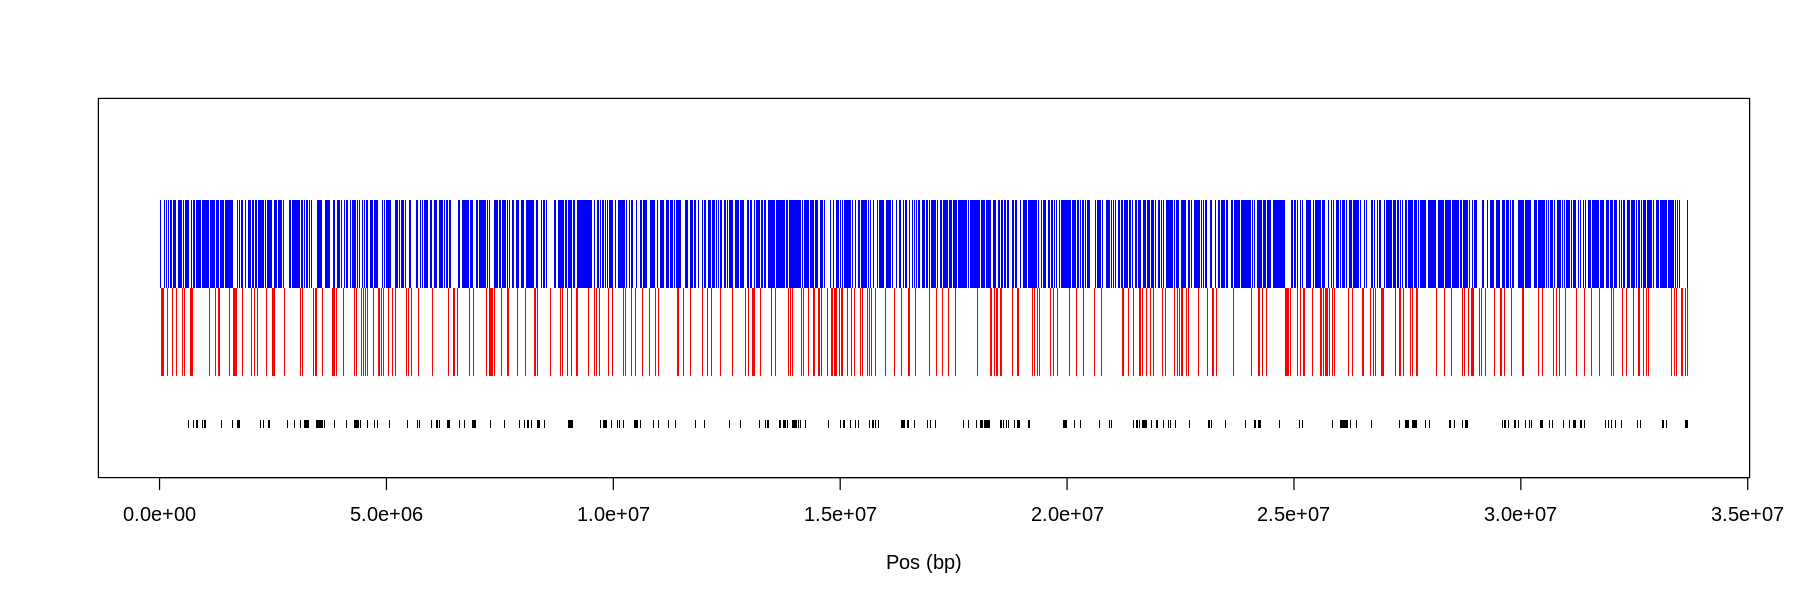

In [44]:
plot(NA,xlim = c(0, max(as.numeric(a[,3]))),ylim =c(0,1),yaxt = "n",xlab = "Pos (bp)",ylab = "")
rect(xleft = as.numeric(a[,2]),xright = as.numeric(a[,3]),
     ybottom = ifelse(a[,4],0.5,0.25),ytop = ifelse(a[,4],0.75,0.5),border = NA,
     col = ifelse(a[,4],"blue","red"))
rect(xleft = gff_Ac_ctg1[,4],xright = gff_Ac_ctg1[,5],
     ybottom = 0.1,ytop = .125,border = NA,
     col = "black")


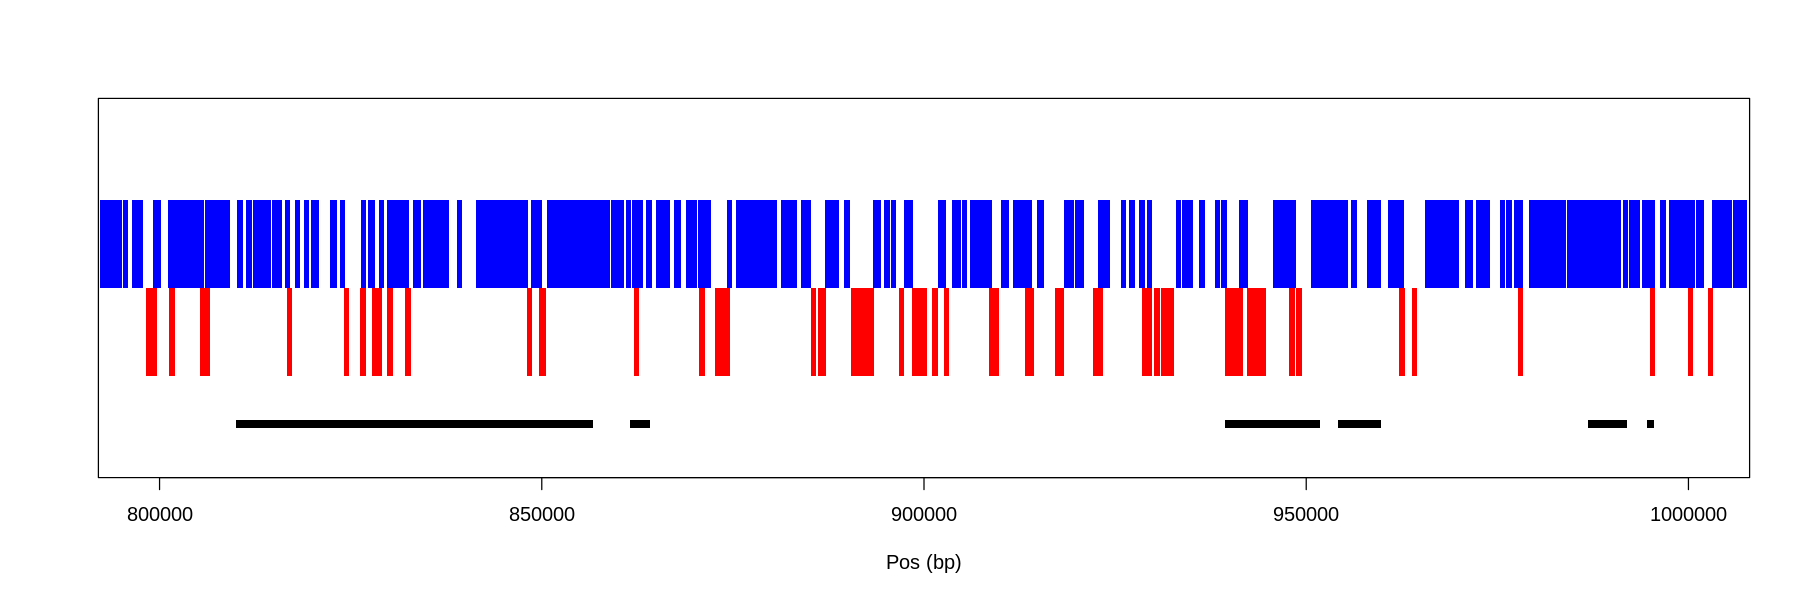

In [45]:
plot(NA,xlim = c(8e5, 1e6),ylim =c(0,1),yaxt = "n",xlab = "Pos (bp)",ylab = "")
rect(xleft = as.numeric(a[,2]),xright = as.numeric(a[,3]),
     ybottom = ifelse(a[,4],0.5,0.25),ytop = ifelse(a[,4],0.75,0.5),border = NA,
     col = ifelse(a[,4],"blue","red"))
rect(xleft = gff_Ac_ctg1[,4],xright = gff_Ac_ctg1[,5],
     ybottom = 0.1,ytop = .125,border = NA,
     col = "black")


In [257]:
head(gff_Ac_ctg1)

DataFrame with 6 rows and 16 columns
     seqid   source     type     start       end     score      strand
  <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1    ctg_1   PanAnd     gene    165372    170719        NA           +
2    ctg_1   PanAnd     gene    195610    199299        NA           +
3    ctg_1   PanAnd     gene    204932    222955        NA           -
4    ctg_1   PanAnd     gene    333288    337363        NA           +
5    ctg_1   PanAnd     gene    338954    343283        NA           +
6    ctg_1   PanAnd     gene    347230    349663        NA           +
      phase              ID        biotype  logic_name          Parent
  <integer>     <character>    <character> <character> <CharacterList>
1        NA Ac00001aa000001 protein_coding   BIND_gene                
2        NA Ac00001aa000002 protein_coding   BIND_gene                
3        NA Ac00001aa000003 protein_coding   BIND_gene                
4        NA Ac00001aa000004 protein_codi